# Tahap 3: Revisi Analisis Spasial Ekonomi Kreatif Jakarta
### JEF 2026 · Topik 4a · koreksi atas hasil Tahap 2

Catatan kerja ini kita susun untuk memperbaiki hasil Tahap 2 sebelum presentasi final. Semua angka dihitung ulang dari berkas Tahap 1 dan Tahap 2. Setiap kalimat interpretasi dicetak dari hasil run, sehingga slide dan naskah revisi bisa mengutip angka yang benar-benar keluar dari data.

| Persoalan pada Tahap 2 | Koreksi pada Tahap 3 |
|---|---|
| Enam sel Kepulauan Seribu ikut dalam grid 870 sel dan semuanya terbaca LL | Wilayah studi dibatasi pada 42 kecamatan daratan dan dicocokkan dengan daftar resmi |
| Densitas sel tepi dibagi luas heksagon penuh, padahal POI dan penduduk hanya diambil di dalam Jakarta | Densitas dibagi luas daratan yang terpotong batas; sel sliver dikeluarkan dari uji spasial; efek tepi didiagnosis |
| Agregasi kecamatan memakai sentroid heksagon, sehingga penduduk dan luas kecamatan meleset | POI dihitung titik-dalam-poligon, penduduk dijumlahkan dari piksel WorldPop, luas diambil dari poligon kecamatan |
| p = 0,001 dibaca sebagai "tingkat kepercayaan 99,9%" | 9.999 permutasi; p dilaporkan sebagai batas bawah bila menyentuh nilai terkecil |
| LISA dan Gi* tanpa koreksi uji berganda | Koreksi FDR Benjamini–Hochberg dilaporkan berdampingan dengan α mentah |
| Tidak ada kontrol intensitas pemetaan OSM | Snapshot seluruh POI OSM sebagai pembanding: Moran's I rasio (Empirical Bayes), regresi binomial negatif dengan uji Moran's I pada residual, dan indikator kelengkapan data per sel |
| Entropi: kafe dan restoran dihitung sebagai dua kategori; entropi bias pada jumlah titik kecil | Kuliner digabung; entropi dan kekayaan subsektor dirarefaksi ke ukuran sampel baku; pangsa non-kuliner disertai selang kepercayaan Wilson |
| Indeks prioritas: transit dikalikan ke gap (sirkular) dan ikut di IKIK dengan arah berlawanan; rata-rata sel tanpa bobot penduduk | Akses dihitung dengan *two-step floating catchment area* (2SFCA) berbasis piksel penduduk; kebutuhan = penduduk tanpa aset non-kuliner dalam radius d0; transit menjadi kolom kelayakan terpisah; lokasi simpul dipilih dengan *maximal covering location*; stabilitas diuji lintas skenario |
| Penduduk kecamatan menyimpang jauh dari angka resmi | Pembanding penduduk resmi per kecamatan (publikasi *Kota Dalam Angka*) dan kalibrasi dasimetrik WorldPop ke total resmi |
| Snapshot OSM tidak diarsipkan (`FORCE_REFRESH = True`) | Snapshot rujukan disimpan beserta provenance dan dipaketkan untuk repositori |

**Berkas yang dibutuhkan** di `data/processed/` (keluaran Tahap 1 dan 2): `poi_creative.gpkg`, `kecamatan_bersih.gpkg`, `transit.gpkg`, `worldpop_jakarta.tif`.

**Opsional:** `data/raw/penduduk_resmi_kecamatan.csv` (bila belum ada, templat dibuat otomatis di SEL 5) dan `outputs/tables/tabel_prioritas_kecamatan.csv` dari Tahap 2 untuk pengecekan errata. Koneksi Overpass dibutuhkan sekali di SEL 3; run berikutnya membaca snapshot dari cache.

Urutan jalan: **Kernel → Restart → Run All**. Bila Overpass gagal, notebook tetap berjalan; bagian yang membutuhkan snapshot rujukan dilewati dan diberi keterangan.

## SEL 1: Setup, parameter, dan fungsi bantu

Parameter kunci kita kumpulkan di satu tempat supaya uji sensitivitas cukup dilakukan dengan mengubah angka di sini. Font gambar diset 12 pt ke atas agar tetap terbaca ketika gambar diperkecil ke kolom naskah atau slide.

In [1]:
# ============ SEL 1: SETUP, PARAMETER, FUNGSI BANTU ============
import os, sys, json, math, time, warnings, glob, shutil, re
from pathlib import Path
from datetime import datetime, timezone
warnings.filterwarnings("ignore")

# PROJ guard (sama dengan Tahap 1-2): cegah proj.db dari instalasi lain terbaca
_cands = [os.path.join(sys.prefix, "share", "proj"),
          os.path.join(sys.prefix, "Library", "share", "proj")]
try:
    import pyproj
    _cands.append(os.path.join(os.path.dirname(pyproj.__file__), "proj_dir", "share", "proj"))
except Exception:
    pass
for _c in _cands:
    if os.path.exists(os.path.join(_c, "proj.db")):
        os.environ["PROJ_LIB"] = os.environ["PROJ_DATA"] = _c
        try:
            import pyproj
            pyproj.datadir.set_data_dir(_c)
        except Exception:
            pass
        break
os.environ["SHAPE_RESTORE_SHX"] = "YES"

import numpy as np, pandas as pd, geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import rasterio
from rasterio.features import rasterize
from rasterio.transform import xy as rio_xy
from pyproj import Transformer
import h3
import shapely
from shapely.geometry import Polygon, MultiPolygon, mapping
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from scipy.special import gammaln
from scipy.stats import spearmanr
from sklearn.cluster import DBSCAN
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local, Moran_Rate
from esda.getisord import G_Local

try:
    import statsmodels.api as sm
    HAS_SM = True
except ImportError:
    HAS_SM = False
try:
    import osmnx as ox
    HAS_OX = True
except ImportError:
    HAS_OX = False

# ---------- parameter ----------
CRS_GEO, CRS_METRIC = 4326, 32748
H3_MAIN, H3_COARSE = 8, 7
MIN_PORSI_DARAT = 0.20       # sel dengan porsi daratan < 20% tidak ikut uji spasial (titik & penduduknya tetap dihitung)
PERM = 9999                  # permutasi; p terkecil yang mungkin = 1/(PERM+1)
ALPHA = 0.05
SEED = 42
D0_LIST = [1000, 1500, 2500] # radius tangkapan akses & cakupan simpul (meter)
D0_UTAMA = 1500
POP_MIN_SEL = 1000           # sel dianggap berpenghuni bila >= 1.000 jiwa
LENGKAP_RASIO_MIN = 0.25     # rasio fasilitas universal teramati/harapan di bawah ini = cakupan data rendah
LENGKAP_HARAPAN_MIN = 4      # kelengkapan hanya dinilai bila harapan >= 4 fasilitas
RAREF_N_KEC = 20             # ukuran sampel baku rarefaksi tingkat kecamatan
RAREF_N_KLASTER = 40         # ukuran sampel baku rarefaksi tingkat klaster DBSCAN
RAREF_ITER = 1000
TOPK = 9                     # jumlah kecamatan/simpul prioritas (sama dengan naskah)
FORCE_REFETCH = False        # True = unduh ulang snapshot rujukan OSM
DBSCAN_EPS_LIST = [300, 400, 600]
DBSCAN_EPS_UTAMA = 400
DBSCAN_MIN = 10

BASE = Path.cwd()
RAW, PROC = BASE / "data" / "raw", BASE / "data" / "processed"
OUT = BASE / "outputs" / "revisi"
FIG, TAB = OUT / "figures", OUT / "tables"
for _p in (FIG, TAB):
    _p.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 12, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.fontsize": 12, "legend.title_fontsize": 12,
    "figure.dpi": 100, "savefig.dpi": 300,
})
SUMBER_PETA = "Sumber: OpenStreetMap (ODbL), WorldPop (CC-BY 4.0). Olahan penulis."
RNG = np.random.default_rng(SEED)

KEC_RESMI = {
    "Gambir": "Jakarta Pusat", "Sawah Besar": "Jakarta Pusat", "Kemayoran": "Jakarta Pusat",
    "Senen": "Jakarta Pusat", "Cempaka Putih": "Jakarta Pusat", "Menteng": "Jakarta Pusat",
    "Tanah Abang": "Jakarta Pusat", "Johar Baru": "Jakarta Pusat",
    "Penjaringan": "Jakarta Utara", "Pademangan": "Jakarta Utara", "Tanjung Priok": "Jakarta Utara",
    "Koja": "Jakarta Utara", "Kelapa Gading": "Jakarta Utara", "Cilincing": "Jakarta Utara",
    "Cengkareng": "Jakarta Barat", "Grogol Petamburan": "Jakarta Barat", "Taman Sari": "Jakarta Barat",
    "Tambora": "Jakarta Barat", "Kebon Jeruk": "Jakarta Barat", "Kalideres": "Jakarta Barat",
    "Palmerah": "Jakarta Barat", "Kembangan": "Jakarta Barat",
    "Kebayoran Baru": "Jakarta Selatan", "Kebayoran Lama": "Jakarta Selatan", "Pesanggrahan": "Jakarta Selatan",
    "Cilandak": "Jakarta Selatan", "Pasar Minggu": "Jakarta Selatan", "Jagakarsa": "Jakarta Selatan",
    "Mampang Prapatan": "Jakarta Selatan", "Pancoran": "Jakarta Selatan", "Tebet": "Jakarta Selatan",
    "Setiabudi": "Jakarta Selatan",
    "Matraman": "Jakarta Timur", "Pulo Gadung": "Jakarta Timur", "Jatinegara": "Jakarta Timur",
    "Kramat Jati": "Jakarta Timur", "Pasar Rebo": "Jakarta Timur", "Cakung": "Jakarta Timur",
    "Duren Sawit": "Jakarta Timur", "Makasar": "Jakarta Timur", "Ciracas": "Jakarta Timur",
    "Cipayung": "Jakarta Timur",
}
assert len(KEC_RESMI) == 42
NAMA_NORM = lambda s: "".join(ch for ch in str(s).lower() if ch.isalnum())
_resmi = {NAMA_NORM(k): k for k in KEC_RESMI}

# angka yang tertulis di naskah Tahap 2 (pembanding)
NASKAH = {
    "moran_res8": 0.369, "HH_res8": 61, "LL_res8": 186, "LL_res8_nonkul": 335, "hot_gi": 28,
    "moran_res7_all": 0.425, "moran_res7_nonkul": 0.434,
    "entropi_ikik8": 0.330, "entropi_prio9": 0.111, "n_dbscan": 34, "pop_prio9": 2489452,
    "prioritas9": ["Johar Baru", "Matraman", "Duren Sawit", "Cempaka Putih", "Kemayoran",
                   "Pulo Gadung", "Kebon Jeruk", "Koja", "Kembangan"],
    "ikik8": ["Menteng", "Setiabudi", "Tanah Abang", "Gambir", "Kebayoran Baru",
              "Taman Sari", "Palmerah", "Senen"],
    "pop_tabel5": {"Johar Baru": 87411, "Matraman": 146242, "Duren Sawit": 470883,
                   "Cempaka Putih": 117506, "Kemayoran": 162781, "Pulo Gadung": 331346,
                   "Kebon Jeruk": 409627, "Koja": 235914, "Kembangan": 527743},
    "klaster_entropi": {"Setiabudi": 0.457, "Grogol Petamburan": 0.393, "Kebayoran Baru": 0.411,
                        "Tebet": 0.398, "Palmerah": 0.270, "Menteng": 0.592},
}

# ---------- fungsi bantu ----------
def fnum(x, d=0):
    # format angka gaya Indonesia: 12.345,6
    if x is None:
        return "-"
    try:
        if isinstance(x, (float, np.floating)) and not np.isfinite(x):
            return "-"
    except TypeError:
        pass
    s = f"{x:,.{d}f}"
    return s.replace(",", "§").replace(".", ",").replace("§", ".")

def fpct(x, d=1):
    return "-" if x is None or not np.isfinite(x) else fnum(100 * x, d) + "%"

def fp(p, perm=PERM):
    batas = 1.0 / (perm + 1)
    if p <= batas * 1.000001:
        return f"p ≤ {fnum(batas, 4)}"
    return f"p = {fnum(p, 4)}"

def bh_mask(p, alpha=ALPHA):
    # Benjamini-Hochberg: True untuk uji yang lolos pada FDR alpha
    p = np.asarray(p, float)
    n = len(p)
    if n == 0:
        return np.zeros(0, bool)
    order = np.argsort(p)
    ok = np.where(p[order] <= alpha * np.arange(1, n + 1) / n)[0]
    mask = np.zeros(n, bool)
    if len(ok):
        mask[order[: ok.max() + 1]] = True
    return mask

def wilson(k, n, z=1.959964):
    if n <= 0:
        return (np.nan, np.nan, np.nan)
    ph = k / n
    den = 1 + z * z / n
    c = (ph + z * z / (2 * n)) / den
    h = z * math.sqrt(ph * (1 - ph) / n + z * z / (4 * n * n)) / den
    return (ph, max(0.0, c - h), min(1.0, c + h))

def median_berbobot(v, w):
    v = np.asarray(v, float); w = np.asarray(w, float)
    ok = np.isfinite(v) & (w > 0)
    if not ok.any():
        return np.nan
    v, w = v[ok], w[ok]
    o = np.argsort(v)
    c = np.cumsum(w[o])
    return float(v[o][np.searchsorted(c, 0.5 * c[-1])])

def hanya_poligon(geom):
    if geom is None or geom.is_empty:
        return Polygon()
    if geom.geom_type in ("Polygon", "MultiPolygon"):
        return geom
    if hasattr(geom, "geoms"):
        parts = [g for g in geom.geoms if g.geom_type in ("Polygon", "MultiPolygon")]
        return unary_union(parts) if parts else Polygon()
    return Polygon()

CATATAN = []
def mulai(bagian):
    # hapus kalimat lama bagian ini agar menjalankan ulang sel tidak menggandakan interpretasi
    CATATAN[:] = [c for c in CATATAN if c[0] != bagian]

def catat(bagian, teks):
    CATATAN.append((bagian, teks))
    print(teks)

def simpan(fig, nama):
    fig.savefig(FIG / nama, bbox_inches="tight", facecolor="white")
    print("  gambar tersimpan:", nama)

RESULTS = {"run_utc": datetime.now(timezone.utc).isoformat(),
           "param": {"perm": PERM, "alpha": ALPHA, "d0_list": D0_LIST, "d0_utama": D0_UTAMA,
                     "min_porsi_darat": MIN_PORSI_DARAT, "pop_min_sel": POP_MIN_SEL,
                     "lengkap_rasio_min": LENGKAP_RASIO_MIN, "raref_n_kec": RAREF_N_KEC, "topk": TOPK}}

print(f"geopandas {gpd.__version__} | h3 {h3.__version__} | statsmodels {'ada' if HAS_SM else 'TIDAK ADA'} | "
      f"osmnx {'ada' if HAS_OX else 'TIDAK ADA'}")
if not HAS_SM:
    print("  %pip install statsmodels   (tanpa ini regresi kontrol di SEL 7 dilewati)")
print(f"Permutasi {fnum(PERM)} -> p terkecil yang mungkin {fnum(1 / (PERM + 1), 4)}")
print("SETUP SELESAI | folder kerja:", BASE.name)

geopandas 1.1.3 | h3 4.5.0 | statsmodels ada | osmnx ada
Permutasi 9.999 -> p terkecil yang mungkin 0,0001
SETUP SELESAI | folder kerja: BI Jakarta


## SEL 2: Wilayah studi 42 kecamatan daratan

Di Tahap 2, penghapusan Kepulauan Seribu gagal karena kolom `kabkota` untuk dua kecamatan kepulauan kosong, sehingga pulau-pulaunya ikut masuk grid. Di sini kita memfilter berdasarkan nama, mencocokkan hasilnya dengan daftar resmi 42 kecamatan daratan, lalu menghitung ulang posisi setiap POI dengan titik-dalam-poligon.

In [2]:
# ============ SEL 2: MUAT DATA & PERBAIKI WILAYAH STUDI ============
assert "PROC" in globals(), "Jalankan SEL 1 dulu."
for _f in ["poi_creative.gpkg", "kecamatan_bersih.gpkg", "transit.gpkg", "worldpop_jakarta.tif"]:
    print(f"  {'ada   ' if (PROC / _f).exists() else 'HILANG'}  data/processed/{_f}")

kec_all = gpd.read_file(PROC / "kecamatan_bersih.gpkg").to_crs(CRS_GEO)
kec_all["kecamatan"] = kec_all["kecamatan"].astype(str).str.strip()
_seribu = kec_all["kecamatan"].str.contains("Seribu", case=False, na=False)
kec = kec_all[~_seribu].copy()
kec["_n"] = kec["kecamatan"].map(NAMA_NORM)
_asing = kec.loc[~kec["_n"].isin(_resmi), "kecamatan"].tolist()
_hilang = [v for k, v in _resmi.items() if k not in set(kec["_n"])]
kec = kec[kec["_n"].isin(_resmi)].copy()
kec["kecamatan"] = kec["_n"].map(_resmi)
kec["kabkota"] = kec["kecamatan"].map(KEC_RESMI)
kec = kec[["kecamatan", "kabkota", "geometry"]].dissolve(by="kecamatan", aggfunc="first", as_index=False)
kec["geometry"] = [hanya_poligon(g) for g in kec.geometry.make_valid()]
# dedup Tahap 2 masih mengizinkan tumpang tindih s.d. 30%; poligon dibuat saling lepas agar titik & piksel tidak terhitung ganda
kec_m = kec.to_crs(CRS_METRIC)
_luas_awal = kec_m.area.sum() / 1e6
_urut = kec_m.area.sort_values(ascending=False).index
_acc, _baru = None, {}
for i in _urut:
    g = kec_m.geometry[i]
    g2 = g if _acc is None else hanya_poligon(g.difference(_acc))
    _baru[i] = g2
    _acc = g if _acc is None else unary_union([_acc, g])
kec_m["geometry"] = [_baru[i] for i in kec_m.index]
_tumpang = _luas_awal - kec_m.area.sum() / 1e6
kec = kec_m.to_crs(CRS_GEO)
kec = kec.sort_values(["kabkota", "kecamatan"]).reset_index(drop=True)
kec_m = kec.to_crs(CRS_METRIC)
kec["luas_km2"] = kec_m.area.values / 1e6
KEC_NAMA = kec["kecamatan"].tolist()
darat_m = hanya_poligon(unary_union(kec_m.geometry.values).buffer(0))
darat_geo = gpd.GeoSeries([darat_m], crs=CRS_METRIC).to_crs(CRS_GEO).iloc[0]
LUAS_DARAT = darat_m.area / 1e6

print(f"\nUnit batas Tahap 2        : {len(kec_all)} (termasuk {int(_seribu.sum())} unit Kepulauan Seribu)")
print(f"Kecamatan daratan dipakai : {len(kec)} dari 42 resmi")
if _asing:
    print("  Nama tidak dikenal (dibuang):", _asing)
if _hilang:
    print("  Kecamatan resmi yang tidak ditemukan:", _hilang)
print(f"Luas daratan              : {fnum(LUAS_DARAT, 1)} km2 (tumpang tindih antarpoligon yang dihapus: {fnum(_tumpang, 2)} km2)")
assert len(kec) == 42, "Jumlah kecamatan daratan belum 42; periksa daftar di atas sebelum lanjut."

# ---- POI snapshot Juli (Tahap 1) ----
poi_raw = gpd.read_file(PROC / "poi_creative.gpkg", layer="poi").to_crs(CRS_GEO)
poi_raw = poi_raw[poi_raw.geometry.notna() & ~poi_raw.geometry.is_empty].copy()
_j = gpd.sjoin(poi_raw, kec[["kecamatan", "kabkota", "geometry"]], how="left", predicate="intersects")
_j = _j[~_j.index.duplicated(keep="first")].drop(columns="index_right")
poi_luar = _j[_j["kecamatan"].isna()]
poi = gpd.GeoDataFrame(_j[_j["kecamatan"].notna()].reset_index(drop=True), geometry="geometry", crs=CRS_GEO)
CULINARY = {"kuliner_kafe", "kuliner_restoran"}
poi["kuliner"] = poi["subsector"].isin(CULINARY)
_pm = poi.to_crs(CRS_METRIC)
poi["x"], poi["y"] = _pm.geometry.x.values, _pm.geometry.y.values
N_POI, N_NONKUL = len(poi), int((~poi["kuliner"]).sum())

print(f"\nPOI snapshot Juli         : {fnum(len(poi_raw))} titik")
print(f"  di luar 42 kecamatan    : {len(poi_luar)} {dict(poi_luar['subsector'].value_counts())}")
print(f"  dipakai                 : {fnum(N_POI)} (kuliner {fnum(N_POI - N_NONKUL)}, non-kuliner {fnum(N_NONKUL)})")
if poi["osm_id"].duplicated().any():
    print(f"  PERINGATAN: {int(poi['osm_id'].duplicated().sum())} osm_id ganda")

# ---- transit ----
halte = gpd.read_file(PROC / "transit.gpkg", layer="bus_stops").to_crs(CRS_METRIC)
stasiun = gpd.read_file(PROC / "transit.gpkg", layer="stations").to_crs(CRS_METRIC)
halte = halte[halte.geometry.notna() & ~halte.geometry.is_empty]
stasiun = stasiun[stasiun.geometry.notna() & ~stasiun.geometry.is_empty]
XY_HALTE = np.c_[halte.geometry.x.values, halte.geometry.y.values]
XY_STASIUN = np.c_[stasiun.geometry.x.values, stasiun.geometry.y.values]
print(f"\nTransit: {len(stasiun)} stasiun rel/subway, {fnum(len(halte))} halte/terminal bus")

print("\nInterpretasi:")
mulai("wilayah")
catat("wilayah", f"Wilayah studi dikoreksi menjadi {len(kec)} kecamatan daratan seluas {fnum(LUAS_DARAT, 1)} km2. "
      f"Sebanyak {len(poi_luar)} titik di Kepulauan Seribu atau di luar batas dikeluarkan, sehingga analisis revisi memakai "
      f"{fnum(N_POI)} aset ({fnum(N_NONKUL)} non-kuliner).")
RESULTS["wilayah"] = {"n_kec": len(kec), "luas_km2": round(LUAS_DARAT, 1), "n_poi": N_POI,
                      "n_nonkul": N_NONKUL, "poi_dikeluarkan": int(len(poi_luar))}

  ada     data/processed/poi_creative.gpkg
  ada     data/processed/kecamatan_bersih.gpkg
  ada     data/processed/transit.gpkg
  ada     data/processed/worldpop_jakarta.tif

Unit batas Tahap 2        : 44 (termasuk 2 unit Kepulauan Seribu)
Kecamatan daratan dipakai : 42 dari 42 resmi
Luas daratan              : 644,0 km2 (tumpang tindih antarpoligon yang dihapus: 0,00 km2)

POI snapshot Juli         : 2.924 titik
  di luar 42 kecamatan    : 7 {'seni_pertunjukan': np.int64(3), 'kuliner_kafe': np.int64(2), 'kuliner_restoran': np.int64(2)}
  dipakai                 : 2.917 (kuliner 2.542, non-kuliner 375)

Transit: 86 stasiun rel/subway, 4.488 halte/terminal bus

Interpretasi:
Wilayah studi dikoreksi menjadi 42 kecamatan daratan seluas 644,0 km2. Sebanyak 7 titik di Kepulauan Seribu atau di luar batas dikeluarkan, sehingga analisis revisi memakai 2.917 aset (375 non-kuliner).


## SEL 3: Snapshot rujukan OSM (seluruh POI, termasuk buffer (zona penyangga) 3 km di luar Jakarta)

Untuk memisahkan "tidak ada aset" dari "belum dipetakan", kita perlu pembanding: seluruh POI OSM di wilayah yang sama (amenity, shop, office, craft, tourism). Snapshot ini dipakai untuk (1) mengukur pergeseran data sejak snapshot Juli, (2) mengukur intensitas pemetaan per sel, (3) menilai kelengkapan lewat fasilitas yang hampir pasti ada di setiap permukiman (tempat ibadah, sekolah, fasilitas kesehatan, minimarket), (4) menyusun taksonomi alternatif (diperluas dan non-ritel) serta daftar aset pemerintah/komunitas calon tuan rumah simpul, dan (5) **koreksi efek tepi**: aset di buffer 3 km luar batas (Tangerang, Depok, Bekasi) ikut dihitung sebagai pasokan bagi penduduk Jakarta di pinggiran.

Pengambilan memakai kueri Overpass langsung (`out center`), dipecah menjadi tile ±0,05° dan disimpan per tile di `data/osm_cache/rujukan_v2/`. Bila koneksi putus di tengah jalan, jalankan ulang sel ini; tile yang sudah tersimpan tidak diunduh lagi. Tile yang kelebihan beban di server dipecah otomatis menjadi empat.

**Jalur cadangan bila Overpass tidak dapat dihubungi dari jaringan kita.** Unduh ekstrak Geofabrik lalu potong dengan osmium di Terminal (sekali saja, ±1,6 GB unduhan):

```
conda install -c conda-forge osmium-tool
cd data/raw
curl -O https://download.geofabrik.de/asia/indonesia-latest.osm.pbf
osmium extract -b 106.60,-6.45,107.05,-6.00 indonesia-latest.osm.pbf -o jakarta.osm.pbf --overwrite
osmium tags-filter jakarta.osm.pbf nwr/amenity nwr/shop nwr/office nwr/craft nwr/tourism -o jakarta_poi.osm.pbf --overwrite
osmium export jakarta_poi.osm.pbf -a type,id -f geojsonseq -o osm_poi_jakarta.geojsonseq --overwrite
```

Sel ini otomatis memakai `data/raw/osm_poi_jakarta.geojsonseq` bila Overpass gagal. Tanggal data mengikuti berkas Geofabrik dan dicatat di provenance.

In [3]:
# ============ SEL 3: SNAPSHOT RUJUKAN OSM (SELURUH POI) ============
assert "darat_geo" in globals(), "Jalankan SEL 2 dulu."
mulai("snapshot")

TAX_ASLI = {   # identik dengan Tahap 1, urutan menentukan prioritas label
    "seni_pertunjukan":       {"amenity": ["theatre", "arts_centre"]},
    "seni_rupa_galeri":       {"tourism": ["gallery"], "shop": ["art"]},
    "musik":                  {"amenity": ["music_venue", "nightclub"], "shop": ["musical_instrument"]},
    "film_sinema":            {"amenity": ["cinema"]},
    "kriya":                  {"shop": ["craft"],
                               "craft": ["pottery", "jeweller", "goldsmith", "basket_maker", "weaver", "leather",
                                         "glassblower", "engraver", "sculptor", "embroiderer", "wood_turner"]},
    "fesyen":                 {"shop": ["clothes", "boutique", "fashion_accessories", "tailor", "shoes", "bag"],
                               "craft": ["tailor", "dressmaker", "shoemaker"]},
    "penerbitan_literasi":    {"shop": ["books", "stationery"], "amenity": ["library"]},
    "desain_layanan_kreatif": {"office": ["architect", "graphic_design", "interior_design", "advertising_agency", "design"]},
    "coworking_hub":          {"office": ["coworking"], "amenity": ["coworking_space"]},
    "fotografi":              {"shop": ["photo"], "craft": ["photographer"]},
    "kuliner_kafe":           {"amenity": ["cafe"]},
    "kuliner_restoran":       {"amenity": ["restaurant"]},
}
TAX_TAMBAHAN = {   # infrastruktur budaya & produksi yang tidak masuk taksonomi naskah
    "museum_budaya":   {"tourism": ["museum"]},
    "event_pameran":   {"amenity": ["exhibition_centre", "events_venue"]},
    "studio_produksi": {"amenity": ["studio"]},
    "musik_tambahan":  {"shop": ["music"]},
    "gim":             {"shop": ["video_games"]},
    "kriya_tambahan":  {"craft": ["handicraft"]},
}
RITEL_SHOP = {"clothes", "boutique", "fashion_accessories", "shoes", "bag", "stationery", "photo", "musical_instrument"}
UNIVERSAL = {  # fasilitas yang hampir pasti ada di setiap permukiman padat
    "amenity": ["place_of_worship", "school", "kindergarten", "college", "university", "clinic", "doctors",
                "dentist", "hospital", "pharmacy", "marketplace", "police", "post_office", "bank"],
    "shop": ["convenience", "supermarket", "mall", "department_store"],
}
CALON_TUAN_RUMAH = {"amenity": ["townhall", "community_centre", "social_centre", "marketplace"]}
FURNITUR = {"bench", "waste_basket", "waste_disposal", "recycling", "parking", "parking_space", "parking_entrance",
            "bicycle_parking", "motorcycle_parking", "toilets", "drinking_water", "shelter", "vending_machine",
            "telephone", "post_box", "clock", "fountain", "water_point", "charging_station", "grit_bin"}
KUNCI = ["amenity", "shop", "office", "craft", "tourism"]
SNAP = PROC / "osm_rujukan_snapshot_v2.gpkg"
SNAP_META = PROC / "osm_rujukan_provenance_v2.json"
TILE_DIR = BASE / "data" / "osm_cache" / "rujukan_v2"
CINCIN_M = 3000            # lebar buffer luar Jakarta untuk koreksi efek tepi (>= d0 terbesar)
TILE_DEG = 0.05
OVERPASS_MIRRORS = ["https://overpass-api.de/api",
                    "https://overpass.private.coffee/api",
                    "https://maps.mail.ru/osm/tools/overpass/api"]
UA = {"User-Agent": "JEF2026-EkrafSpatial/1.2 (riset lomba)"}
import requests

def urutan_mirror():
    # mirror yang status-nya terbaca sebagai Overpass ditaruh di depan; bila tak satu pun, anggap offline
    hidup, lain = [], []
    for url in OVERPASS_MIRRORS:
        try:
            r = requests.get(url + "/status", timeout=10, headers=UA)
            ok = r.status_code == 200 and any(k in r.text for k in ("Connected as", "Rate limit", "slots available"))
            (hidup if ok else lain).append(url)
        except Exception:
            lain.append(url)
    return hidup + lain, len(hidup) > 0

def _ql(s_, w_, n_, e_):
    bb = f"({s_:.5f},{w_:.5f},{n_:.5f},{e_:.5f})"
    return "[out:json][timeout:150];(" + "".join(f'nwr["{k}"]{bb};' for k in KUNCI) + ");out center;"

def _unduh_tile(bb, mirrors, kedalaman=0):
    # hasil: (daftar elemen | None, pesan galat)
    f = TILE_DIR / ("t_" + "_".join(f"{v:.4f}" for v in bb) + ".json")
    if f.exists():
        return json.loads(f.read_text(encoding="utf-8")), None
    pesan, pecah = None, False
    for url in list(mirrors):
        for coba in range(3):
            try:
                r = requests.post(url + "/interpreter", data={"data": _ql(*bb)}, timeout=200, headers=UA)
                if r.status_code == 200:
                    js = r.json()
                    if "runtime error" in str(js.get("remark", "")):
                        pesan, pecah = str(js["remark"])[:120], True
                        break
                    el = js.get("elements", [])
                    f.write_text(json.dumps(el), encoding="utf-8")
                    if url != mirrors[0]:
                        mirrors.remove(url); mirrors.insert(0, url)   # mirror yang berhasil dipakai lebih dulu
                    time.sleep(1)
                    return el, None
                pesan = f"HTTP {r.status_code}"
                if r.status_code in (429, 503, 504):
                    time.sleep(20 * (coba + 1))
                    continue
                break
            except (requests.Timeout, requests.exceptions.ChunkedEncodingError) as ex:
                pesan, pecah = f"{type(ex).__name__}", True
                break
            except Exception as ex:
                pesan = f"{type(ex).__name__}: {str(ex)[:110]}"
                time.sleep(5 * (coba + 1))
        if pecah:
            break
    if pecah and kedalaman < 2:
        s_, w_, n_, e_ = bb
        ms, mw = (s_ + n_) / 2, (w_ + e_) / 2
        gabung = []
        for sub in [(s_, w_, ms, mw), (s_, mw, ms, e_), (ms, w_, n_, mw), (ms, mw, n_, e_)]:
            el, err = _unduh_tile(sub, mirrors, kedalaman + 1)
            if err:
                return None, err
            gabung += el
        return gabung, None
    return None, pesan

def _ke_baris(elemen):
    rows = []
    for x in elemen:
        if x.get("type") == "node":
            lat, lon = x.get("lat"), x.get("lon")
        else:
            c = x.get("center") or {}
            lat, lon = c.get("lat"), c.get("lon")
        if lat is None or lon is None:
            continue
        t = x.get("tags", {}) or {}
        rows.append({"osm_id": f"{x['type']}/{x['id']}", "name": t.get("name"),
                     **{k: t.get(k) for k in KUNCI}, "lon": lon, "lat": lat})
    return rows

def ambil_snapshot():
    mirrors, ada = urutan_mirror()
    if not ada:
        print("  Tidak ada server Overpass yang merespons (cek internet; jaringan kantor kadang memblokir). "
              "Coba lagi dengan jaringan lain, misalnya hotspot ponsel.")
        return None, {"kunci_gagal": KUNCI}
    TILE_DIR.mkdir(parents=True, exist_ok=True)
    wil_m, wil_geo = _wilayah_cincin()
    w0, s0, e0, n0 = wil_geo.bounds
    tiles = []
    for la in np.arange(s0, n0, TILE_DEG):
        for lo in np.arange(w0, e0, TILE_DEG):
            bb = (round(la, 4), round(lo, 4), round(min(la + TILE_DEG, n0), 4), round(min(lo + TILE_DEG, e0), 4))
            if shapely.box(bb[1], bb[0], bb[3], bb[2]).intersects(wil_geo):
                tiles.append(bb)
    print(f"  {len(tiles)} tile; mirror utama: {mirrors[0].split('//')[1].split('/')[0]}")
    rows, gagal, beruntun = [], [], 0
    for i, bb in enumerate(tiles, 1):
        el, err = _unduh_tile(bb, mirrors)
        if err:
            gagal.append({"tile": bb, "galat": err})
            beruntun += 1
            print(f"  tile {i}/{len(tiles)} gagal: {err}")
            if beruntun >= 3:
                print("  Tiga tile berturut-turut gagal; pengunduhan dihentikan. Tile yang sudah berhasil tersimpan, "
                      "jadi cukup jalankan ulang sel ini nanti.")
                break
            continue
        beruntun = 0
        rows += _ke_baris(el)
        if i % 10 == 0 or i == len(tiles):
            print(f"  tile {i}/{len(tiles)} selesai | {fnum(len(rows))} elemen terkumpul")
    if gagal or not rows:
        return None, {"kunci_gagal": ["tile"] * max(len(gagal), 1), "tile_gagal": gagal}
    return _simpan_snapshot(rows, {"sumber": "Overpass API", "mirrors": OVERPASS_MIRRORS, "n_tile": len(tiles),
                                   "kueri": "nwr[amenity|shop|office|craft|tourism], out center"})

def _wilayah_cincin():
    wil_m = darat_m.buffer(CINCIN_M)
    return wil_m, gpd.GeoSeries([wil_m], crs=CRS_METRIC).to_crs(CRS_GEO).iloc[0]

def _simpan_snapshot(rows, meta_sumber):
    _, wil_geo = _wilayah_cincin()
    g = gpd.GeoDataFrame(pd.DataFrame(rows), geometry=gpd.points_from_xy([r["lon"] for r in rows], [r["lat"] for r in rows]),
                         crs=CRS_GEO).drop(columns=["lon", "lat"])
    g = g.drop_duplicates(subset="osm_id").reset_index(drop=True)
    g = g[g.geometry.within(wil_geo)].reset_index(drop=True)
    j = gpd.sjoin(g, kec[["kecamatan", "geometry"]], how="left", predicate="intersects")
    g = j[~j.index.duplicated(keep="first")].drop(columns="index_right").reset_index(drop=True)
    g["di_jakarta"] = g["kecamatan"].notna()
    meta = {"accessed_utc": datetime.now(timezone.utc).isoformat(), **meta_sumber, "kunci_gagal": [],
            "n_fitur": int(len(g)), "n_di_jakarta": int(g["di_jakarta"].sum()), "cincin_m": CINCIN_M,
            "lisensi": "ODbL - (c) OpenStreetMap contributors",
            "wilayah": "42 kecamatan daratan Provinsi Daerah Khusus Jakarta + buffer 3 km"}
    g.to_file(SNAP, driver="GPKG")
    SNAP_META.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
    return g, meta

PBF_GEOJSONSEQ = RAW / "osm_poi_jakarta.geojsonseq"

def baca_ekspor_osmium(path):
    # membaca keluaran `osmium export -a type,id -f geojsonseq` (Geofabrik PBF) ke skema yang sama dengan Overpass
    rows = []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip().lstrip("\x1e").strip()
            if not line:
                continue
            f = json.loads(line)
            p = f.get("properties") or {}
            if not any(p.get(k) for k in KUNCI):
                continue
            geom = shapely.geometry.shape(f["geometry"])
            pt = geom if geom.geom_type == "Point" else geom.representative_point()
            rows.append({"osm_id": f"{p.get('@type', 'x')}/{p.get('@id', len(rows))}", "name": p.get("name"),
                         **{k: p.get(k) for k in KUNCI}, "lon": pt.x, "lat": pt.y})
    return rows

def _cocok(df, spec):
    m = np.zeros(len(df), bool)
    for key, vals in spec.items():
        if key in df.columns:
            s = df[key].astype("string").str.strip()
            m |= s.isin(list(vals)).fillna(False).to_numpy(bool)
    return pd.Series(m, index=df.index)

def klasifikasi(df, tax):
    lab = pd.Series([None] * len(df), index=df.index, dtype="object")
    for sub, spec in tax.items():
        m = _cocok(df, spec) & lab.isna()
        lab[m] = sub
    return lab

REF_OK, ref, ref_luar, meta_ref = False, None, None, {}
if SNAP.exists() and not FORCE_REFETCH:
    ref = gpd.read_file(SNAP).to_crs(CRS_GEO)
    if SNAP_META.exists():
        meta_ref = json.loads(SNAP_META.read_text(encoding="utf-8"))
    else:
        print("PERINGATAN: berkas provenance tidak ada; snapshot dianggap lengkap.")
    REF_OK = len(meta_ref.get("kunci_gagal", [])) == 0
    print(f"Snapshot rujukan dari cache: {fnum(len(ref))} fitur, diakses {str(meta_ref.get('accessed_utc', '?'))[:19]} UTC")
else:
    print("Mengunduh snapshot rujukan dari Overpass (sekali saja; bisa 5-15 menit):")
    ref, meta_ref = ambil_snapshot()
    REF_OK = ref is not None and len(meta_ref.get("kunci_gagal", [])) == 0
    if not REF_OK and PBF_GEOJSONSEQ.exists():
        print(f"Overpass gagal; memakai ekspor Geofabrik/osmium: {PBF_GEOJSONSEQ.relative_to(BASE)}")
        _rows = baca_ekspor_osmium(PBF_GEOJSONSEQ)
        if _rows:
            _ts = datetime.fromtimestamp(PBF_GEOJSONSEQ.stat().st_mtime, timezone.utc).isoformat()
            ref, meta_ref = _simpan_snapshot(_rows, {"sumber": "Geofabrik PBF via osmium export", "berkas": PBF_GEOJSONSEQ.name,
                                                      "waktu_berkas_utc": _ts})
            REF_OK = True
    elif not REF_OK:
        print("Jalur cadangan: siapkan data/raw/osm_poi_jakarta.geojsonseq dari Geofabrik (langkah di sel markdown di atas).")

if not REF_OK:
    ref = None
    print("PERINGATAN: snapshot tidak lengkap, sehingga kontrol intensitas pemetaan dilewati. Jalankan ulang sel ini; "
          "tile yang sudah tersimpan tidak diunduh lagi.")

if REF_OK:
    for k in KUNCI + ["name"]:
        if k not in ref.columns:
            ref[k] = None
    if "kecamatan" not in ref.columns:
        ref = gpd.sjoin(ref, kec[["kecamatan", "geometry"]], how="left", predicate="intersects")
        ref = ref[~ref.index.duplicated(keep="first")].drop(columns="index_right").reset_index(drop=True)
    if "di_jakarta" not in ref.columns:
        ref["di_jakarta"] = ref["kecamatan"].notna()
    ref["di_jakarta"] = ref["di_jakarta"].astype(bool)
    ref["sub_asli"] = klasifikasi(ref, TAX_ASLI)
    _sisa = ref["sub_asli"].isna()
    ref["sub_tambah"] = None
    ref.loc[_sisa, "sub_tambah"] = klasifikasi(ref.loc[_sisa], TAX_TAMBAHAN)
    ref["kreatif"] = ref["sub_asli"].notna()
    ref["kuliner"] = ref["sub_asli"].isin(CULINARY)
    ref["nonkul"] = ref["kreatif"] & ~ref["kuliner"]
    _hanya_shop = ref[["amenity", "office", "craft", "tourism"]].isna().all(axis=1)
    ref["ritel"] = ref["nonkul"] & ref["shop"].isin(RITEL_SHOP) & _hanya_shop
    ref["universal"] = _cocok(ref, UNIVERSAL)
    ref["calon"] = _cocok(ref, CALON_TUAN_RUMAH)
    _furn = ref["amenity"].isin(FURNITUR) & ref[["shop", "office", "craft", "tourism"]].isna().all(axis=1)
    ref["rujukan"] = ~_furn
    _rm = ref.to_crs(CRS_METRIC)
    ref["x"], ref["y"] = _rm.geometry.x.values, _rm.geometry.y.values
    ref_luar = ref[~ref["di_jakarta"]].reset_index(drop=True)      # buffer luar: hanya untuk pasokan (koreksi tepi)
    ref = ref[ref["di_jakarta"]].reset_index(drop=True)
    print(f"Snapshot: {fnum(len(ref))} fitur di 42 kecamatan, {fnum(len(ref_luar))} fitur di buffer {fnum(CINCIN_M)} m luar batas")

    # ---- pergeseran snapshot Juli -> snapshot baru ----
    _sj = poi.set_index("osm_id")["subsector"]
    _ss = ref.loc[ref["kreatif"]].set_index("osm_id")["sub_asli"]
    _ss = _ss[~_ss.index.duplicated()]
    rows = []
    for sub in TAX_ASLI:
        a, b = set(_sj[_sj == sub].index), set(_ss[_ss == sub].index)
        rows.append({"subsektor": sub, "juli_2026": len(a), "snapshot_baru": len(b), "tetap": len(a & b),
                     "hilang_atau_berubah": len(a - b), "baru": len(b - a)})
    drift = pd.DataFrame(rows)
    drift.loc[len(drift)] = ["TOTAL"] + drift.iloc[:, 1:].sum().tolist()
    drift.to_csv(TAB / "tabel_drift_snapshot.csv", index=False)
    print("\nPergeseran aset kreatif (taksonomi naskah), snapshot Juli vs snapshot baru:")
    print(drift.to_string(index=False))

    print(f"\nIsi snapshot rujukan: {fnum(len(ref))} fitur | rujukan (tanpa furnitur jalan) {fnum(int(ref['rujukan'].sum()))} | "
          f"fasilitas universal {fnum(int(ref['universal'].sum()))} | calon tuan rumah {fnum(int(ref['calon'].sum()))}")
    print("Kategori tambahan:", dict(ref["sub_tambah"].value_counts()))
    print(f"Aset non-kuliner yang murni ritel: {fnum(int(ref['ritel'].sum()))} dari {fnum(int(ref['nonkul'].sum()))}")

    _t = drift.iloc[-1]
    _pct_tetap = _t["tetap"] / max(_t["juli_2026"], 1)
    print("\nInterpretasi:")
    catat("snapshot", f"Snapshot rujukan diakses {str(meta_ref.get('accessed_utc', '?'))[:10]} dan memuat "
          f"{fnum(int(ref['rujukan'].sum()))} POI (tanpa furnitur jalan). Dari {fnum(int(_t['juli_2026']))} aset kreatif "
          f"snapshot Juli, {fpct(_pct_tetap)} masih tercatat dengan label yang sama, {fnum(int(_t['hilang_atau_berubah']))} "
          f"hilang atau berubah label, dan {fnum(int(_t['baru']))} aset baru muncul.")
    if _pct_tetap < 0.95:
        catat("snapshot", "Pergeseran di atas 5% menunjukkan OSM Jakarta berubah cukup cepat; angka naskah hanya "
              "dapat direproduksi dari snapshot yang diarsipkan, sehingga snapshot Juli dan snapshot baru wajib diunggah ke repositori.")
    RESULTS["snapshot"] = {"accessed_utc": meta_ref.get("accessed_utc"), "n_rujukan": int(ref["rujukan"].sum()),
                           "pct_aset_juli_tetap": float(_pct_tetap)}
else:
    RESULTS["snapshot"] = {"tersedia": False}

Snapshot rujukan dari cache: 37.133 fitur, diakses 2026-09-25T00:18:48 UTC
Snapshot: 33.446 fitur di 42 kecamatan, 3.687 fitur di buffer 3.000 m luar batas

Pergeseran aset kreatif (taksonomi naskah), snapshot Juli vs snapshot baru:
             subsektor  juli_2026  snapshot_baru  tetap  hilang_atau_berubah  baru
      seni_pertunjukan         26             26     25                    1     1
      seni_rupa_galeri         24             24     24                    0     0
                 musik         18             18     18                    0     0
           film_sinema         30             30     29                    1     1
                 kriya          2              2      2                    0     0
                fesyen        117            118    117                    0     1
   penerbitan_literasi         96             97     96                    0     1
desain_layanan_kreatif         18             18     18                    0     0
         coworking_h

## SEL 3b: Overture Places sebagai rujukan independen

Snapshot OSM hanya bisa menilai kelengkapan OSM dari dalam dirinya sendiri. Untuk pembanding luar kita memakai **Overture Maps Places**, basis data POI terbuka (CDLA Permissive 2.0 / Apache 2.0) yang disusun dari Meta, Microsoft, Foursquare, dan penyedia lain, dan **tidak memuat data OSM**. Karena sumbernya independen, Overture dipakai untuk tiga hal: (1) menilai kelengkapan OSM per sel dan per kecamatan, (2) menguji apakah pola pengelompokan tetap muncul pada data yang dibangun dengan cara berbeda, dan (3) menyusun pasokan gabungan OSM + Overture (duplikat dalam radius `DEDUP_M` meter dibuang) untuk ukuran akses.

Overture juga punya kelemahan yang terdokumentasi: duplikat, entri sampah, dan atribut tidak lengkap. Karena itu kita menyaring skor `confidence` dan menampilkan kategori terbanyak per subsektor supaya pemetaan kategori bisa diperiksa manual. Pencocokan hanya memakai **kategori primer** dan disejajarkan dengan tag OSM pada taksonomi Tahap 1 (misalnya restoran cepat saji, warnet, optik, dan toko perhiasan ritel tidak dihitung, karena padanannya di OSM juga tidak masuk taksonomi naskah), sehingga rasio OSM/Overture membandingkan hal yang sama. Pengambilan memakai paket `overturemaps` (`pip install overturemaps`); bila gagal, DuckDB langsung ke S3. Hasil disimpan sebagai parquet supaya run berikutnya tidak mengunduh ulang.

In [4]:
# ============ SEL 3b: OVERTURE PLACES (RUJUKAN INDEPENDEN) ============
assert "darat_m" in globals(), "Jalankan SEL 2-3 dulu."
mulai("overture")
OVT_FILE = PROC / "overture_places_jakarta.parquet"
OVT_META = PROC / "overture_provenance.json"
OVERTURE_RELEASE = None        # None = rilis terbaru; isi mis. "2026-09-23.0" agar tetap
OVT_MIN_CONF = 0.50            # ambang confidence; uji sensitivitas 0,4-0,8 bila perlu
DEDUP_M = 30                   # jarak (m) untuk menganggap titik OSM dan Overture sebagai aset yang sama

# pemetaan kategori PRIMER Overture -> subsektor naskah, disejajarkan dengan tag OSM pada taksonomi Tahap 1
# (hierarki tidak dipakai karena menarik kategori induk yang terlalu luas, mis. tour_operator ikut 'opera')
KAT_OVT = [
    ("film_sinema",            r"^(movie_theater|cinema|drive_in_theater|outdoor_movies)$"),
    ("coworking_hub",          r"^(coworking_space|shared_office_space)$"),
    ("seni_pertunjukan",       r"^(theatre_venue|theater|theatre|performing_arts|performing_arts_venue|opera_and_ballet|concert_hall|cultural_center|arts_center|art_center)$"),
    ("seni_rupa_galeri",       r"^(art_gallery|gallery|art_dealer)$"),
    ("musik",                  r"^(music_venue|night_club|nightclub|jazz_and_blues|musical_instrument_store)$"),
    ("fotografi",              r"^(photographer|photography_service|event_photography_service|camera_and_photography_store|photo_studio)$"),
    ("desain_layanan_kreatif", r"^(architect|architectural_designer|architecture_firm|graphic_designer|interior_design|interior_designer|advertising_agency|design_studio)$"),
    ("penerbitan_literasi",    r"^(bookstore|academic_bookstore|comic_books_store|used_bookstore|library|stationery_store|business_office_supplies_and_stationery)$"),
    ("kriya",                  r"^(arts_crafts_and_hobby_store|arts_and_crafts|craft_shop|handicraft_store|jewelry_and_watches_manufacturer|pottery|ceramics)$"),
    ("fesyen",                 r"(clothing_store$|^boutique$|^fashion_boutique$|^fashion_and_apparel_store$|^tailor|^shoe_store$|^fashion_accessories_store$|^bag_store$|^handbag|^leather_goods|^fashion$|^bridal_shop$|^dressmaker$)"),
    ("kuliner_kafe",           r"^(cafe|coffee_shop|coffee_roastery|tea_room|bubble_tea_shop|coffee_and_tea)$"),
    ("kuliner_restoran",       r"(?<!fast_food_)restaurant$|^(bistro|diner|buffet_restaurant|food_court)$"),
]
KAT_OVT_TAMBAHAN = [
    ("museum_budaya",   r"museum"),
    ("event_pameran",   r"^(event_venue|exhibition_center|convention_center|venue_and_event_space|auditorium)$"),
    ("studio_produksi", r"^(movie_television_studio|broadcasting_media_production|music_production|recording_studio|art_studio|animation_studio)$"),
    ("pendidikan_seni", r"^(art_school|music_school|dance_school|acting_school|performing_arts_school)$"),
    ("gim_aplikasi",    r"video_game|game_develop"),
]
CALON_OVT = r"town_hall|city_hall|government_office|community_cent|civic_cent|public_market|\bmarket\b"

def _std_overture(g):
    # ubah GeoDataFrame mentah Overture (kolom bersarang) menjadi kolom datar
    def _get(d, k):
        return d.get(k) if isinstance(d, dict) else None

    def _lst(v):
        # daftar dari pyarrow bisa berupa list, numpy array, atau None
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return []
        try:
            return [str(x) for x in list(v)]
        except TypeError:
            return [str(v)]
    out = pd.DataFrame({"ovt_id": g["id"].astype(str).values})
    out["nama"] = g["names"].map(lambda d: _get(d, "primary")).values if "names" in g else None
    if "taxonomy" in g.columns and g["taxonomy"].notna().any():
        out["kat_primer"] = g["taxonomy"].map(lambda d: _get(d, "primary")).values
        out["hirarki"] = g["taxonomy"].map(lambda d: " > ".join(_lst(_get(d, "hierarchy")))).values
    elif "categories" in g.columns:
        out["kat_primer"] = g["categories"].map(lambda d: _get(d, "primary")).values
        out["hirarki"] = g["categories"].map(lambda d: " > ".join(_lst(_get(d, "alternate")))).values
    else:
        out["kat_primer"], out["hirarki"] = None, ""
    out["basic_category"] = g["basic_category"].values if "basic_category" in g.columns else None
    out["confidence"] = pd.to_numeric(g["confidence"], errors="coerce").values if "confidence" in g.columns else np.nan
    return gpd.GeoDataFrame(out, geometry=gpd.GeoSeries(g.geometry.values, crs=CRS_GEO).representative_point().values,
                            crs=CRS_GEO)

def ambil_overture():
    _, wil_geo = _wilayah_cincin()
    bb = tuple(float(v) for v in wil_geo.bounds)
    try:
        from overturemaps import core as _ovc
        raw = _ovc.geodataframe("place", bbox=bb, release=OVERTURE_RELEASE, connect_timeout=30, request_timeout=300)
        sumber = "overturemaps (Python) " + str(OVERTURE_RELEASE or "rilis terbaru")
        g = _std_overture(raw)
    except Exception as e1:
        print(f"  overturemaps gagal: {type(e1).__name__}: {str(e1)[:120]}")
        try:
            import duckdb
            rel = OVERTURE_RELEASE or "2026-09-23.0"
            con = duckdb.connect()
            con.execute("INSTALL httpfs; LOAD httpfs; SET s3_region='us-west-2';")
            q = f"""SELECT id AS ovt_id, names.primary AS nama, taxonomy.primary AS kat_primer,
                     array_to_string(taxonomy.hierarchy, ' > ') AS hirarki, basic_category, confidence,
                     bbox.xmin AS lon, bbox.ymin AS lat
                   FROM read_parquet('s3://overturemaps-us-west-2/release/{rel}/theme=places/type=place/*')
                   WHERE bbox.xmin BETWEEN {bb[0]} AND {bb[2]} AND bbox.ymin BETWEEN {bb[1]} AND {bb[3]}"""
            df = con.execute(q).df()
            g = gpd.GeoDataFrame(df.drop(columns=["lon", "lat"]), geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=CRS_GEO)
            sumber = f"DuckDB S3 rilis {rel}"
        except Exception as e2:
            print(f"  DuckDB gagal: {type(e2).__name__}: {str(e2)[:120]}")
            return None, {}
    g = g[g.geometry.within(wil_geo)].reset_index(drop=True)
    g.to_parquet(OVT_FILE)
    meta = {"accessed_utc": datetime.now(timezone.utc).isoformat(), "sumber": sumber, "n": int(len(g)),
            "lisensi": "CDLA-Permissive-2.0 / Apache-2.0 (Overture Maps Foundation); tidak memuat data OSM",
            "wilayah": "42 kecamatan daratan + buffer 3 km"}
    OVT_META.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
    return g, meta

def _klas_regex(teks, daftar):
    lab = pd.Series([None] * len(teks), index=teks.index, dtype="object")
    for sub, pola in daftar:
        m = teks.str.contains(pola, regex=True, na=False) & lab.isna()
        lab[m] = sub
    return lab

OVT_OK, ovt, ovt_luar, meta_ovt = False, None, None, {}
if OVT_FILE.exists() and not FORCE_REFETCH:
    ovt = gpd.read_parquet(OVT_FILE).to_crs(CRS_GEO)
    meta_ovt = json.loads(OVT_META.read_text(encoding="utf-8")) if OVT_META.exists() else {}
    print(f"Overture dari cache: {fnum(len(ovt))} tempat, diakses {str(meta_ovt.get('accessed_utc', '?'))[:10]}")
else:
    print("Mengunduh Overture Places (sekali saja):")
    ovt, meta_ovt = ambil_overture()

if ovt is not None and len(ovt):
    n0 = len(ovt)
    if ovt["confidence"].notna().any():
        ovt = ovt[ovt["confidence"].fillna(0) >= OVT_MIN_CONF].reset_index(drop=True)
    teks = ovt["kat_primer"].fillna("").astype(str).str.strip().str.lower()
    ovt["sub_ovt"] = _klas_regex(teks, KAT_OVT)
    ovt["sub_ovt_tambah"] = None
    _sisa = ovt["sub_ovt"].isna()
    ovt.loc[_sisa, "sub_ovt_tambah"] = _klas_regex(teks[_sisa], KAT_OVT_TAMBAHAN)
    ovt["kreatif"] = ovt["sub_ovt"].notna()
    ovt["kuliner"] = ovt["sub_ovt"].isin(CULINARY)
    ovt["nonkul"] = ovt["kreatif"] & ~ovt["kuliner"]
    ovt["calon"] = teks.str.contains(CALON_OVT, regex=True, na=False) & ~ovt["kreatif"]
    ovt["universal_ovt"] = teks.str.contains(r"mosque|church|temple|school|clinic|pharmacy|hospital|convenience_store|supermarket",
                                             regex=True, na=False)
    _j = gpd.sjoin(ovt, kec[["kecamatan", "geometry"]], how="left", predicate="intersects")
    ovt = _j[~_j.index.duplicated(keep="first")].drop(columns="index_right").reset_index(drop=True)
    ovt["di_jakarta"] = ovt["kecamatan"].notna()
    _om = ovt.to_crs(CRS_METRIC)
    ovt["x"], ovt["y"] = _om.geometry.x.values, _om.geometry.y.values
    ovt_luar = ovt[~ovt["di_jakarta"]].reset_index(drop=True)
    ovt = ovt[ovt["di_jakarta"]].reset_index(drop=True)
    OVT_OK = len(ovt) > 1000
    if OVT_OK:
        SUMBER_PETA = "Sumber: OpenStreetMap (ODbL), Overture Maps (CDLA-P 2.0), WorldPop (CC-BY 4.0). Olahan penulis."
    print(f"Tempat Overture: {fnum(n0)} -> {fnum(len(ovt) + len(ovt_luar))} setelah confidence ≥ {fnum(OVT_MIN_CONF, 2)} "
          f"({fnum(len(ovt))} di 42 kecamatan, {fnum(len(ovt_luar))} di buffer luar)")

if OVT_OK:
    # perbandingan per subsektor
    _cmp = pd.DataFrame({"osm_juli": poi["subsector"].value_counts(), "overture": ovt["sub_ovt"].value_counts()}).fillna(0).astype(int)
    _cmp["rasio_osm_per_overture"] = _cmp["osm_juli"] / _cmp["overture"].replace(0, np.nan)
    _cmp = _cmp.reindex(list(TAX_ASLI)).fillna(0)
    print("\nJumlah aset per subsektor, OSM (Juli) vs Overture:")
    print(_cmp.round(3).to_string())
    print("\nKategori Overture terbanyak per subsektor (periksa kecocokan):")
    for sub in TAX_ASLI:
        vc = ovt.loc[ovt["sub_ovt"] == sub, "kat_primer"].value_counts().head(6)
        print(f"  {sub:24s}: " + ", ".join(f"{k} ({v})" for k, v in vc.items()))
    _pol = r"art|design|music|film|photo|book|craft|fashion|studio|media|creative|gallery|theat"
    _lepas = ovt.loc[ovt["sub_ovt"].isna() & ovt["kat_primer"].fillna("").str.contains(_pol, regex=True), "kat_primer"]
    print("\nKategori bernuansa kreatif yang TIDAK terpetakan (pertimbangkan menambah pola):")
    print("  " + ", ".join(f"{k} ({v})" for k, v in _lepas.value_counts().head(15).items()))
    _cmp.to_csv(TAB / "tabel_osm_vs_overture_subsektor.csv")

    # per kecamatan
    OVTKEC = pd.DataFrame({"kecamatan": KEC_NAMA})
    OVTKEC["osm_kuliner"] = OVTKEC["kecamatan"].map(poi[poi["kuliner"]]["kecamatan"].value_counts()).fillna(0)
    OVTKEC["osm_nonkul"] = OVTKEC["kecamatan"].map(poi[~poi["kuliner"]]["kecamatan"].value_counts()).fillna(0)
    OVTKEC["ovt_kuliner"] = OVTKEC["kecamatan"].map(ovt[ovt["kuliner"]]["kecamatan"].value_counts()).fillna(0)
    OVTKEC["ovt_nonkul"] = OVTKEC["kecamatan"].map(ovt[ovt["nonkul"]]["kecamatan"].value_counts()).fillna(0)
    _laju = OVTKEC["osm_kuliner"].sum() / max(OVTKEC["ovt_kuliner"].sum(), 1)
    OVTKEC["kelengkapan_relatif"] = (OVTKEC["osm_kuliner"] / OVTKEC["ovt_kuliner"].replace(0, np.nan)) / _laju
    OVTKEC.to_csv(TAB / "tabel_kelengkapan_osm_vs_overture_kecamatan.csv", index=False)
    _rho_nk = spearmanr(OVTKEC["osm_nonkul"], OVTKEC["ovt_nonkul"])[0]
    _rho_k = spearmanr(OVTKEC["osm_kuliner"], OVTKEC["ovt_kuliner"])[0]
    _rendah = OVTKEC.sort_values("kelengkapan_relatif").head(6)

    print("\nInterpretasi:")
    _t = _cmp.sum()
    catat("overture", f"Overture Places memuat {fnum(int(_t['overture']))} aset kreatif di 42 kecamatan (taksonomi naskah, "
          f"confidence ≥ {fnum(OVT_MIN_CONF, 2)}), berbanding {fnum(int(_t['osm_juli']))} di OSM Juli; OSM menangkap sekitar "
          f"{fpct(_t['osm_juli'] / max(_t['overture'], 1), 0)} dari jumlah Overture. Karena Overture juga memuat duplikat dan "
          "entri usang, angka ini adalah rasio cakupan relatif, bukan tingkat kelengkapan absolut.")
    catat("overture", f"Urutan kecamatan menurut jumlah aset konsisten antar-sumber: Spearman ρ = {fnum(_rho_k, 2)} untuk kuliner "
          f"dan ρ = {fnum(_rho_nk, 2)} untuk non-kuliner.")
    catat("overture", "Kelengkapan OSM relatif paling rendah (kuliner OSM per kuliner Overture, dibanding rata-rata kota) ada di "
          + ", ".join(f"{r.kecamatan} ({fnum(r.kelengkapan_relatif, 2)})" for r in _rendah.itertuples() if np.isfinite(r.kelengkapan_relatif))
          + ". Nilai 1 berarti setara rata-rata kota; di bawah 0,5 berarti OSM menangkap kurang dari separuh dari yang diharapkan.")
    RESULTS["overture"] = {"n_kreatif": int(_t["overture"]), "rasio_osm_overture": float(_t["osm_juli"] / max(_t["overture"], 1)),
                           "rho_nonkul": float(_rho_nk), "rho_kuliner": float(_rho_k), "sumber": meta_ovt.get("sumber")}
else:
    print("Overture tidak tersedia; validasi independen dilewati.")
    RESULTS["overture"] = {"tersedia": False}

Overture dari cache: 256.927 tempat, diakses 2026-09-25
Tempat Overture: 256.927 -> 150.480 setelah confidence ≥ 0,50 (122.529 di 42 kecamatan, 27.951 di buffer luar)

Jumlah aset per subsektor, OSM (Juli) vs Overture:
                        osm_juli  overture  rasio_osm_per_overture
seni_pertunjukan              26        77                   0.338
seni_rupa_galeri              24       151                   0.159
musik                         18       540                   0.033
film_sinema                   30       202                   0.149
kriya                          2       136                   0.015
fesyen                       117      1903                   0.061
penerbitan_literasi           96       364                   0.264
desain_layanan_kreatif        18       456                   0.039
coworking_hub                  7        34                   0.206
fotografi                     37       188                   0.197
kuliner_kafe                 767      5529  

## SEL 4: Grid H3 terpotong batas dan tabel piksel penduduk

Dua koreksi dilakukan sekaligus. Pertama, setiap heksagon dipotong dengan batas daratan dan densitas dibagi luas daratan di dalam Jakarta, karena POI dan penduduk memang hanya diambil di dalam batas itu. Heksagon dengan porsi daratan di bawah `MIN_PORSI_DARAT` tidak ikut uji spasial supaya sliver (potongan kecil di tepi batas) tidak menghasilkan densitas ekstrem; titik dan penduduknya tetap dihitung di tingkat kecamatan dan akses.

Kedua, penduduk tidak lagi dijumlahkan per heksagon lalu dialokasikan ke kecamatan lewat sentroid. Setiap piksel WorldPop (±100 m) diberi label kecamatan dan heksagon, sehingga total kecamatan dihitung tepat dari poligon resminya dan akses dapat diukur pada tingkat piksel.

In [5]:
# ============ SEL 4: GRID H3 TERPOTONG BATAS & TABEL PIKSEL PENDUDUK ============
assert "darat_m" in globals(), "Jalankan SEL 2 dulu."
mulai("grid")

def grid_terpotong(res):
    buf = gpd.GeoSeries([darat_m.buffer(2000)], crs=CRS_METRIC).to_crs(CRS_GEO).iloc[0]
    parts = list(buf.geoms) if buf.geom_type == "MultiPolygon" else [buf]
    cells = set()
    for p in parts:
        cells |= set(h3.geo_to_cells(mapping(p), res))
    cells = sorted(cells)
    g = gpd.GeoDataFrame({"h3": cells},
                         geometry=[Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(c)]) for c in cells],
                         crs=CRS_GEO).to_crs(CRS_METRIC)
    g["luas_heks_km2"] = g.area.values / 1e6
    g["geom_darat"] = gpd.GeoSeries([hanya_poligon(x) for x in g.geometry.intersection(darat_m)],
                                    index=g.index, crs=CRS_METRIC)
    g["luas_darat_km2"] = g["geom_darat"].area.values / 1e6
    g = g[g["luas_darat_km2"] > 1e-4].copy()
    g["porsi_darat"] = (g["luas_darat_km2"] / g["luas_heks_km2"]).clip(upper=1.0)
    g["tepi"] = g["porsi_darat"] < 0.99
    g["uji"] = g["porsi_darat"] >= MIN_PORSI_DARAT
    g = g.reset_index(drop=True)
    # kecamatan dominan tiap sel (hanya untuk label peta & ringkasan)
    rp = gpd.GeoDataFrame(geometry=g["geom_darat"].representative_point().values, crs=CRS_METRIC)
    sj = gpd.sjoin(rp, kec_m[["kecamatan", "geometry"]], how="left", predicate="intersects")
    g["kecamatan"] = sj[~sj.index.duplicated()]["kecamatan"].values
    return g

def _indeks_sel(lon, lat, res, pos):
    return np.array([pos.get(h3.latlng_to_cell(la, lo, res), -1) for lo, la in zip(lon, lat)], dtype=int)

GRID = {}
for res in (H3_MAIN, H3_COARSE):
    g = grid_terpotong(res)
    pos = {c: i for i, c in enumerate(g["h3"])}
    ci = _indeks_sel(poi.geometry.x.values, poi.geometry.y.values, res, pos)
    poi[f"sel{res}"] = ci
    ok = ci >= 0
    g["n_poi"] = np.bincount(ci[ok], minlength=len(g))
    g["n_nonkul"] = np.bincount(ci[ok & ~poi["kuliner"].to_numpy()], minlength=len(g))
    if REF_OK:
        ri = _indeks_sel(ref.geometry.x.values, ref.geometry.y.values, res, pos)
        ref[f"sel{res}"] = ri
        for col, mask in [("n_rujukan", ref["rujukan"]), ("n_rujukan_nonkre", ref["rujukan"] & ~ref["kreatif"]),
                          ("n_universal", ref["universal"]), ("n_kre_baru", ref["kreatif"]),
                          ("n_nonkul_baru", ref["nonkul"])]:
            m = (ri >= 0) & mask.to_numpy(bool)
            g[col] = np.bincount(ri[m], minlength=len(g))
    if OVT_OK:
        oi = _indeks_sel(ovt.geometry.x.values, ovt.geometry.y.values, res, pos)
        for col, mask in [("n_ovt_semua", np.ones(len(ovt), bool)), ("n_ovt_kre", ovt["kreatif"]),
                          ("n_ovt_nonkul", ovt["nonkul"])]:
            m = (oi >= 0) & np.asarray(mask, bool)
            g[col] = np.bincount(oi[m], minlength=len(g))
    GRID[res] = g
    print(f"Res {res}: {len(g)} sel menyentuh daratan | ikut uji spasial {int(g['uji'].sum())} | "
          f"sel tepi {int(g['tepi'].sum())} | POI tak masuk sel {int((~ok).sum())} | "
          f"POI di sel sliver {int(g.loc[~g['uji'], 'n_poi'].sum())}")

# ---- tabel piksel WorldPop ----
RASTER = PROC / "worldpop_jakarta.tif"
with rasterio.open(RASTER) as src:
    _arr = src.read(1).astype("float64")
    _nd, TR, RCRS, SHP = src.nodata, src.transform, src.crs, src.shape
if _nd is not None:
    _arr[_arr == _nd] = np.nan
_arr[_arr < 0] = np.nan

def _raster_indeks(geoms):
    shapes = [(geom, i + 1) for i, geom in enumerate(geoms) if geom is not None and not geom.is_empty]
    return rasterize(shapes, out_shape=SHP, transform=TR, fill=0, dtype="int32")

_k_r = _raster_indeks(kec.to_crs(RCRS).geometry)
_c_r = {res: _raster_indeks(gpd.GeoSeries(GRID[res]["geom_darat"], crs=CRS_METRIC).to_crs(RCRS)) for res in GRID}
_sel = (_k_r > 0) & np.isfinite(_arr) & (_arr > 0)
_rr, _cc = np.nonzero(_sel)
_lon, _lat = rio_xy(TR, _rr, _cc, offset="center")
_tf = Transformer.from_crs(RCRS.to_wkt(), f"EPSG:{CRS_METRIC}", always_xy=True)
_px, _py = _tf.transform(np.asarray(_lon, float), np.asarray(_lat, float))
PIX = pd.DataFrame({"x": _px, "y": _py, "pop_wp": _arr[_rr, _cc], "kec_i": _k_r[_rr, _cc] - 1,
                    "sel8": _c_r[8][_rr, _cc] - 1, "sel7": _c_r[7][_rr, _cc] - 1})
P_XY = PIX[["x", "y"]].to_numpy()
TREE_PIX = cKDTree(P_XY)

# penduduk di buffer luar Jakarta (penyebut 2SFCA), dari raster WorldPop nasional bila ada di data/raw
PIX_LUAR, TREE_LUAR = None, None
_nas = [f for f in sorted(glob.glob(str(RAW / "**" / "*.tif"), recursive=True))
        if "pop" in Path(f).name.lower() and "jakarta" not in Path(f).name.lower()]
if _nas:
    try:
        from rasterio.windows import from_bounds
        _cin_m = darat_m.buffer(globals().get("CINCIN_M", 3000))
        with rasterio.open(_nas[0]) as _src:
            _cin_r = gpd.GeoSeries([_cin_m], crs=CRS_METRIC).to_crs(_src.crs).iloc[0]
            _win = from_bounds(*_cin_r.bounds, transform=_src.transform).round_offsets().round_lengths()
            _a = _src.read(1, window=_win).astype("float64")
            _trw, _ndw, _crw = _src.window_transform(_win), _src.nodata, _src.crs
        if _ndw is not None:
            _a[_a == _ndw] = np.nan
        _a[_a < 0] = np.nan
        _dalam = rasterize([(g, 1) for g in kec.to_crs(_crw).geometry], out_shape=_a.shape, transform=_trw, fill=0)
        _cin = rasterize([(_cin_r, 1)], out_shape=_a.shape, transform=_trw, fill=0)
        _rr2, _cc2 = np.nonzero((_dalam == 0) & (_cin == 1) & np.isfinite(_a) & (_a > 0))
        _lon2, _lat2 = rio_xy(_trw, _rr2, _cc2, offset="center")
        _lx, _ly = Transformer.from_crs(_crw.to_wkt(), f"EPSG:{CRS_METRIC}", always_xy=True).transform(
            np.asarray(_lon2, float), np.asarray(_lat2, float))
        PIX_LUAR = pd.DataFrame({"x": _lx, "y": _ly, "pop": _a[_rr2, _cc2]})
        TREE_LUAR = cKDTree(PIX_LUAR[["x", "y"]].to_numpy())
        print(f"Penduduk buffer luar ({Path(_nas[0]).name}): {fnum(PIX_LUAR['pop'].sum())} jiwa pada {fnum(len(PIX_LUAR))} piksel")
    except Exception as _e:
        print(f"Raster nasional tidak terbaca ({type(_e).__name__}: {str(_e)[:80]}); penyebut 2SFCA hanya penduduk Jakarta.")
else:
    print("Raster WorldPop nasional tidak ditemukan di data/raw; penyebut 2SFCA hanya penduduk Jakarta.")

# jarak ke batas wilayah (diagnostik efek tepi) dan ke transit (kolom kelayakan)
_bd = shapely.segmentize(darat_m.boundary, 50)
_bxy = np.vstack([np.asarray(l.coords)[:, :2] for l in (_bd.geoms if hasattr(_bd, "geoms") else [_bd])])
PIX["jarak_batas"] = cKDTree(_bxy).query(P_XY)[0]
# batas darat dengan Bodetabek (tanpa garis pantai), bila berkas admin2 HDX tersedia di data/raw
BATAS_DARAT_XY, _sumber_batas = None, "seluruh batas (termasuk garis pantai)"
for _f in sorted(glob.glob(str(RAW / "**" / "*admin2*.shp"), recursive=True)):
    try:
        _a2 = gpd.read_file(_f)
        _col = next((c for c in _a2.columns if c.lower() in ("adm2_name", "adm2_en", "name_2", "kabkot", "wadmkk")), None)
        if _col is None:
            print(f"  {Path(_f).name}: kolom nama kab/kota tidak dikenali {list(_a2.columns)[:6]}")
            continue
        _t = _a2[_a2[_col].astype(str).str.contains("Tangerang|Bekasi|Depok", case=False, na=False)]
        if len(_t) == 0:
            print(f"  {Path(_f).name}: tidak ada Tangerang/Bekasi/Depok di kolom {_col}")
            continue
        _tg = unary_union(_t.to_crs(CRS_METRIC).geometry.values)
        _dd = shapely.distance(shapely.points(_bxy), _tg)
        if (_dd <= 500).sum() >= 50:
            BATAS_DARAT_XY = _bxy[_dd <= 500]
            _sumber_batas = f"batas darat dengan Tangerang/Depok/Bekasi ({Path(_f).name})"
        else:
            print(f"  {Path(_f).name}: hanya {int((_dd <= 500).sum())} titik batas ≤500 m dari kab/kota tetangga "
                  f"(median jarak {fnum(float(np.median(_dd)))} m); kemungkinan beda sistem koordinat/versi batas")
        break
    except Exception as _e:
        print(f"  {Path(_f).name}: gagal dibaca ({type(_e).__name__}: {str(_e)[:80]})")
        continue
PIX["jarak_batas_darat"] = cKDTree(BATAS_DARAT_XY).query(P_XY)[0] if BATAS_DARAT_XY is not None else PIX["jarak_batas"]
print(f"Jarak ke batas memakai: {_sumber_batas}")
PIX["d_halte"] = cKDTree(XY_HALTE).query(P_XY)[0] if len(XY_HALTE) else np.inf
PIX["d_stasiun"] = cKDTree(XY_STASIUN).query(P_XY)[0] if len(XY_STASIUN) else np.inf

_total_raster = float(np.nansum(_arr))
print(f"\nPiksel berpenduduk di 42 kecamatan: {fnum(len(PIX))} | penduduk {fnum(PIX['pop_wp'].sum())} jiwa "
      f"(seluruh raster: {fnum(_total_raster)}; selisih = Kepulauan Seribu & piksel di luar poligon)")
print(f"Piksel tanpa sel H3 res 8: {int((PIX['sel8'] < 0).sum())}")

for res, key in ((8, "sel8"), (7, "sel7")):
    g = GRID[res]
    v = PIX[key].to_numpy(); ok = v >= 0
    g["pop_wp"] = np.bincount(v[ok], weights=PIX["pop_wp"].to_numpy()[ok], minlength=len(g))
    g["pop"] = g["pop_wp"]
    g["dens_poi"] = g["n_poi"] / g["luas_darat_km2"]
    g["dens_nonkul"] = g["n_nonkul"] / g["luas_darat_km2"]
    g["dens_poi_heks"] = g["n_poi"] / g["luas_heks_km2"]      # cara Tahap 2, hanya pembanding
    if OVT_OK:
        g["dens_ovt_nonkul"] = g["n_ovt_nonkul"] / g["luas_darat_km2"]

g8 = GRID[8]
_tp = g8[g8["uji"] & g8["tepi"]]
print("\nInterpretasi:")
catat("grid", f"Grid res 8 revisi berisi {int(g8['uji'].sum())} sel uji (Tahap 2: 870 sel termasuk 6 sel Kepulauan Seribu). "
      f"Sebanyak {len(_tp)} sel uji terpotong batas; median porsi daratannya {fpct(_tp['porsi_darat'].median(), 0)}, "
      f"artinya di sel-sel ini cara Tahap 2 hanya membaca sekitar {fpct(_tp['porsi_darat'].median(), 0)} dari densitas "
      f"sebenarnya dan cenderung memunculkan LL palsu di pinggiran.")
RESULTS["grid"] = {"sel_uji_res8": int(g8["uji"].sum()), "sel_tepi_uji_res8": int(len(_tp)),
                   "median_porsi_tepi": float(_tp["porsi_darat"].median()),
                   "penduduk_wp_42kec": float(PIX["pop_wp"].sum())}

Res 8: 970 sel menyentuh daratan | ikut uji spasial 917 | sel tepi 201 | POI tak masuk sel 0 | POI di sel sliver 0
Res 7: 161 sel menyentuh daratan | ikut uji spasial 140 | sel tepi 68 | POI tak masuk sel 0 | POI di sel sliver 10
Penduduk buffer luar (idn_pop_2026_CN_100m_R2025A_v1.tif): 3.509.952 jiwa pada 35.770 piksel
Jarak ke batas memakai: seluruh batas (termasuk garis pantai)

Piksel berpenduduk di 42 kecamatan: 74.494 | penduduk 11.160.999 jiwa (seluruh raster: 11.186.518; selisih = Kepulauan Seribu & piksel di luar poligon)
Piksel tanpa sel H3 res 8: 0

Interpretasi:
Grid res 8 revisi berisi 917 sel uji (Tahap 2: 870 sel termasuk 6 sel Kepulauan Seribu). Sebanyak 148 sel uji terpotong batas; median porsi daratannya 63%, artinya di sel-sel ini cara Tahap 2 hanya membaca sekitar 63% dari densitas sebenarnya dan cenderung memunculkan LL palsu di pinggiran.


## SEL 5: Pembanding penduduk resmi dan kalibrasi

WorldPop berguna untuk sebaran penduduk di dalam kecamatan, tetapi total per kecamatan bisa menyimpang dari angka resmi. Angka resmi per kecamatan kita ambil dari publikasi *Kota Dalam Angka* dan disimpan di `data/raw/penduduk_resmi_kecamatan.csv`. Kolom `sumber` dan `tahun_data` wajib diisi karena sumber aslinya tidak seragam: sebagian kota memuat data registrasi Disdukcapil, sebagian lagi proyeksi penduduk BPS. Keduanya berbeda konsep (penduduk terdaftar menurut dokumen kependudukan dan penduduk yang tinggal menurut proyeksi), sehingga sel ini mencetak peringatan bila sumber bercampur.

Setiap piksel WorldPop dikalikan faktor resmi/WorldPop kecamatannya. Pola sebaran di dalam kecamatan tetap mengikuti WorldPop, sedangkan totalnya sama dengan angka resmi (kalibrasi dasimetrik).

In [6]:
# ============ SEL 5: PEMBANDING PENDUDUK RESMI & KALIBRASI ============
assert "PIX" in globals(), "Jalankan SEL 4 dulu."
mulai("penduduk")
BPS_CSV = RAW / "penduduk_resmi_kecamatan.csv"
RAW.mkdir(parents=True, exist_ok=True)
if not BPS_CSV.exists():
    pd.DataFrame({"kecamatan": list(KEC_RESMI), "kabkota": list(KEC_RESMI.values()),
                  "penduduk_resmi": np.nan, "tahun_data": np.nan, "sumber": ""}).to_csv(BPS_CSV, index=False)
    print(f"Templat dibuat: {BPS_CSV.relative_to(BASE)}")
    print("Isi kolom penduduk_resmi, tahun_data, dan sumber dari publikasi Kota Dalam Angka; lalu jalankan ulang dari SEL 5.")

def _angka(s):
    # terima 297837, 297837.0, 297.837, 297,837, 1.234.567; populasi kecamatan selalu > 1.000
    s = str(s).strip()
    if s.lower() in ("", "nan", "none"):
        return np.nan
    if re.fullmatch(r"\d+[.,]0+", s):
        return float(re.split(r"[.,]", s)[0])
    if re.fullmatch(r"\d+(\.\d+)?", s) and float(s) >= 1000:
        return float(s)
    s2 = re.sub(r"[.,\s]", "", s)
    return float(s2) if s2.isdigit() else np.nan

bps = pd.read_csv(BPS_CSV, dtype={"penduduk_resmi": str})
bps["penduduk_resmi"] = bps["penduduk_resmi"].map(_angka)
bps["kecamatan"] = bps["kecamatan"].map(lambda s: _resmi.get(NAMA_NORM(s), s))

wp_kec = np.bincount(PIX["kec_i"], weights=PIX["pop_wp"], minlength=len(kec))
POPCMP = pd.DataFrame({"kecamatan": KEC_NAMA, "kabkota": kec["kabkota"].values, "penduduk_worldpop": wp_kec})
for _k in ("tahun_data", "sumber"):
    if _k not in bps.columns:
        bps[_k] = np.nan
POPCMP = POPCMP.merge(bps[["kecamatan", "penduduk_resmi", "tahun_data", "sumber"]], on="kecamatan", how="left")
POPCMP["penduduk_naskah_tabel5"] = POPCMP["kecamatan"].map(NASKAH["pop_tabel5"])
POPCMP["rasio_wp_resmi"] = POPCMP["penduduk_worldpop"] / POPCMP["penduduk_resmi"]
N_BPS = int(POPCMP["penduduk_resmi"].notna().sum())
BPS_OK = N_BPS >= 40

if BPS_OK:
    _f = (POPCMP["penduduk_resmi"] / POPCMP["penduduk_worldpop"]).to_numpy()
    _isi = POPCMP["penduduk_resmi"].notna()
    _fg = POPCMP.loc[_isi, "penduduk_resmi"].sum() / POPCMP.loc[_isi, "penduduk_worldpop"].sum()
    _f = np.where(np.isfinite(_f), _f, _fg)
    PIX["pop_resmi"] = PIX["pop_wp"] * _f[PIX["kec_i"].to_numpy()]
    VARIAN_POP = {"WorldPop": "pop_wp", "WorldPop dikalibrasi data resmi": "pop_resmi"}
    POP = "pop_resmi"
else:
    VARIAN_POP = {"WorldPop": "pop_wp"}
    POP = "pop_wp"
POP_UTAMA_NAMA = list(VARIAN_POP)[-1]

for res, key in ((8, "sel8"), (7, "sel7")):
    g = GRID[res]
    v = PIX[key].to_numpy(); ok = v >= 0
    g["pop"] = np.bincount(v[ok], weights=PIX[POP].to_numpy()[ok], minlength=len(g))
    g["dens_pop"] = g["pop"] / g["luas_darat_km2"]
POPCMP.to_csv(TAB / "tabel_penduduk_worldpop_vs_resmi.csv", index=False)

print(f"Isian penduduk resmi: {N_BPS}/42 kecamatan | penduduk yang dipakai: {POP_UTAMA_NAMA}")
_src = (POPCMP.dropna(subset=["penduduk_resmi"]).assign(sumber=lambda d: d["sumber"].fillna("(kosong)").astype(str),
        tahun_data=lambda d: d["tahun_data"].astype(str))
        .groupby(["sumber", "tahun_data"]).agg(n_kec=("kecamatan", "size"), kabkota=("kabkota", lambda x: ", ".join(sorted(set(x))))))
if len(_src):
    print("Sumber angka resmi:")
    print(_src.to_string())
_show = POPCMP[POPCMP["kecamatan"].isin(NASKAH["prioritas9"])][
    ["kecamatan", "penduduk_naskah_tabel5", "penduduk_worldpop", "penduduk_resmi", "rasio_wp_resmi"]]
print("\nPenduduk sembilan kecamatan prioritas naskah (Tabel 5 = WorldPop via sentroid heksagon):")
print(_show.round(3).to_string(index=False))

print("\nInterpretasi:")
_sel9 = POPCMP["kecamatan"].isin(NASKAH["prioritas9"])
_dev_agregasi = (POPCMP.loc[_sel9, "penduduk_worldpop"] / POPCMP.loc[_sel9, "penduduk_naskah_tabel5"] - 1).abs()
catat("penduduk", f"Dengan penjumlahan piksel tepat per poligon, penduduk WorldPop sembilan kecamatan prioritas naskah menjadi "
      f"{fnum(POPCMP.loc[_sel9, 'penduduk_worldpop'].sum())} jiwa (naskah: {fnum(NASKAH['pop_prio9'])}); selisih terbesar per "
      f"kecamatan akibat agregasi sentroid heksagon adalah {fpct(_dev_agregasi.max())} "
      f"({POPCMP.loc[_sel9].loc[_dev_agregasi.idxmax(), 'kecamatan']}).")
if BPS_OK:
    _d = (POPCMP["rasio_wp_resmi"] - 1)
    _jauh = POPCMP[_d.abs() > 0.2]
    _pr9 = POPCMP.loc[_sel9, "penduduk_resmi"].sum()
    catat("penduduk", f"Menurut angka resmi, sembilan kecamatan prioritas naskah dihuni {fnum(_pr9)} jiwa. Selisih terbesar "
          "antara Tabel 5 naskah dan angka resmi: " + "; ".join(
              f"{r.kecamatan} {fnum(r.penduduk_naskah_tabel5)} vs {fnum(r.penduduk_resmi)}"
              for r in POPCMP[_sel9].assign(d=lambda x: (x["penduduk_naskah_tabel5"] / x["penduduk_resmi"] - 1).abs())
              .sort_values("d", ascending=False).head(4).itertuples()) + ".")
    catat("penduduk", f"Total WorldPop 42 kecamatan {fnum(POPCMP['penduduk_worldpop'].sum())} jiwa berbanding angka resmi "
          f"{fnum(POPCMP['penduduk_resmi'].sum())} jiwa. Sebanyak {len(_jauh)} kecamatan menyimpang lebih dari 20%; "
          f"terbesar {POPCMP.loc[_d.idxmax(), 'kecamatan']} ({'+' if _d.max() > 0 else ''}{fpct(_d.max())}) dan "
          f"{POPCMP.loc[_d.idxmin(), 'kecamatan']} ({fpct(_d.min())}). Semua hitungan penduduk setelah sel ini memakai "
          f"WorldPop yang dikalibrasi ke total resmi.")
    if len(_src) > 1:
        catat("penduduk", "Angka resmi berasal dari lebih dari satu sumber atau tahun ("
              + "; ".join(f"{s_} {t_}: {int(r['n_kec'])} kecamatan" for (s_, t_), r in _src.iterrows())
              + "). Registrasi Disdukcapil dan proyeksi BPS berbeda konsep, jadi perbandingan antarkecamatan yang sumbernya "
              "berbeda perlu dibaca hati-hati; sebutkan ini sebagai keterbatasan di naskah.")
else:
    catat("penduduk", "Tabel penduduk resmi belum diisi, sehingga angka penduduk masih WorldPop murni. Untuk presentasi, sebut "
          "angka ini sebagai estimasi berbasis grid dan isi tabel sebelum angka kecamatan dikutip di naskah revisi.")
RESULTS["penduduk"] = {"sumber": POP_UTAMA_NAMA, "n_resmi": N_BPS, "total": float(PIX[POP].sum())}

Isian penduduk resmi: 42/42 kecamatan | penduduk yang dipakai: WorldPop dikalibrasi data resmi
Sumber angka resmi:
                                   n_kec                                                       kabkota
sumber                 tahun_data                                                                     
Proyeksi BPS           2024            6                                                 Jakarta Utara
Registrasi Disdukcapil 2025           36  Jakarta Barat, Jakarta Pusat, Jakarta Selatan, Jakarta Timur

Penduduk sembilan kecamatan prioritas naskah (Tabel 5 = WorldPop via sentroid heksagon):
    kecamatan  penduduk_naskah_tabel5  penduduk_worldpop  penduduk_resmi  rasio_wp_resmi
  Kebon Jeruk                409627.0         435551.623        358854.0           1.214
    Kembangan                527743.0         533634.674        308493.0           1.730
Cempaka Putih                117506.0         124824.006         95244.0           1.311
   Johar Baru              

## SEL 6: Autokorelasi spasial terkoreksi

Perubahan terhadap Tahap 2: bobot Queen pada heksagon (KNN hanya bila ada sel terisolasi), 9.999 permutasi, densitas berbasis luas daratan, dan koreksi FDR Benjamini–Hochberg untuk 800-an uji lokal. Selain empat skenario naskah, kita tambahkan skenario log1p karena distribusi densitas sangat menceng.

Dua hal yang kita uji eksplisit: apakah selisih Moran's I pada resolusi 7 (0,434 vs 0,425) lebih besar dari variasi acak, dan seberapa banyak sel LL berada di tepi wilayah atau di kawasan hampir tanpa penduduk.

In [7]:
# ============ SEL 6: AUTOKORELASI TERKOREKSI (Queen, 9.999 permutasi, FDR) ============
assert "GRID" in globals(), "Jalankan SEL 4-5 dulu."
mulai("moran")
np.random.seed(SEED)   # Moran global dan Moran_Rate memakai generator acak global numpy; dikunci agar nilai p permutasi sama antar-run

def bobot_spasial(g):
    geo = gpd.GeoDataFrame(geometry=g.geometry.values, crs=CRS_METRIC)
    try:
        w = Queen.from_dataframe(geo, use_index=False, silence_warnings=True)
    except TypeError:
        w = Queen.from_dataframe(geo)
    jenis = "Queen"
    if w.islands:
        n_isl = len(w.islands)
        w = KNN.from_dataframe(geo, k=6)
        jenis = f"KNN(k=6), {n_isl} sel terisolasi"
    w.transform = "r"
    return w, jenis

LAB_Q = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}

def uji_spasial(g, kolom, label, gi=True):
    gg = g.reset_index(drop=True).copy()
    w, jenis = bobot_spasial(gg)
    y = gg[kolom].to_numpy(float)
    mi = Moran(y, w, permutations=PERM)
    li = Moran_Local(y, w, permutations=PERM, seed=SEED)
    q = pd.Series(li.q).map(LAB_Q).to_numpy()
    s_raw, s_fdr = li.p_sim < ALPHA, bh_mask(li.p_sim)
    gg["lisa_raw"] = np.where(s_raw, q, "ns")
    gg["lisa_fdr"] = np.where(s_fdr, q, "ns")
    gg["lisa_p"] = li.p_sim
    out = {"skenario": label, "variabel": kolom, "bobot": jenis, "n_sel": len(gg), "I": float(mi.I),
           "E_I": float(mi.EI), "sd_null": float(mi.seI_sim), "z": float(mi.z_sim), "p": float(mi.p_sim),
           "pct_sel_nol": float((y == 0).mean())}
    for t in ("HH", "LL", "LH", "HL"):
        out[f"{t}_raw"] = int((gg["lisa_raw"] == t).sum())
        out[f"{t}_fdr"] = int((gg["lisa_fdr"] == t).sum())
    if gi:
        gs = G_Local(y, w, star=True, permutations=PERM, seed=SEED)
        z, p = np.asarray(gs.Zs, float), np.asarray(gs.p_sim, float)
        f = bh_mask(p)
        gg["gi_raw"] = np.select([(z > 0) & (p < ALPHA), (z < 0) & (p < ALPHA)], ["panas", "dingin"], "ns")
        gg["gi_fdr"] = np.select([(z > 0) & f, (z < 0) & f], ["panas", "dingin"], "ns")
        for t in ("panas", "dingin"):
            out[f"{t}_raw"] = int((gg["gi_raw"] == t).sum())
            out[f"{t}_fdr"] = int((gg["gi_fdr"] == t).sum())
    return gg, out

UJI, _hasil = {}, []
for res in (H3_MAIN, H3_COARSE):
    gsub = GRID[res][GRID[res]["uji"]]
    for kol, nm in (("dens_poi", "seluruh aset"), ("dens_nonkul", "tanpa kuliner")):
        gg, o = uji_spasial(gsub, kol, f"{nm}, res {res}")
        UJI[(res, kol)] = gg
        _hasil.append(o)
_g8log = GRID[8][GRID[8]["uji"]].assign(log_dens=lambda d: np.log1p(d["dens_poi"]))
gg, o = uji_spasial(_g8log, "log_dens", "seluruh aset log1p, res 8")
UJI[(8, "log_dens")] = gg
_hasil.append(o)
if OVT_OK and "dens_ovt_nonkul" in GRID[8].columns:
    gg, o = uji_spasial(GRID[8][GRID[8]["uji"]], "dens_ovt_nonkul", "Overture non-kuliner, res 8")
    UJI[(8, "dens_ovt_nonkul")] = gg
    _hasil.append(o)
TAB_MORAN = pd.DataFrame(_hasil)
TAB_MORAN.to_csv(TAB / "tabel_moran_revisi.csv", index=False)

_view = TAB_MORAN.assign(p_txt=TAB_MORAN["p"].map(fp))[
    ["skenario", "n_sel", "I", "sd_null", "p_txt", "HH_raw", "HH_fdr", "LL_raw", "LL_fdr",
     "panas_fdr", "dingin_fdr", "pct_sel_nol"]]
print("Uji autokorelasi terkoreksi (α = 0,05; FDR Benjamini-Hochberg):")
print(_view.round(4).to_string(index=False))

r8, r8n, r7, r7n, r8log = [TAB_MORAN.iloc[i] for i in range(5)]
_sig = lambda r: (r["p"] < ALPHA) and (r["I"] > 0)
print("\nInterpretasi:")
catat("moran", f"Pada grid res 8 terpotong batas ({r8.n_sel} sel, bobot {r8.bobot}), Moran's I kepadatan aset = "
      f"{fnum(r8.I, 3)} ({fp(r8.p)}; {fnum(PERM)} permutasi). "
      + ("Hipotesis sebaran acak ditolak." if _sig(r8) else "Hipotesis sebaran acak tidak dapat ditolak.")
      + (f" Nilai ini praktis sama dengan naskah ({fnum(NASKAH['moran_res8'], 3)}), jadi koreksi wilayah, luas daratan, "
         "dan bobot tidak mengubah kesimpulan global. Yang perlu diubah di naskah adalah pelaporan p: dengan permutasi, "
         "p hanya dapat dilaporkan sebagai batas bawah (p ≤ 1/(jumlah permutasi + 1)), bukan sebagai 'tingkat kepercayaan'."
         if abs(r8.I - NASKAH["moran_res8"]) < 0.01 else
         f" Naskah melaporkan {fnum(NASKAH['moran_res8'], 3)}; perbedaan berasal dari pembuangan sel Kepulauan Seribu, "
         "densitas berbasis luas daratan, dan bobot Queen."))
catat("moran", f"Tanpa kuliner, Moran's I = {fnum(r8n.I, 3)} ({fp(r8n.p)}); dengan transformasi log1p, "
      f"Moran's I = {fnum(r8log.I, 3)} ({fp(r8log.p)}). "
      + ("Arah dan signifikansi pola konsisten di ketiga ukuran." if all(_sig(r) for r in (r8, r8n, r8log))
         else "Tidak semua ukuran signifikan; laporkan apa adanya."))
catat("moran", f"Dengan α mentah terdapat {r8.HH_raw} sel HH dan {r8.LL_raw} sel LL; setelah koreksi FDR tersisa "
      f"{r8.HH_fdr} HH dan {r8.LL_fdr} LL (naskah: {NASKAH['HH_res8']} HH, {NASKAH['LL_res8']} LL tanpa koreksi).")
if r8.get("dingin_fdr", 0) == 0 and r8.LL_fdr > 0:
    catat("moran", f"Gi* tidak menemukan satu pun titik dingin signifikan (titik panas: {r8.panas_fdr}), sehingga sel LL "
          "hanya ditopang LISA. Pada data yang didominasi nol, label 'gurun' berbasis kepadatan titik tidak cukup kuat; "
          "ukuran gurun di revisi diganti dengan akses penduduk (SEL 9).")
_d = r7n.I - r7.I
_s = math.sqrt(r7.sd_null ** 2 + r7n.sd_null ** 2)
catat("moran", f"Pada res 7, Moran's I tanpa kuliner {fnum(r7n.I, 3)} berbanding {fnum(r7.I, 3)} dengan kuliner; "
      f"selisih {fnum(_d, 3)} setara {fnum(abs(_d) / _s, 2)} simpangan baku distribusi acak. "
      + ("Selisih sebesar ini berada dalam variasi acak, jadi kalimat 'pola sedikit menguat' di naskah perlu dihapus; "
         "yang bisa dinyatakan hanyalah bahwa pola tetap signifikan tanpa kuliner." if abs(_d) / _s < 2 else
         "Selisih ini melebihi dua simpangan baku, tetapi tetap perlu dibaca hati-hati karena kedua uji memakai sel yang sama."))
_ll_teks = (f"Porsi sel bernilai nol naik dari {fpct(r8.pct_sel_nol)} (seluruh aset) menjadi {fpct(r8n.pct_sel_nol)} "
            f"(tanpa kuliner). Jumlah sel LL berubah dari {r8.LL_raw} ke {r8n.LL_raw} (α mentah) dan dari {r8.LL_fdr} ke "
            f"{r8n.LL_fdr} (FDR). ")
if r8n.LL_raw > r8.LL_raw:
    _ll_teks += ("Kenaikan ini mengikuti bertambahnya sel nol, jadi tidak dapat dibaca sebagai bukti bahwa kuliner "
                 "'menyamarkan' ketimpangan.")
else:
    _ll_teks += ("Ketika sebagian besar sel bernilai nol, kontras rendah-rendah justru sulit terdeteksi. Jumlah LL sangat "
                 "bergantung pada porsi sel nol, sehingga angka LL tanpa kuliner tidak dapat dipakai sebagai ukuran ketimpangan.")
catat("moran", _ll_teks)

_g = UJI[(8, "dens_poi")]
_ll = _g["lisa_fdr"] == "LL"
if _ll.any():
    _pt_ll, _pt_all = _g.loc[_ll, "tepi"].mean(), _g["tepi"].mean()
    _sepi = (_g.loc[_ll, "pop"] < POP_MIN_SEL).mean()
    catat("moran", f"Dari {int(_ll.sum())} sel LL (FDR), {fpct(_pt_ll)} adalah sel tepi (seluruh grid: {fpct(_pt_all)}) dan "
          f"{fpct(_sepi)} berpenduduk kurang dari {fnum(POP_MIN_SEL)} jiwa."
          + (" Konsentrasi LL di tepi masih lebih tinggi dari rata-rata grid; sebagian dapat berasal dari aset di "
             "Bodetabek yang tidak ikut diambil." if _pt_ll > 1.5 * _pt_all else "")
          + (" Sebagian 'gurun' adalah kawasan hampir tanpa penduduk (industri, pelabuhan, ruang terbuka)." if _sepi > 0.2 else ""))
if OVT_OK and len(TAB_MORAN) > 5:
    ro = TAB_MORAN.iloc[5]
    _ho = UJI[(8, "dens_ovt_nonkul")].set_index("h3")["lisa_fdr"]
    _hn = UJI[(8, "dens_nonkul")].set_index("h3")["lisa_fdr"]
    _hh_n = _hn[_hn == "HH"].index
    _irisan = float((_ho.reindex(_hh_n) == "HH").mean()) if len(_hh_n) else np.nan
    catat("moran", f"Pada data independen Overture, Moran's I kepadatan aset non-kuliner = {fnum(ro.I, 3)} ({fp(ro.p)}), "
          f"dengan {ro.HH_fdr} sel HH setelah FDR. "
          + ("Pengelompokan terulang pada sumber yang tidak memuat data OSM, jadi pola ini tidak semata artefak pemetaan sukarela."
             if _sig(ro) else "Pengelompokan tidak terulang pada Overture; pola OSM perlu dibaca sebagai pola data, belum tentu pola aset.")
          + (f" Dari {len(_hh_n)} sel HH non-kuliner versi OSM, {fpct(_irisan, 0)} juga HH pada Overture." if len(_hh_n) else ""))
# pembanding temuan Kurnia dkk. (2026, Habitat International) berbasis Sensus Ekonomi 2016
KURNIA_CIGN = ["Setiabudi", "Tanah Abang", "Menteng", "Gambir", "Kebayoran Baru", "Tebet"]
_hh_kec = UJI[(8, "dens_poi")].loc[lambda d: d["lisa_fdr"] == "HH", "kecamatan"].value_counts()
_top_hh = list(_hh_kec.index[:8])
_cocok_k = [k for k in _top_hh if k in KURNIA_CIGN]
catat("moran", f"Kecamatan dengan sel HH terbanyak (FDR): {', '.join(f'{k} ({v})' for k, v in _hh_kec.head(8).items())}. "
      f"{len(_cocok_k)} di antaranya ({', '.join(_cocok_k) or '-'}) termasuk kecamatan hub industri kreatif modern (CIGN) yang "
      "diidentifikasi Kurnia dkk. (2026) dari data perusahaan Sensus Ekonomi 2016, sehingga pola pusat kota di data OSM "
      "sejalan dengan bukti berbasis sensus.")
catat("moran", "Moran's I positif menunjukkan bahwa kepadatan aset saling berdekatan. Uji ini belum memisahkan pengaruh "
      "intensitas pemetaan dan sebaran penduduk, sehingga belum cukup untuk menyimpulkan aglomerasi Marshallian (lihat SEL 7).")
RESULTS["moran"] = TAB_MORAN.to_dict("records")

Uji autokorelasi terkoreksi (α = 0,05; FDR Benjamini-Hochberg):
                   skenario  n_sel      I  sd_null      p_txt  HH_raw  HH_fdr  LL_raw  LL_fdr  panas_fdr  dingin_fdr  pct_sel_nol
        seluruh aset, res 8    917 0.3685   0.0193 p ≤ 0,0001      65      31     189     114         34         121       0.4907
       tanpa kuliner, res 8    917 0.2656   0.0195 p ≤ 0,0001      52       4       0       0         62         408       0.7972
        seluruh aset, res 7    140 0.4354   0.0497 p ≤ 0,0001      18       8      28       7          9           7       0.1500
       tanpa kuliner, res 7    140 0.4467   0.0507 p ≤ 0,0001      17       9      20       0         12          14       0.4571
  seluruh aset log1p, res 8    917 0.4984   0.0197 p ≤ 0,0001     127      78     137       0        109         120       0.4907
Overture non-kuliner, res 8    917 0.2818   0.0189 p ≤ 0,0001      63       9     173      75         13          87       0.1974

Interpretasi:
Pada grid r

## SEL 7: Kontrol intensitas pemetaan OSM dan penduduk

Ini inti koreksi atas kelengkapan data. Tiga pendekatan dipakai berdampingan.

1. **Korelasi dengan intensitas pemetaan.** Bila kepadatan aset kreatif hampir sejalan dengan kepadatan POI non-kreatif, sebagian pola bisa berasal dari aktivitas pemeta.
2. **Moran's I untuk rasio** aset kreatif terhadap seluruh POI, dengan standardisasi Empirical Bayes (Assunção–Reis) agar sel dengan sedikit POI tidak menghasilkan rasio ekstrem.
3. Semua uji di atas dijalankan pada **dua sumber** (Overture dan OSM) bila tersedia. Kontrol dengan kepadatan titik non-kreatif menghapus intensitas pemetaan sekaligus aglomerasi komersial yang nyata, sehingga yang dibaca sebagai bukti spesialisasi kreatif adalah Moran's I pangsa.
4. **Moran lokal kondisional** (Wolf, 2024) yang mengeluarkan pengaruh intensitas pemetaan dan kepadatan penduduk sebelum mengklasifikasikan HH/LL.
5. **Regresi binomial negatif** jumlah aset per sel terhadap log POI non-kreatif dan log penduduk, dengan luas daratan sebagai eksposur. Residual Pearson lalu diuji dengan Moran's I dan LISA. Bila residual masih terklaster, ada konsentrasi yang tidak dijelaskan oleh intensitas pemetaan maupun penduduk.

Kelengkapan per sel diutamakan dengan pembanding berkategori sama, yaitu Overture: jumlah aset kreatif OSM dibanding harapan dari jumlah aset kreatif Overture. Fasilitas universal OSM (tempat ibadah, sekolah, fasilitas kesehatan, minimarket) dipakai bila Overture tidak tersedia dan sebagai pembanding. Pendekatan fasilitas universal: jumlah teramati dibagi jumlah harapan berdasarkan laju kota per penduduk. Sel berpenghuni dengan rasio di bawah `LENGKAP_RASIO_MIN` kita tandai **cakupan data rendah**; di sel ini ketiadaan aset kreatif belum bisa dibedakan dari belum dipetakan.

In [8]:
# ============ SEL 7: KONTROL INTENSITAS PEMETAAN & PENDUDUK ============
assert "UJI" in globals(), "Jalankan SEL 6 dulu."
mulai("kontrol")
np.random.seed(SEED)   # Moran global dan Moran_Rate memakai generator acak global numpy; dikunci agar nilai p permutasi sama antar-run
TAB_NB, NB_HASIL, KONTROL = None, {}, {}

# ---- (a) kelengkapan per sel: Overture (kategori sepadan) diutamakan, fasilitas universal OSM sebagai pembanding ----
def _tipis(obs, basis, pop):
    laju = obs.sum() / max(basis.sum(), 1e-9)
    harapan = laju * basis
    rasio = np.where(harapan > 0, obs / np.maximum(harapan, 1e-9), np.nan)
    return harapan, rasio, (pop >= POP_MIN_SEL) & (harapan >= LENGKAP_HARAPAN_MIN) & (rasio < LENGKAP_RASIO_MIN)

SUMBER_LENGKAP = None
for res, g in GRID.items():
    alt = None
    if OVT_OK:
        h, r_, t = _tipis(g["n_poi"].astype(float), g["n_ovt_kre"].astype(float), g["pop"])
        SUMBER_LENGKAP = "Overture Places (aset kreatif OSM per aset kreatif Overture)"
        if REF_OK:
            alt = _tipis(g["n_universal"].astype(float), g["pop"].astype(float), g["pop"])[2]
    elif REF_OK:
        h, r_, t = _tipis(g["n_universal"].astype(float), g["pop"].astype(float), g["pop"])
        SUMBER_LENGKAP = "snapshot OSM (fasilitas universal per penduduk)"
    else:
        g["data_tipis"] = False
        continue
    g["lengkap_harapan"], g["rasio_lengkap"], g["data_tipis"] = h, r_, t
    if alt is not None:
        g["data_tipis_universal"] = alt
KOMPLIT_OK = SUMBER_LENGKAP is not None
_t = GRID[8]["data_tipis"].to_numpy(bool)
_v = PIX["sel8"].to_numpy()
PIX["tipis"] = np.where(_v >= 0, _t[np.clip(_v, 0, None)], False)
_popk = np.bincount(PIX["kec_i"], weights=PIX[POP], minlength=len(kec))
PCT_TIPIS_KEC = np.bincount(PIX["kec_i"], weights=PIX[POP] * PIX["tipis"], minlength=len(kec)) / np.maximum(_popk, 1)

g8 = GRID[8]
gu = g8[g8["uji"]].reset_index(drop=True)
_dl = gu["luas_darat_km2"]
SPEK = []
if OVT_OK:
    SPEK.append(("Overture", {"y_nk": gu["n_ovt_nonkul"], "y_all": gu["n_ovt_kre"], "ctrl": gu["n_ovt_semua"] - gu["n_ovt_kre"],
                              "rate_e": gu["n_ovt_nonkul"], "rate_b": gu["n_ovt_semua"], "label": "tempat non-kreatif Overture",
                              "moran_awal": TAB_MORAN.iloc[5].I if len(TAB_MORAN) > 5 else np.nan}))
if REF_OK:
    SPEK.append(("OSM", {"y_nk": gu["n_nonkul_baru"], "y_all": gu["n_kre_baru"], "ctrl": gu["n_rujukan_nonkre"],
                         "rate_e": gu["n_nonkul_baru"], "rate_b": gu["n_rujukan"], "label": "POI non-kreatif OSM",
                         "moran_awal": r8n.I}))

def nb_fit(y, X, expo):
    # NB2 dengan nilai awal Poisson; bila MLE gagal, GLM NB dengan alpha momen (Cameron-Trivedi)
    pois = sm.GLM(y, X, family=sm.families.Poisson(), exposure=expo).fit()
    mod = sm.NegativeBinomial(y, X, exposure=expo, loglike_method="nb2")
    for metode in ("newton", "bfgs", "lbfgs", "nm"):
        try:
            r = mod.fit(start_params=np.r_[pois.params, 0.5], disp=0, maxiter=5000, method=metode)
        except Exception:
            continue
        if (np.all(np.isfinite(r.params)) and r.mle_retvals.get("converged", True) and 0 < r.params[-1] < 50
                and np.all(np.isfinite(np.asarray(r.bse)))):
            return {"beta": np.asarray(r.params[:-1]), "alpha": float(r.params[-1]), "ci": np.asarray(r.conf_int())[:-1],
                    "p": np.asarray(r.pvalues[:-1]), "mu": r.predict(), "metode": f"NB2 MLE ({metode})"}
    mu = pois.fittedvalues
    a = max(1e-6, float(np.sum((y - mu) ** 2 - y) / np.sum(mu ** 2)))
    gl = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=a), exposure=expo).fit()
    return {"beta": np.asarray(gl.params), "alpha": a, "ci": np.asarray(gl.conf_int()), "p": np.asarray(gl.pvalues),
            "mu": gl.fittedvalues, "metode": "GLM NB, alpha momen"}

if not KOMPLIT_OK:
    print("Snapshot OSM dan Overture sama-sama tidak tersedia: kontrol intensitas pemetaan dilewati.")
    RESULTS["kontrol"] = {"tersedia": False}
else:
    print(f"Sumber penilaian kelengkapan: {SUMBER_LENGKAP}")
    _tabs = []
    for k_i, (nama, sp) in enumerate(SPEK):
        rho_all = spearmanr(sp["y_all"] / _dl, sp["ctrl"] / _dl)[0]
        rho_nk = spearmanr(sp["y_nk"] / _dl, sp["ctrl"] / _dl)[0]
        rho_pop = spearmanr(sp["y_nk"] / _dl, gu["dens_pop"])[0]
        _m = sp["rate_b"] > 0
        gr = gu[_m].reset_index(drop=True)
        _w, _jenis = bobot_spasial(gr)
        mr = Moran_Rate(sp["rate_e"][_m].to_numpy(float), sp["rate_b"][_m].to_numpy(float), _w, permutations=PERM)
        hasil = {"rho_all": rho_all, "rho_nk": rho_nk, "rho_pop": rho_pop, "moran_rate": mr.I, "p_rate": mr.p_sim,
                 "bobot": _jenis, "label": sp["label"], "moran_awal": sp["moran_awal"]}
        if HAS_SM:
            X = np.column_stack([np.ones(len(gu)), np.log1p(sp["ctrl"]), np.log1p(gu["pop"])])
            nm_x = ["konstanta", f"log(1 + {sp['label']})", "log(1 + penduduk)"]
            y = sp["y_nk"].to_numpy(float)
            r = nb_fit(y, X, _dl.to_numpy())
            resid = (y - r["mu"]) / np.sqrt(r["mu"] + r["alpha"] * r["mu"] ** 2)
            _tabs.append(pd.DataFrame({"sumber": nama, "metode": r["metode"], "variabel": nm_x + ["alpha (dispersi)"],
                                       "koefisien": np.r_[r["beta"], r["alpha"]],
                                       "IRR_atau_elastisitas": np.r_[np.exp(r["beta"]), np.nan],
                                       "bawah_95": np.r_[np.exp(r["ci"][:, 0]), np.nan],
                                       "atas_95": np.r_[np.exp(r["ci"][:, 1]), np.nan], "p": np.r_[r["p"], np.nan]}))
            kunci = "y_nk" if k_i == 0 else f"y_nk_{nama.lower()}"
            ggr, ores = uji_spasial(gu.assign(resid=resid), "resid", f"residual NB {nama}, res 8", gi=False)
            UJI[("resid", kunci)] = ggr
            NB_HASIL[kunci] = {**r, "moran": ores, "sumber": nama}
            hasil.update({"elastisitas": float(r["beta"][1]), "p_elastisitas": float(r["p"][1]), "metode": r["metode"],
                          "moran_resid": ores["I"], "p_resid": ores["p"], "hh_resid": ores["HH_fdr"]})
        KONTROL[nama] = hasil
    if _tabs:
        TAB_NB = pd.concat(_tabs, ignore_index=True)
        TAB_NB.to_csv(TAB / "tabel_regresi_nb.csv", index=False)
        print("Regresi binomial negatif aset non-kuliner (eksposur = luas daratan sel):")
        print(TAB_NB.round(4).to_string(index=False))

    # ---- (b) Moran lokal kondisional (Wolf, 2024) pada sumber utama ----
    WOLF, CTRL_LABEL = None, SPEK[0][1]["label"]
    try:
        import io, contextlib
        from esda.moran_local_mv import MoranLocalConditional
        sp = SPEK[0][1]
        _Xc = np.column_stack([np.log1p(sp["ctrl"] / _dl), np.log1p(gu["dens_pop"])])
        _yc = np.log1p(sp["y_nk"] / _dl).to_numpy()
        _wc, _ = bobot_spasial(gu)
        with contextlib.redirect_stderr(io.StringIO()):
            _mc = MoranLocalConditional(permutations=999).fit(_Xc, _yc, _wc)
        _sigc = bh_mask(np.asarray(_mc.significance_, float))
        gu["wolf_fdr"] = np.where(_sigc, pd.Series(np.asarray(_mc.labels_)).map(LAB_Q).to_numpy(), "ns")
        WOLF = gu[["h3", "kecamatan", "wolf_fdr"]].copy()
        UJI[("wolf", "nonkul")] = gu.copy()
    except Exception as e:
        print(f"Moran lokal kondisional dilewati ({type(e).__name__}: {str(e)[:80]}); perbarui esda >= 2.6 bila perlu.")

    # ---- (c) cek kewajaran kecamatan prioritas naskah ----
    _rows = []
    for k in NASKAH["prioritas9"]:
        d = {"kecamatan": k, "nonkul_osm_juli": int(((poi["kecamatan"] == k) & ~poi["kuliner"]).sum())}
        if OVT_OK:
            d["nonkul_overture"] = int(((ovt["kecamatan"] == k) & ovt["nonkul"]).sum())
            d["ruang_budaya_overture"] = int(((ovt["kecamatan"] == k) & ovt["sub_ovt_tambah"].notna()).sum())
        if REF_OK:
            s_t = ref[(ref["kecamatan"] == k) & ref["sub_tambah"].notna()]
            d["tambahan_budaya_osm"] = len(s_t)
            d["contoh_tambahan_osm"] = "; ".join(s_t["name"].dropna().astype(str).head(3))
        d["pct_penduduk_data_tipis"] = PCT_TIPIS_KEC[KEC_NAMA.index(k)]
        _rows.append(d)
    CEK9 = pd.DataFrame(_rows)
    print("\nCek kewajaran sembilan kecamatan prioritas naskah:")
    print(CEK9.round(3).to_string(index=False))
    CEK9.to_csv(TAB / "tabel_cek_kewajaran_prioritas_naskah.csv", index=False)

    # ---- interpretasi ----
    print("\nInterpretasi:")
    _kuat = lambda r: "kuat" if abs(r) >= 0.6 else ("sedang" if abs(r) >= 0.4 else "lemah")
    for nama, h in KONTROL.items():
        catat("kontrol", f"[{nama}] Kepadatan aset non-kuliner per sel berkorelasi Spearman ρ = {fnum(h['rho_nk'], 2)} "
              f"({_kuat(h['rho_nk'])}) dengan kepadatan {h['label']}, dan hanya ρ = {fnum(h['rho_pop'], 2)} dengan kepadatan "
              f"penduduk. Moran's I untuk pangsa aset non-kuliner di antara seluruh titik ({h['bobot']}, Empirical Bayes) = "
              f"{fnum(h['moran_rate'], 3)} ({fp(h['p_rate'])})."
              + (f" Elastisitas terhadap {h['label']} = {fnum(h['elastisitas'], 2)}; Moran's I residual = {fnum(h['moran_resid'], 3)} "
                 f"({fp(h['p_resid'])}), {h['hh_resid']} sel HH residual setelah FDR." if "elastisitas" in h else ""))
    if KONTROL:
        _h0 = list(KONTROL.values())[0]
        catat("kontrol", "Catatan tafsir: kepadatan titik non-kreatif menangkap dua hal sekaligus, yaitu intensitas pemetaan dan "
              "kepadatan kegiatan komersial yang nyata. Mengontrolnya menghapus juga aglomerasi komersial yang sesungguhnya, "
              "sehingga residual yang lemah tidak berarti pola hanya artefak. Ukuran yang lebih tepat untuk spesialisasi kreatif "
              f"adalah Moran's I pangsa (EB): {fnum(_h0['moran_rate'], 3)} ({fp(_h0['p_rate'])}) pada sumber utama. "
              + ("Pangsa aset kreatif terklaster, artinya ada kawasan yang lebih terspesialisasi kreatif dari sekadar padat "
                 "komersial; klaim yang aman: konsentrasi kreatif mengikuti pusat kegiatan komersial dan sebagian kawasan "
                 "menunjukkan spesialisasi tambahan, konsisten dengan aglomerasi tetapi belum membuktikan mekanisme Marshallian."
                 if (_h0["p_rate"] < ALPHA and _h0["moran_rate"] > 0) else
                 "Pangsa aset kreatif tidak terklaster: konsentrasi aset kreatif sepenuhnya mengikuti konsentrasi kegiatan "
                 "komersial umum, sehingga klaim aglomerasi khusus ekonomi kreatif perlu ditarik."))
    if WOLF is not None:
        _hh = WOLF.loc[WOLF["wolf_fdr"] == "HH", "kecamatan"].value_counts()
        catat("kontrol", f"Moran lokal kondisional (Wolf, 2024) pada {SPEK[0][0]}, setelah pengaruh {CTRL_LABEL} dan kepadatan "
              f"penduduk dikeluarkan, menyisakan {int((WOLF['wolf_fdr'] == 'HH').sum())} sel HH setelah FDR"
              + (f", terbanyak di {', '.join(_hh.index[:5])}." if len(_hh) else "."))
    _nt = int(g8["data_tipis"].sum())
    _pt = float((PIX[POP] * PIX["tipis"]).sum() / PIX[POP].sum())
    _top_t = pd.Series(PCT_TIPIS_KEC, index=KEC_NAMA).sort_values(ascending=False)
    catat("kontrol", f"Menurut {SUMBER_LENGKAP}, {_nt} sel res 8 memiliki cakupan data rendah (teramati < {fnum(LENGKAP_RASIO_MIN * 100)}% "
          f"dari harapan) dan menampung {fpct(_pt)} penduduk. Porsi penduduk di sel dengan cakupan data rendah tertinggi ada di "
          + ", ".join(f"{k} ({fpct(v, 0)})" for k, v in _top_t.head(5).items()) + ".")
    if "data_tipis_universal" in g8.columns:
        _nu = int(g8["data_tipis_universal"].sum())
        _both = int((g8["data_tipis"] & g8["data_tipis_universal"]).sum())
        catat("kontrol", f"Pendekatan fasilitas universal OSM menandai {_nu} sel dengan cakupan data rendah, dan hanya {_both} yang juga tergolong rendah menurut "
              "Overture. Fasilitas publik (tempat ibadah, sekolah) di OSM Jakarta relatif lengkap, sedangkan POI komersial jauh "
              "tertinggal, sehingga kelengkapan aset kreatif lebih tepat dinilai dengan pembanding berkategori sama (Overture).")
    _g = UJI[(8, "dens_poi")]
    _ll = _g["lisa_fdr"] == "LL"
    if _ll.any():
        _lt = _g.loc[_ll, "h3"].map(g8.set_index("h3")["data_tipis"]).mean()
        catat("kontrol", f"Dari sel LL (FDR), {fpct(_lt)} berada di sel dengan cakupan data rendah"
              + ("; di sel-sel ini 'gurun' belum bisa dibedakan dari 'belum dipetakan'." if _lt > 0 else "."))
    RESULTS["kontrol"] = {"sumber_kelengkapan": SUMBER_LENGKAP, "per_sumber": KONTROL, "sel_data_tipis": _nt,
                          "pct_penduduk_data_tipis": _pt}
if "PCT_TIPIS_KEC" not in globals():
    PCT_TIPIS_KEC = np.zeros(len(kec))

Sumber penilaian kelengkapan: Overture Places (aset kreatif OSM per aset kreatif Overture)
Regresi binomial negatif aset non-kuliner (eksposur = luas daratan sel):
  sumber           metode                             variabel  koefisien  IRR_atau_elastisitas  bawah_95  atas_95      p
Overture   NB2 MLE (bfgs)                            konstanta    -1.6602                0.1901    0.0790   0.4574 0.0002
Overture   NB2 MLE (bfgs) log(1 + tempat non-kreatif Overture)     1.2614                3.5305    3.2903   3.7882 0.0000
Overture   NB2 MLE (bfgs)                    log(1 + penduduk)    -0.2721                0.7618    0.6917   0.8390 0.0000
Overture   NB2 MLE (bfgs)                     alpha (dispersi)     0.2076                   NaN       NaN      NaN    NaN
     OSM NB2 MLE (newton)                            konstanta    -0.3430                0.7097    0.1136   4.4328 0.7137
     OSM NB2 MLE (newton)         log(1 + POI non-kreatif OSM)     1.8840                6.5799    5.233

Simulating by site:   0%|          | 0/917 [00:00<?, ?it/s]


Cek kewajaran sembilan kecamatan prioritas naskah:
    kecamatan  nonkul_osm_juli  nonkul_overture  ruang_budaya_overture  tambahan_budaya_osm                     contoh_tambahan_osm  pct_penduduk_data_tipis
   Johar Baru                0               15                      4                    0                                                            0.039
     Matraman                4               27                      5                    0                                                            0.011
  Duren Sawit                0              111                     18                    0                                                            0.078
Cempaka Putih                3               30                      4                    0                                                            0.350
    Kemayoran                5               75                     16                    0                                                            0.212
  Pulo

## SEL 8: Diversitas subsektor terkoreksi

Dua cacat konstruksi di Tahap 2 kita perbaiki. Kafe dan restoran digabung menjadi satu kategori kuliner (11 kategori), karena bila dipisah, kawasan yang 100% kuliner dengan komposisi 50:50 sudah bernilai 0,279 pada skala 0–1. Entropi juga sangat bias pada jumlah titik kecil: satu titik pasti bernilai 0. Karena itu diversitas kecamatan dihitung dari seluruh titik yang dikumpulkan (bukan rata-rata sel), lalu dirarefaksi ke ukuran sampel baku (`RAREF_N_KEC` titik): entropi dirata-ratakan dari 1.000 subsampel acak, dan kekayaan subsektor dihitung dengan rumus Hurlbert. Kecamatan dengan titik kurang dari ukuran baku ditandai "data tidak cukup".

Ukuran yang paling mudah dibaca untuk presentasi adalah pangsa aset non-kuliner beserta selang kepercayaan Wilson 95%. Ambang tetap 0,30 pada Rekomendasi 3 diganti aturan berbasis data: kecamatan disebut "monokultur" bila batas atas selang pangsa non-kulinernya berada di bawah pangsa kota.

In [9]:
# ============ SEL 8: DIVERSITAS TERKOREKSI (kuliner digabung, rarefaksi, Wilson) ============
assert "poi" in globals(), "Jalankan SEL 2 dulu."
mulai("entropi")
KAT_ENT = {s: ("kuliner" if s in CULINARY else s) for s in TAX_ASLI}
KATEGORI = sorted(set(KAT_ENT.values()))
K_KAT = len(KATEGORI)
KODE = {k: i for i, k in enumerate(KATEGORI)}
poi["kat"] = poi["subsector"].map(KAT_ENT)
poi["kat_kode"] = poi["kat"].map(KODE)

def h_norm(c, k=None):
    c = np.asarray(c, float); c = c[c > 0]
    if len(c) <= 1:
        return 0.0
    p = c / c.sum()
    return float(-(p * np.log(p)).sum() / np.log(k or K_KAT))

def raref_kekayaan(c, n):
    c = np.asarray(c, float); N = c.sum()
    if N < n:
        return np.nan
    tot = 0.0
    for Ni in c[c > 0]:
        if N - Ni < n:
            tot += 1.0
        else:
            tot += 1.0 - math.exp(gammaln(N - Ni + 1) + gammaln(N - n + 1) - gammaln(N - Ni - n + 1) - gammaln(N + 1))
    return tot

def raref_entropi(kode, n, iters=RAREF_ITER):
    kode = np.asarray(kode, int)
    if len(kode) < n:
        return (np.nan, np.nan, np.nan)
    v = np.array([h_norm(np.bincount(RNG.choice(kode, n, replace=False), minlength=K_KAT)) for _ in range(iters)])
    return (float(v.mean()), float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))

H_ARTEFAK = h_norm([50, 50], k=12)
PANGSA_KOTA = N_NONKUL / N_POI

_rows = []
for k in KEC_NAMA:
    s = poi[poi["kecamatan"] == k]
    c = np.bincount(s["kat_kode"], minlength=K_KAT)
    N, nk = len(s), int((~s["kuliner"]).sum())
    ph, lo, hi = wilson(nk, N)
    hm, hlo, hhi = raref_entropi(s["kat_kode"].to_numpy(), RAREF_N_KEC)
    _rows.append({"kecamatan": k, "kabkota": KEC_RESMI[k], "n_aset": N, "n_nonkul": nk, "pangsa_nonkul": ph,
                  "ci_bawah": lo, "ci_atas": hi, "n_kategori": int((c > 0).sum()), "entropi_pooled": h_norm(c) if N else np.nan,
                  "entropi_raref": hm, "entropi_raref_bawah": hlo, "entropi_raref_atas": hhi,
                  "kekayaan_raref": raref_kekayaan(c, RAREF_N_KEC)})
ENT = pd.DataFrame(_rows)
ENT["status_ragam"] = np.select(
    [ENT["n_aset"] == 0, ENT["ci_atas"] < PANGSA_KOTA, ENT["ci_bawah"] > PANGSA_KOTA],
    ["tidak ada aset", "di bawah pangsa kota", "di atas pangsa kota"], "setara pangsa kota")
ENT.to_csv(TAB / "tabel_diversitas_kecamatan.csv", index=False)

def ringkas_kelompok(nama, daftar):
    s = ENT[ENT["kecamatan"].isin(daftar)]
    N, nk = int(s["n_aset"].sum()), int(s["n_nonkul"].sum())
    ph, lo, hi = wilson(nk, N)
    ok = s["entropi_raref"].notna()
    return {"kelompok": nama, "n_kec": len(s), "n_aset": N, "n_nonkul": nk, "pangsa_nonkul": ph, "ci_bawah": lo,
            "ci_atas": hi, "n_kec_cukup_data": int(ok.sum()), "entropi_raref_rata2": s.loc[ok, "entropi_raref"].mean()}
KELOMPOK = pd.DataFrame([ringkas_kelompok("8 kecamatan IKIK tertinggi (naskah)", NASKAH["ikik8"]),
                         ringkas_kelompok("9 kecamatan prioritas (naskah)", NASKAH["prioritas9"])])
print("Perbandingan kelompok (pengganti 'entropi 0,330 vs 0,111'):")
print(KELOMPOK.round(3).to_string(index=False))

# ---- diversitas menurut Overture (jumlah titik per kecamatan jauh lebih besar) ----
RAREF_N_OVT = 100
KELOMPOK_OVT = None
if OVT_OK:
    _ok_ovt = ovt[ovt["kreatif"]].copy()
    _ok_ovt["kat_kode"] = _ok_ovt["sub_ovt"].map(KAT_ENT).map(KODE)
    PANGSA_KOTA_OVT = float(_ok_ovt["nonkul"].mean())
    _rows = []
    for k in KEC_NAMA:
        s_ = _ok_ovt[_ok_ovt["kecamatan"] == k]
        N, nk = len(s_), int(s_["nonkul"].sum())
        ph, lo, hi = wilson(nk, N)
        _rows.append({"kecamatan": k, "n_aset_ovt": N, "n_nonkul_ovt": nk, "pangsa_nonkul_ovt": ph, "ci_bawah_ovt": lo,
                      "ci_atas_ovt": hi, "entropi_raref_ovt": raref_entropi(s_["kat_kode"].to_numpy(), RAREF_N_OVT, iters=300)[0]})
    _e2 = pd.DataFrame(_rows)
    _e2["status_ragam_ovt"] = np.select(
        [_e2["n_aset_ovt"] == 0, _e2["ci_atas_ovt"] < PANGSA_KOTA_OVT, _e2["ci_bawah_ovt"] > PANGSA_KOTA_OVT],
        ["tidak ada aset", "di bawah pangsa kota", "di atas pangsa kota"], "setara pangsa kota")
    ENT = ENT.drop(columns=[c for c in _e2.columns if c != "kecamatan" and c in ENT.columns]).merge(_e2, on="kecamatan", how="left")
    ENT.to_csv(TAB / "tabel_diversitas_kecamatan.csv", index=False)

    def _kel_ovt(nama, daftar):
        s_ = ENT[ENT["kecamatan"].isin(daftar)]
        N, nk = int(s_["n_aset_ovt"].sum()), int(s_["n_nonkul_ovt"].sum())
        ph, lo, hi = wilson(nk, N)
        return {"kelompok": nama, "n_aset_ovt": N, "pangsa_nonkul_ovt": ph, "ci_bawah": lo, "ci_atas": hi,
                "entropi_raref_ovt_rata2": s_["entropi_raref_ovt"].mean()}
    KELOMPOK_OVT = pd.DataFrame([_kel_ovt("8 kecamatan IKIK tertinggi (naskah)", NASKAH["ikik8"]),
                                 _kel_ovt("9 kecamatan prioritas (naskah)", NASKAH["prioritas9"])])
    print("\nPerbandingan kelompok menurut Overture:")
    print(KELOMPOK_OVT.round(3).to_string(index=False))

# ---- DBSCAN ulang pada 42 kecamatan ----
XY = poi[["x", "y"]].to_numpy()
_sens = []
for eps in DBSCAN_EPS_LIST:
    lab = DBSCAN(eps=eps, min_samples=DBSCAN_MIN).fit(XY).labels_
    if eps == DBSCAN_EPS_UTAMA:
        poi["klaster"] = lab
    _sens.append({"eps_m": eps, "n_klaster": len(set(lab) - {-1}), "pct_aset_terklaster": float((lab >= 0).mean())})
SENS_DB = pd.DataFrame(_sens)
_rows = []
for cid, s in poi[poi["klaster"] >= 0].groupby("klaster"):
    c = np.bincount(s["kat_kode"], minlength=K_KAT)
    N, nk = len(s), int((~s["kuliner"]).sum())
    ph, lo, hi = wilson(nk, N)
    hm, hlo, hhi = raref_entropi(s["kat_kode"].to_numpy(), RAREF_N_KLASTER)
    hull = unary_union(gpd.points_from_xy(s["x"], s["y"])).convex_hull
    _rows.append({"klaster": int(cid), "n_aset": N, "n_nonkul": nk, "pangsa_nonkul": ph, "ci_bawah": lo, "ci_atas": hi,
                  "n_kategori": int((c > 0).sum()), "entropi_pooled": h_norm(c), "entropi_raref40": hm,
                  "raref_bawah": hlo, "raref_atas": hhi, "luas_hull_km2": hull.area / 1e6,
                  "kecamatan_utama": s["kecamatan"].mode().iloc[0]})
KLASTER = pd.DataFrame(_rows).sort_values("n_aset", ascending=False).reset_index(drop=True)
KLASTER.to_csv(TAB / "tabel_klaster_dbscan_revisi.csv", index=False)
print("\nSensitivitas DBSCAN terhadap eps:")
print(SENS_DB.round(3).to_string(index=False))
print(f"\nSepuluh klaster terbesar (eps {DBSCAN_EPS_UTAMA} m, entropi dirarefaksi ke {RAREF_N_KLASTER} titik):")
print(KLASTER.head(10)[["klaster", "kecamatan_utama", "n_aset", "n_nonkul", "pangsa_nonkul", "ci_bawah", "ci_atas",
                        "entropi_pooled", "entropi_raref40"]].round(3).to_string(index=False))

print("\nInterpretasi:")
catat("entropi", f"Dengan kafe dan restoran sebagai dua kategori (cara Tahap 2), kawasan yang seluruhnya kuliner dengan komposisi "
      f"50:50 sudah bernilai {fnum(H_ARTEFAK, 3)}, hampir menyentuh ambang 0,30 di Rekomendasi 3. Revisi menggabungkan "
      f"keduanya sehingga kawasan kuliner murni bernilai 0.")
_a, _b = KELOMPOK.iloc[0], KELOMPOK.iloc[1]
_overlap = not (_a["ci_bawah"] > _b["ci_atas"] or _b["ci_bawah"] > _a["ci_atas"])
catat("entropi", f"Pangsa aset non-kuliner di delapan kecamatan IKIK tertinggi naskah = {fpct(_a['pangsa_nonkul'])} "
      f"(95%: {fpct(_a['ci_bawah'])}–{fpct(_a['ci_atas'])}), di sembilan kecamatan prioritas naskah = "
      f"{fpct(_b['pangsa_nonkul'])} (95%: {fpct(_b['ci_bawah'])}–{fpct(_b['ci_atas'])}); pangsa kota {fpct(PANGSA_KOTA)}. "
      + ("Kedua selang bertumpang tindih, jadi selisih pangsa ini tidak signifikan."
         if _overlap else
         f"Selang tidak bertumpang tindih; rasio pangsanya {fnum(_a['pangsa_nonkul'] / max(_b['pangsa_nonkul'], 1e-9), 1)} kali."))
catat("entropi", (f"Hanya {_b['n_kec_cukup_data']} dari 9" if _b["n_kec_cukup_data"] < 9 else "Seluruh 9")
      + f" kecamatan prioritas naskah memiliki minimal {RAREF_N_KEC} aset (syarat rarefaksi), berbanding "
      f"{_a['n_kec_cukup_data']} dari 8 kecamatan IKIK tertinggi. "
      + ("Perbandingan entropi antarkelompok tidak sah untuk kelompok prioritas; gunakan pangsa non-kuliner."
         if _b["n_kec_cukup_data"] < 5 else
         f"Di antara kecamatan yang cukup data, rata-rata entropi terrarefaksi {fnum(_a['entropi_raref_rata2'], 3)} berbanding "
         f"{fnum(_b['entropi_raref_rata2'], 3)} (rasio {fnum(_a['entropi_raref_rata2'] / max(_b['entropi_raref_rata2'], 1e-9), 1)} kali). "
         + (lambda r_: ("Arahnya berlawanan dengan naskah: keragaman kecamatan prioritas tidak lebih rendah." if r_ <= 1.0 else
                        "Arahnya sama dengan naskah (keragaman lebih rendah di kecamatan prioritas), tetapi besarnya tidak "
                        "mencapai tiga kali; klaim 'tiga kali lebih rendah' perlu diganti angka ini." if r_ < 2.5 else
                        "Rasio ini mendekati klaim naskah, tetapi hanya mewakili kecamatan yang cukup data."))(
             _a["entropi_raref_rata2"] / max(_b["entropi_raref_rata2"], 1e-9))))
_mono = ENT[(ENT["status_ragam"] == "di bawah pangsa kota") & (ENT["n_aset"] >= RAREF_N_KEC)]
catat("entropi", f"Aturan pengganti ambang 0,30: kecamatan disebut monokultur bila batas atas selang Wilson pangsa non-kulinernya "
      f"di bawah pangsa kota ({fpct(PANGSA_KOTA)}). Dengan aturan ini, kecamatan monokultur (minimal {RAREF_N_KEC} aset) adalah: "
      + (", ".join(f"{r.kecamatan} ({fpct(r.pangsa_nonkul)})" for r in _mono.itertuples()) if len(_mono) else "tidak ada") + ".")
catat("entropi", f"Jumlah klaster DBSCAN bergantung pada radius: {', '.join(f'{r.n_klaster} klaster (eps {r.eps_m} m)' for r in SENS_DB.itertuples())}. "
      f"Angka {NASKAH['n_dbscan']} di naskah perlu disebut bersama parameternya.")
_kc = KLASTER[KLASTER["entropi_raref40"].notna()]
if len(_kc) >= 3:
    _rho = spearmanr(_kc["n_aset"], _kc["entropi_raref40"])[0]
    _top = _kc.sort_values("entropi_raref40", ascending=False).iloc[0]
    catat("entropi", f"Di antara {len(_kc)} klaster dengan minimal {RAREF_N_KLASTER} aset, korelasi ukuran klaster dengan "
          f"entropi terrarefaksi ρ = {fnum(_rho, 2)}; klaster paling beragam berpusat di {_top['kecamatan_utama']} "
          f"({fnum(_top['entropi_raref40'], 3)}; 95%: {fnum(_top['raref_bawah'], 3)}–{fnum(_top['raref_atas'], 3)}).")
if OVT_OK:
    _cmp_e = ENT[ENT["n_aset"] >= RAREF_N_KEC]
    _rho_e = spearmanr(_cmp_e["pangsa_nonkul"], _cmp_e["pangsa_nonkul_ovt"])[0] if len(_cmp_e) >= 5 else np.nan
    _ao, _bo = KELOMPOK_OVT.iloc[0], KELOMPOK_OVT.iloc[1]
    _ov2 = not (_ao["ci_bawah"] > _bo["ci_atas"] or _bo["ci_bawah"] > _ao["ci_atas"])
    _mono_o = ENT[(ENT["status_ragam_ovt"] == "di bawah pangsa kota")].sort_values("pangsa_nonkul_ovt")
    catat("entropi", f"Dengan Overture ({fnum(int(ENT['n_aset_ovt'].sum()))} aset kreatif, rata-rata "
          f"{fnum(ENT['n_aset_ovt'].mean(), 0)} per kecamatan), pangsa non-kuliner delapan kecamatan IKIK tertinggi naskah = "
          f"{fpct(_ao['pangsa_nonkul_ovt'])} ({fpct(_ao['ci_bawah'])}–{fpct(_ao['ci_atas'])}) dan sembilan kecamatan prioritas "
          f"naskah = {fpct(_bo['pangsa_nonkul_ovt'])} ({fpct(_bo['ci_bawah'])}–{fpct(_bo['ci_atas'])}); entropi terrarefaksi "
          f"({RAREF_N_OVT} titik) {fnum(_ao['entropi_raref_ovt_rata2'], 3)} berbanding {fnum(_bo['entropi_raref_ovt_rata2'], 3)}. "
          + ("Selang pangsa bertumpang tindih." if _ov2 else
             ("Kelompok prioritas naskah justru lebih beragam." if _bo["pangsa_nonkul_ovt"] > _ao["pangsa_nonkul_ovt"] else
              "Kelompok prioritas naskah memang kurang beragam, dan perbedaannya signifikan.")))
    catat("entropi", f"Korelasi peringkat pangsa non-kuliner per kecamatan antara OSM dan Overture (kecamatan dengan ≥{RAREF_N_KEC} "
          f"aset OSM): ρ = {fnum(_rho_e, 2)}. "
          + ("Peringkat keragaman versi OSM kurang dapat diandalkan; gunakan angka Overture untuk perbandingan antarkecamatan."
             if (np.isfinite(_rho_e) and _rho_e < 0.5) else "Peringkat keragaman kedua sumber cukup sejalan."))
    catat("entropi", "Menurut Overture, kecamatan dengan pangsa non-kuliner signifikan di bawah pangsa kota "
          f"({fpct(PANGSA_KOTA_OVT)}): " + (", ".join(f"{r.kecamatan} ({fpct(r.pangsa_nonkul_ovt)})" for r in _mono_o.head(10).itertuples())
                                            if len(_mono_o) else "tidak ada") + ".")
RESULTS["entropi"] = {"artefak_50_50": H_ARTEFAK, "pangsa_kota": PANGSA_KOTA,
                      "kelompok": KELOMPOK.to_dict("records"), "dbscan": SENS_DB.to_dict("records"),
                      "kelompok_overture": KELOMPOK_OVT.to_dict("records") if KELOMPOK_OVT is not None else None}

Perbandingan kelompok (pengganti 'entropi 0,330 vs 0,111'):
                           kelompok  n_kec  n_aset  n_nonkul  pangsa_nonkul  ci_bawah  ci_atas  n_kec_cukup_data  entropi_raref_rata2
8 kecamatan IKIK tertinggi (naskah)      8    1199       165          0.138     0.119    0.158                 8                0.242
     9 kecamatan prioritas (naskah)      9     297        30          0.101     0.072    0.141                 5                0.129

Perbandingan kelompok menurut Overture:
                           kelompok  n_aset_ovt  pangsa_nonkul_ovt  ci_bawah  ci_atas  entropi_raref_ovt_rata2
8 kecamatan IKIK tertinggi (naskah)        6800              0.175     0.166    0.184                    0.283
     9 kecamatan prioritas (naskah)        4180              0.144     0.134    0.155                    0.249

Sensitivitas DBSCAN terhadap eps:
 eps_m  n_klaster  pct_aset_terklaster
   300         44                0.583
   400         34                0.674
   600      

## SEL 9: Akses, kebutuhan tak terlayani, dan lokasi simpul kreatif

Run sebelumnya menunjukkan bahwa OSM hanya memuat sekitar sepersepuluh aset kreatif yang tercatat di Overture. Dengan data yang lebih lengkap, hampir semua penduduk ternyata punya setidaknya satu aset non-kuliner (kebanyakan toko pakaian dan toko buku) dalam 1,5 km, sehingga ukuran biner "ada atau tidak ada aset" tidak lagi membedakan wilayah. Karena itu ukuran kebutuhan kita ubah menjadi dua hal.

1. **Jenis aset yang relevan untuk Simpul Kreatif.** Pasokan utama adalah **ruang kreatif publik**: seni pertunjukan, galeri, bioskop, venue musik, ruang kerja bersama, perpustakaan dan toko buku, museum, venue event, studio produksi, dan sekolah seni. Toko ritel (pakaian, alat musik, alat tulis, foto) tidak dihitung. Aset non-kuliner secara keseluruhan tetap dilaporkan sebagai pembanding.
2. **Akses per kapita, bukan sekadar ada atau tidak ada.** Akses dihitung dengan 2SFCA berbasis piksel penduduk. Penduduk dengan akses rendah adalah mereka yang tidak punya aset dalam radius d0, atau aksesnya di bawah separuh median kota (berbobot penduduk). *Kekurangan aset* per kecamatan adalah perkiraan jumlah aset tambahan yang dibutuhkan agar setiap penduduknya mencapai median kota (pendekatan, karena nilai 2SFCA tidak sepenuhnya aditif).

Koreksi edge effect (efek tepi): aset di buffer (zona penyangga) 3 km di luar batas ikut dihitung, dan bila raster WorldPop nasional ada di `data/raw/`, penduduk di buffer itu masuk penyebut 2SFCA. Ketahanan (robustness) prioritas dihitung hanya dari skenario dengan data terlengkap (gabungan dan Overture), karena skenario OSM saja sudah terbukti bias; hasil OSM saja tetap dilaporkan untuk dibandingkan dengan naskah. Transit menjadi kolom kelayakan terpisah, dan lokasi simpul dipilih dengan *maximal covering location problem* (MCLP) dengan kandidat aset pemerintah/komunitas.

In [10]:
# ============ SEL 9: AKSES 2SFCA, KEBUTUHAN, LOKASI SIMPUL, STABILITAS ============
assert "PIX" in globals() and "ENT" in globals(), "Jalankan SEL 4-8 dulu."
mulai("akses")
KEC_I = PIX["kec_i"].to_numpy()
TIPIS = PIX["tipis"].to_numpy(bool)
nK = len(KEC_NAMA)
KABKOTA_PIX = kec["kabkota"].to_numpy()[KEC_I]
D_HALTE, D_STASIUN = PIX["d_halte"].to_numpy(), PIX["d_stasiun"].to_numpy()
AMBANG_RENDAH = 0.5          # akses rendah = di bawah 50% median akses kota (berbobot penduduk), atau tanpa aset sama sekali
RUANG_PUBLIK = {"seni_pertunjukan", "seni_rupa_galeri", "film_sinema", "musik", "coworking_hub", "penerbitan_literasi"}
TAMBAHAN_PUBLIK = {"museum_budaya", "event_pameran", "studio_produksi", "pendidikan_seni"}
RITEL_OVT = r"musical_instrument_store|stationery"
_KOSONG = np.zeros((0, 2))

def _xy(df, mask):
    return df.loc[mask, ["x", "y"]].to_numpy() if df is not None and len(df) else _KOSONG

def _gabung_dedup(a, b, r=DEDUP_M if "DEDUP_M" in globals() else 30):
    # tambahkan titik b yang tidak berjarak <= r meter dari titik a mana pun
    if len(a) == 0:
        return b
    if len(b) == 0:
        return a
    return np.vstack([a, b[cKDTree(a).query(b)[0] > r]])

# ---- titik pasokan (dalam Jakarta, buffer luar) per sumber ----
PASOKAN = {}
_osm_nk_luar = _xy(ref_luar, ref_luar["nonkul"]) if REF_OK else _KOSONG
PASOKAN["OSM non-kuliner"] = (_xy(poi, ~poi["kuliner"]), _osm_nk_luar)
if REF_OK:
    _rp = lambda d: (d["sub_asli"].isin(RUANG_PUBLIK) & ~d["ritel"]) | d["sub_tambah"].isin(TAMBAHAN_PUBLIK)
    PASOKAN["OSM ruang kreatif publik"] = (_xy(ref, _rp(ref)), _xy(ref_luar, _rp(ref_luar)))
else:
    PASOKAN["OSM ruang kreatif publik"] = (_xy(poi, poi["subsector"].isin(RUANG_PUBLIK)), _KOSONG)
if OVT_OK:
    _rpo = lambda d: ((d["sub_ovt"].isin(RUANG_PUBLIK) & ~d["kat_primer"].fillna("").str.contains(RITEL_OVT))
                      | d["sub_ovt_tambah"].isin(TAMBAHAN_PUBLIK))
    PASOKAN["Overture non-kuliner"] = (_xy(ovt, ovt["nonkul"]), _xy(ovt_luar, ovt_luar["nonkul"]))
    PASOKAN["Overture ruang kreatif publik"] = (_xy(ovt, _rpo(ovt)), _xy(ovt_luar, _rpo(ovt_luar)))
    for jenis in ("non-kuliner", "ruang kreatif publik"):
        a_in, a_out = PASOKAN[f"OSM {jenis}"]
        b_in, b_out = PASOKAN[f"Overture {jenis}"]
        PASOKAN[f"gabungan {jenis}"] = (_gabung_dedup(a_in, b_in), _gabung_dedup(a_out, b_out))
    SUP_UTAMA, SUP_NK = "gabungan ruang kreatif publik", "gabungan non-kuliner"
    SUP_STABIL = ["gabungan ruang kreatif publik", "gabungan non-kuliner", "Overture ruang kreatif publik", "Overture non-kuliner"]
else:
    SUP_UTAMA, SUP_NK = "OSM ruang kreatif publik", "OSM non-kuliner"
    SUP_STABIL = ["OSM ruang kreatif publik", "OSM non-kuliner"]
_semua_xy = lambda k: np.vstack([PASOKAN[k][0], PASOKAN[k][1]]) if len(PASOKAN[k][1]) else PASOKAN[k][0]
KOMPLIT_OK = bool(globals().get("KOMPLIT_OK", REF_OK or OVT_OK))
KEBUTUHAN = ["data memadai", "semua"] if KOMPLIT_OK else ["semua"]
KEB_UTAMA = KEBUTUHAN[0]
KOL_KEB = "akses_rendah_memadai" if KEB_UTAMA == "data memadai" else "akses_rendah"
_TL = globals().get("TREE_LUAR")
_PL = PIX_LUAR["pop"].to_numpy() if globals().get("PIX_LUAR") is not None else None

def akses_2sfca(sxy, pop, d0):
    # 2SFCA; penyebut langkah 1 memasukkan penduduk di luar Jakarta bila raster nasional tersedia
    n = len(pop)
    if len(sxy) == 0:
        return np.zeros(n), np.zeros(n), np.full(n, np.inf)
    lists = TREE_PIX.query_ball_point(sxy, r=d0)
    lens = np.array([len(l) for l in lists], dtype=int)
    Pj = np.array([pop[l].sum() if len(l) else 0.0 for l in lists], dtype=float)
    if _TL is not None:
        Pj = Pj + np.array([_PL[l].sum() if len(l) else 0.0 for l in _TL.query_ball_point(sxy, r=d0)], dtype=float)
    Rj = np.divide(1.0, Pj, out=np.zeros_like(Pj), where=Pj > 0)
    flat = np.concatenate([np.asarray(l, dtype=int) for l in lists]) if lens.sum() else np.zeros(0, int)
    A, n_in = np.zeros(n), np.zeros(n)
    np.add.at(A, flat, np.repeat(Rj, lens))
    np.add.at(n_in, flat, 1.0)
    return A, n_in, cKDTree(sxy).query(P_XY)[0]

def akses_rendah(A, n_in, pop):
    a_ref = median_berbobot(A, pop)
    return (n_in == 0) | (A < AMBANG_RENDAH * a_ref), a_ref

def agregat_kec(pop, A, n_in, d_near):
    popk = np.bincount(KEC_I, weights=pop, minlength=nK)
    rendah, a_ref = akses_rendah(A, n_in, pop)
    keb = pop * rendah
    out = pd.DataFrame({
        "kecamatan": KEC_NAMA, "kabkota": kec["kabkota"].values, "penduduk": popk,
        "tanpa_akses": np.bincount(KEC_I, weights=pop * (n_in == 0), minlength=nK),
        "akses_rendah": np.bincount(KEC_I, weights=keb, minlength=nK),
        "akses_rendah_memadai": np.bincount(KEC_I, weights=keb * ~TIPIS, minlength=nK),
        "akses_rendah_tipis": np.bincount(KEC_I, weights=keb * TIPIS, minlength=nK),
        "defisit_aset": np.bincount(KEC_I, weights=pop * np.clip(a_ref - A, 0, None), minlength=nK),
        "akses_per100rb": np.bincount(KEC_I, weights=pop * A, minlength=nK) / np.maximum(popk, 1) * 1e5})
    out["pct_akses_rendah"] = out["akses_rendah"] / np.maximum(out["penduduk"], 1)
    out["jarak_aset_median_m"] = [median_berbobot(d_near[KEC_I == i], pop[KEC_I == i]) for i in range(nK)]
    return out

# ---- kandidat lokasi simpul ----
_g8 = GRID[8]
_cs = _g8[_g8["uji"] & (_g8["pop"] >= POP_MIN_SEL)]
_rp_sel = _cs["geom_darat"].representative_point()
CALON = {"titik tengah sel H3": pd.DataFrame({"x": _rp_sel.x.values, "y": _rp_sel.y.values, "nama": ("sel " + _cs["h3"]).values,
                                              "jenis": "sel H3", "kecamatan": _cs["kecamatan"].values})}
if REF_OK and int(ref["calon"].sum()) >= 30:
    _c = ref[ref["calon"]]
    CALON["aset pemerintah/komunitas (OSM)"] = pd.DataFrame({
        "x": _c["x"].values, "y": _c["y"].values, "nama": _c["name"].fillna("(tanpa nama)").values,
        "jenis": _c["amenity"].values, "kecamatan": _c["kecamatan"].values})
elif OVT_OK and int(ovt["calon"].sum()) >= 30:
    _c = ovt[ovt["calon"]]
    CALON["aset pemerintah/komunitas (Overture)"] = pd.DataFrame({
        "x": _c["x"].values, "y": _c["y"].values, "nama": _c["nama"].fillna("(tanpa nama)").values,
        "jenis": _c["kat_primer"].values, "kecamatan": _c["kecamatan"].values})
CALON_UTAMA = list(CALON)[-1]
_CACHE_CAL = {}

def cakupan_calon(nm, d0):
    if (nm, d0) not in _CACHE_CAL:
        xy = CALON[nm][["x", "y"]].to_numpy()
        _CACHE_CAL[(nm, d0)] = [np.asarray(l, dtype=np.int64) for l in TREE_PIX.query_ball_point(xy, r=d0)]
    return _CACHE_CAL[(nm, d0)]

def mclp(lists, bobot, k=TOPK):
    sisa = np.asarray(bobot, float).copy()
    pilih, tambah = [], []
    for _ in range(k):
        gain = np.array([sisa[l].sum() for l in lists])
        j = int(np.argmax(gain))
        if gain[j] <= 0:
            break
        pilih.append(j); tambah.append(float(gain[j]))
        sisa[lists[j]] = 0.0
    return pilih, tambah

# ---- loop skenario ----
SKEN, AKSES = [], {}
for d0 in D0_LIST:
    _lc = cakupan_calon(CALON_UTAMA, d0)
    for sup in PASOKAN:
        sxy = _semua_xy(sup)
        for pnama, pcol in VARIAN_POP.items():
            pop = PIX[pcol].to_numpy()
            A, n_in, dn = akses_2sfca(sxy, pop, d0)
            AKSES[(d0, sup, pnama)] = (A, n_in, dn)
            ak = agregat_kec(pop, A, n_in, dn)
            rendah, _ = akses_rendah(A, n_in, pop)
            for keb in KEBUTUHAN:
                kol = "akses_rendah_memadai" if keb == "data memadai" else "akses_rendah"
                bobot = pop * rendah * ((~TIPIS) if keb == "data memadai" else 1.0)
                pilih, tambah = mclp(_lc, bobot)
                SKEN.append({"d0": d0, "pasokan": sup, "penduduk": pnama, "kebutuhan": keb,
                             "top": ak.nlargest(TOPK, kol)["kecamatan"].tolist(),
                             "lokasi_kec": [k for k in CALON[CALON_UTAMA]["kecamatan"].iloc[pilih].tolist() if isinstance(k, str)],
                             "kebutuhan_total": float(bobot.sum()), "terlayani_mclp": float(sum(tambah))})
_sk_stabil = [s for s in SKEN if s["pasokan"] in SUP_STABIL]
N_SKEN = len(_sk_stabil)
FREK_TOP = pd.Series(0.0, index=KEC_NAMA)
FREK_LOK = pd.Series(0.0, index=KEC_NAMA)
for s in _sk_stabil:
    FREK_TOP[s["top"]] += 1
    for k in set(s["lokasi_kec"]):
        if k in FREK_LOK.index:
            FREK_LOK[k] += 1
FREK_TOP /= max(N_SKEN, 1)
FREK_LOK /= max(N_SKEN, 1)
TAB_SKEN = pd.DataFrame([{**{k: v for k, v in s.items() if k not in ("top", "lokasi_kec")},
                          "dipakai_untuk_stabilitas": s["pasokan"] in SUP_STABIL,
                          "top9": "; ".join(s["top"]), "kecamatan_lokasi_mclp": "; ".join(s["lokasi_kec"])} for s in SKEN])
TAB_SKEN.to_csv(TAB / "tabel_skenario_stabilitas.csv", index=False)

# ---- skenario utama ----
pop0 = PIX[POP].to_numpy()
_tot = pop0.sum()
A0, NIN0, DN0 = AKSES[(D0_UTAMA, SUP_UTAMA, POP_UTAMA_NAMA)]
_rendah0, A_REF0 = akses_rendah(A0, NIN0, pop0)
_keb0 = pop0 * _rendah0
_, _nin_nk, _ = AKSES[(D0_UTAMA, SUP_NK, POP_UTAMA_NAMA)]
_tanpa0 = pop0 * (_nin_nk == 0)                       # tanpa aset non-kuliner sama sekali (sumber terlengkap)
AK = agregat_kec(pop0, A0, NIN0, DN0)
AK["tanpa_nonkul_sama_sekali"] = np.bincount(KEC_I, weights=_tanpa0, minlength=nK)
AK["pct_pend_400m_halte"] = np.bincount(KEC_I, weights=pop0 * (D_HALTE <= 400), minlength=nK) / np.maximum(AK["penduduk"], 1)
AK["pct_pend_800m_stasiun"] = np.bincount(KEC_I, weights=pop0 * (D_STASIUN <= 800), minlength=nK) / np.maximum(AK["penduduk"], 1)
AK["pct_kebutuhan_400m_halte"] = (np.bincount(KEC_I, weights=_keb0 * (D_HALTE <= 400), minlength=nK)
                                  / np.maximum(np.bincount(KEC_I, weights=_keb0, minlength=nK), 1))
AK["pct_penduduk_data_tipis"] = PCT_TIPIS_KEC
AK["luas_km2"] = kec["luas_km2"].values
_ent_cols = ["kecamatan", "n_aset", "n_nonkul", "pangsa_nonkul", "ci_bawah", "ci_atas", "entropi_raref", "kekayaan_raref", "status_ragam"]
_ent_cols += [c for c in ("n_aset_ovt", "pangsa_nonkul_ovt", "entropi_raref_ovt", "status_ragam_ovt") if c in ENT.columns]
AK = AK.merge(ENT[_ent_cols], on="kecamatan", how="left")
AK = AK.merge(POPCMP[["kecamatan", "penduduk_worldpop", "penduduk_resmi"]], on="kecamatan", how="left")
AK["kuliner_per10rb"] = (AK["n_aset"] - AK["n_nonkul"]) / np.maximum(AK["penduduk"], 1) * 1e4
KULINER_KOTA = (N_POI - N_NONKUL) / _tot * 1e4
AK["frek_top9"] = AK["kecamatan"].map(FREK_TOP)
AK["frek_lokasi_simpul"] = AK["kecamatan"].map(FREK_LOK)
AK["peringkat_kebutuhan"] = AK[KOL_KEB].rank(ascending=False, method="first").astype(int)
AK["peringkat_semua"] = AK["akses_rendah"].rank(ascending=False, method="first").astype(int)
_pr = lambda s: s.rank(pct=True, method="average")
_pangsa = AK["pangsa_nonkul_ovt"] if "pangsa_nonkul_ovt" in AK.columns else AK["pangsa_nonkul"]
_ak_nk = agregat_kec(pop0, *AKSES[(D0_UTAMA, SUP_NK, POP_UTAMA_NAMA)])["akses_per100rb"]
AK["akses_nonkul_per100rb"] = _ak_nk.values
AK["IKIK_revisi"] = 0.5 * _pr(AK["akses_nonkul_per100rb"]) + 0.5 * _pr(_pangsa.fillna(0))
_ikik_sens = {w: (w * _pr(AK["akses_nonkul_per100rb"]) + (1 - w) * _pr(_pangsa.fillna(0))).rank() for w in (0.3, 0.5, 0.7)}
_rho_w = min(spearmanr(_ikik_sens[0.3], _ikik_sens[0.7])[0], spearmanr(_ikik_sens[0.5], _ikik_sens[0.7])[0])

def _status(r):
    if r["frek_top9"] >= 0.8:
        return "Prioritas utama"
    if r["frek_top9"] >= 0.5:
        return "Prioritas lanjutan"
    if KOMPLIT_OK and r["pct_penduduk_data_tipis"] >= 0.3 and r["peringkat_semua"] <= 15:
        return "Perlu verifikasi data"
    return "-"
AK["status"] = AK.apply(_status, axis=1)
AK = AK.sort_values("peringkat_kebutuhan").reset_index(drop=True)

# ---- lokasi simpul skenario utama ----
_bobot0 = _keb0 * ((~TIPIS) if KEB_UTAMA == "data memadai" else 1.0)
_pil, _tam = mclp(cakupan_calon(CALON_UTAMA, D0_UTAMA), _bobot0)
LOKASI = CALON[CALON_UTAMA].iloc[_pil].reset_index(drop=True).copy()
LOKASI.insert(0, "urutan", np.arange(1, len(LOKASI) + 1))
LOKASI["tambahan_terlayani"] = _tam
LOKASI["kumulatif"] = np.cumsum(_tam)
LOKASI["pct_kebutuhan_kumulatif"] = LOKASI["kumulatif"] / max(_bobot0.sum(), 1)
LOKASI["jarak_halte_m"] = cKDTree(XY_HALTE).query(LOKASI[["x", "y"]].to_numpy())[0] if len(XY_HALTE) and len(LOKASI) else np.nan
LOKASI["jarak_stasiun_m"] = cKDTree(XY_STASIUN).query(LOKASI[["x", "y"]].to_numpy())[0] if len(XY_STASIUN) and len(LOKASI) else np.nan
_inv = Transformer.from_crs(f"EPSG:{CRS_METRIC}", "EPSG:4326", always_xy=True)
LOKASI["lon"], LOKASI["lat"] = _inv.transform(LOKASI["x"].to_numpy(), LOKASI["y"].to_numpy())
_pembanding = {}
for nm in CALON:
    _p, _t = mclp(cakupan_calon(nm, D0_UTAMA), _bobot0)
    _pembanding[nm] = sum(_t) / max(_bobot0.sum(), 1)

# ---- literasi ('Paradoks Kota Sastra') ----
_lit = poi[poi["subsector"] == "penerbitan_literasi"]
_lit_xy = _lit[["x", "y"]].to_numpy()
if REF_OK:
    _lit_xy = np.vstack([_lit_xy, _xy(ref_luar, ref_luar["sub_asli"] == "penerbitan_literasi")])
if OVT_OK:
    _lit_xy = _gabung_dedup(_lit_xy, np.vstack([_xy(ovt, ovt["sub_ovt"] == "penerbitan_literasi"),
                                                _xy(ovt_luar, ovt_luar["sub_ovt"] == "penerbitan_literasi")]))
_, _nl, _ = akses_2sfca(_lit_xy, pop0, D0_UTAMA)
_pct_tanpa_lit = float((pop0 * (_nl == 0)).sum() / _tot)
_pusel = np.isin(KABKOTA_PIX, ["Jakarta Pusat", "Jakarta Selatan"])
_share_pop_pusel = float(pop0[_pusel].sum() / _tot)
if OVT_OK:
    _lit_ovt = ovt[ovt["sub_ovt"] == "penerbitan_literasi"]
    _share_lit_pusel = float(_lit_ovt["kecamatan"].map(KEC_RESMI).isin(["Jakarta Pusat", "Jakarta Selatan"]).mean())
    _sumber_lit = "Overture"
else:
    _share_lit_pusel = float(_lit["kabkota"].isin(["Jakarta Pusat", "Jakarta Selatan"]).mean()) if len(_lit) else np.nan
    _sumber_lit = "OSM"
_lib_parts = []
if REF_OK:
    _lib_parts += [_xy(ref, ref["amenity"] == "library"), _xy(ref_luar, ref_luar["amenity"] == "library")]
if OVT_OK:
    _lib_parts += [_xy(ovt, ovt["kat_primer"] == "library"), _xy(ovt_luar, ovt_luar["kat_primer"] == "library")]
_pct_tanpa_lib = np.nan
if _lib_parts:
    _lib_xy = _lib_parts[0]
    for _p in _lib_parts[1:]:
        _lib_xy = _gabung_dedup(_lib_xy, _p)
    _, _nlib, _ = akses_2sfca(_lib_xy, pop0, D0_UTAMA)
    _pct_tanpa_lib = float((pop0 * (_nlib == 0)).sum() / _tot)

# ---- tampilkan ----
_cols = ["peringkat_kebutuhan", "kecamatan", "penduduk", "akses_per100rb", "akses_rendah", "pct_akses_rendah", "defisit_aset",
         "tanpa_nonkul_sama_sekali", "jarak_aset_median_m", "pct_penduduk_data_tipis", "pct_kebutuhan_400m_halte",
         "frek_top9", "frek_lokasi_simpul", "status"]
print(f"Skenario utama: d0 = {fnum(D0_UTAMA)} m | pasokan {SUP_UTAMA} | penduduk {POP_UTAMA_NAMA} | kebutuhan: {KEB_UTAMA}")
print(f"Median akses kota (berbobot penduduk): {fnum(A_REF0 * 1e5, 1)} aset per 100.000 penduduk | "
      f"ambang akses rendah ({fnum(AMBANG_RENDAH * 100)}% median): {fnum(AMBANG_RENDAH * A_REF0 * 1e5, 1)} per 100.000 penduduk")
print(f"Skenario stabilitas: {N_SKEN} (pasokan: {', '.join(SUP_STABIL)}); total skenario dihitung: {len(SKEN)}\n")
print(AK[_cols].head(15).round(3).to_string(index=False))
print(f"\nLokasi simpul (MCLP, kandidat: {CALON_UTAMA}):")
if len(LOKASI):
    print(LOKASI[["urutan", "kecamatan", "nama", "jenis", "lon", "lat", "tambahan_terlayani", "pct_kebutuhan_kumulatif",
                  "jarak_halte_m", "jarak_stasiun_m"]].round({"lon": 5, "lat": 5, "tambahan_terlayani": 0,
                                                              "pct_kebutuhan_kumulatif": 3, "jarak_halte_m": 0,
                                                              "jarak_stasiun_m": 0}).to_string(index=False))

# ---- interpretasi ----
print("\nInterpretasi:")
_tanpa_osm = float((pop0 * (AKSES[(D0_UTAMA, "OSM non-kuliner", POP_UTAMA_NAMA)][1] == 0)).sum())
catat("akses", f"Dengan pasokan {SUP_NK} dan radius {fnum(D0_UTAMA)} m, {fnum(_tanpa0.sum())} jiwa ({fpct(_tanpa0.sum() / _tot)}) "
      f"tidak memiliki satu pun aset kreatif non-kuliner dalam jangkauan. Dengan OSM saja angkanya {fnum(_tanpa_osm)} jiwa "
      f"({fpct(_tanpa_osm / _tot)})."
      + (" Selisih sebesar ini menunjukkan bahwa 'gurun kreatif' versi naskah sebagian besar adalah celah data OSM; dengan data "
         "yang lebih lengkap, ketimpangan terletak pada jumlah dan jenis aset yang terjangkau, bukan pada ada atau tidaknya aset."
         if OVT_OK and _tanpa_osm > 5 * max(_tanpa0.sum(), 1) else ""))
_tanpa_rp = float((pop0 * (NIN0 == 0)).sum())
catat("akses", f"Untuk {SUP_UTAMA} (seni pertunjukan, galeri, bioskop, venue musik, ruang kerja bersama, perpustakaan dan toko buku, "
      f"museum, venue event, studio), {fnum(_tanpa_rp)} jiwa ({fpct(_tanpa_rp / _tot)}) tidak memiliki satu pun dalam radius "
      f"{fnum(D0_UTAMA)} m. Dengan definisi akses rendah (tanpa aset atau di bawah {fnum(AMBANG_RENDAH * 100)}% median kota), "
      f"{fnum(_keb0.sum())} jiwa ({fpct(_keb0.sum() / _tot)}) berada dalam kategori ini"
      + (f"; {fnum((_keb0 * ~TIPIS).sum())} jiwa di antaranya tinggal di sel dengan data memadai." if KOMPLIT_OK else "."))
_ak = AK.set_index("kecamatan")["akses_per100rb"]
catat("akses", f"Akses per kapita ke {SUP_UTAMA} sangat timpang: dari {fnum(_ak.min(), 1)} aset per 100.000 penduduk di "
      f"{_ak.idxmin()} sampai {fnum(_ak.max(), 1)} di {_ak.idxmax()} (rasio {fnum(_ak.max() / max(_ak.min(), 1e-9), 0)} kali).")
_t5 = AK.head(5)
catat("akses", "Lima kecamatan dengan penduduk dengan akses rendah terbanyak (skenario utama): "
      + "; ".join(f"{r.kecamatan} {fnum(getattr(r, KOL_KEB))} jiwa ({fpct(r.pct_akses_rendah, 0)} penduduknya), kekurangan setara "
                  f"{fnum(r.defisit_aset, 0)} aset, masuk 9 besar di {fpct(r.frek_top9, 0)} skenario" for r in _t5.itertuples()) + ".")
_stabil = AK.loc[AK["status"] == "Prioritas utama", "kecamatan"].tolist()
_syarat = AK.loc[AK["status"] == "Prioritas lanjutan", "kecamatan"].tolist()
_verif = AK.loc[AK["status"] == "Perlu verifikasi data", "kecamatan"].tolist()
catat("akses", f"Prioritas utama (≥80% dari {N_SKEN} skenario data terlengkap): {', '.join(_stabil) if _stabil else 'tidak ada'}. "
      f"Prioritas lanjutan (50–79%): {', '.join(_syarat) if _syarat else 'tidak ada'}."
      + (f" Perlu verifikasi data sebelum dijadikan prioritas: {', '.join(_verif)}." if _verif else ""))
_t_osm = next((set(s["top"]) for s in SKEN if s["d0"] == D0_UTAMA and s["pasokan"] == "OSM non-kuliner"
               and s["penduduk"] == POP_UTAMA_NAMA and s["kebutuhan"] == KEB_UTAMA), set())
_t_utama = set(AK.head(TOPK)["kecamatan"])
DUA_SUMBER = sorted(_t_osm & _t_utama)
if OVT_OK:
    catat("akses", f"Sembilan besar versi OSM saja (cara naskah) dan versi pasokan gabungan "
          + ("hanya " if len(DUA_SUMBER) <= 4 else "") + f"beririsan pada {len(DUA_SUMBER)} kecamatan" + (f" ({', '.join(DUA_SUMBER)})." if DUA_SUMBER else ".")
          + (" Kecamatan yang hanya muncul di versi OSM (" + ", ".join(sorted(_t_osm - _t_utama)) + ") kemungkinan besar "
             "terangkat oleh celah pemetaan OSM." if _t_osm - _t_utama else ""))
RESULTS["dua_sumber"] = DUA_SUMBER
_lama = set(NASKAH["prioritas9"])
_baru = set(_stabil) | set(_syarat)
_hilang = AK[AK["kecamatan"].isin(_lama - _baru)]
catat("akses", f"Dari sembilan prioritas naskah, {len(_lama & _baru)} tetap muncul sebagai prioritas utama atau lanjutan"
      + (f" ({', '.join(sorted(_lama & _baru))})" if _lama & _baru else "")
      + ". " + ("Yang tidak lagi prioritas: " + "; ".join(
          f"{r.kecamatan} (peringkat {r.peringkat_kebutuhan}, akses {fnum(r.akses_per100rb, 1)} per 100 ribu)"
          for r in _hilang.itertuples()) + "." if len(_hilang) else ""))
_dk = PIX["jarak_batas_darat"].to_numpy() <= D0_UTAMA
_pk_tepi = float((_keb0 * _dk).sum() / max(_keb0.sum(), 1))
_pp_tepi = float((pop0 * _dk).sum() / _tot)
_teks_tepi = (f"Efek tepi: {fpct(_pk_tepi)} penduduk dengan akses rendah tinggal ≤{fnum(D0_UTAMA)} m dari {_sumber_batas}, "
              f"sementara penduduk di zona itu {fpct(_pp_tepi)} dari total. ")
if len(PASOKAN[SUP_UTAMA][1]):
    _A_d, _n_d, _ = akses_2sfca(PASOKAN[SUP_UTAMA][0], pop0, D0_UTAMA)
    _r_d = (_n_d == 0) | (_A_d < AMBANG_RENDAH * A_REF0)          # ambang tetap agar sebanding
    _teks_tepi += (f"Tanpa aset di buffer {fnum(CINCIN_M)} m luar batas, penduduk dengan akses rendah akan tercatat "
                   f"{fnum((pop0 * _r_d).sum())} jiwa; dengan koreksi menjadi {fnum(_keb0.sum())} jiwa."
                   + (" Penyebut 2SFCA juga sudah memasukkan penduduk di luar Jakarta." if _TL is not None else
                      " Penduduk di luar Jakarta belum masuk penyebut 2SFCA (raster nasional tidak ditemukan), sehingga akses di "
                      "pinggiran sedikit terlalu tinggi."))
else:
    _teks_tepi += "Aset di Bodetabek belum ikut dihitung, sehingga kebutuhan di pinggiran kemungkinan terlalu tinggi."
catat("akses", _teks_tepi)
if not OVT_OK:
    _pri = AK[AK["status"].isin(["Prioritas utama", "Prioritas lanjutan"])]
    _tipis_kul = _pri[_pri["kuliner_per10rb"] < 0.5 * KULINER_KOTA]
    catat("akses", f"Pemeriksaan kewajaran: rata-rata kota {fnum(KULINER_KOTA, 2)} kafe/restoran terpetakan per 10.000 penduduk; "
          f"{len(_tipis_kul)} dari {len(_pri)} kecamatan prioritas berada di bawah separuhnya"
          + (" (" + ", ".join(f"{r.kecamatan} {fnum(r.kuliner_per10rb, 2)}" for r in _tipis_kul.itertuples()) + ")" if len(_tipis_kul) else "")
          + ". Daftar prioritas ini perlu diverifikasi dengan sumber lain.")
_kh = float((_keb0 * (D_HALTE <= 400)).sum() / max(_keb0.sum(), 1))
_ks = float((_keb0 * (D_STASIUN <= 800)).sum() / max(_keb0.sum(), 1))
_ph = float((pop0 * (D_HALTE <= 400)).sum() / _tot)
catat("akses", f"Transit sebagai kelayakan: {fpct(_kh)} penduduk dengan akses rendah tinggal ≤400 m dari halte (seluruh penduduk: "
      f"{fpct(_ph)}), dan {fpct(_ks)} ≤800 m dari stasiun rel.")
if len(LOKASI):
    catat("akses", f"Sembilan simpul hasil MCLP (kandidat: {CALON_UTAMA}) menjangkau {fnum(LOKASI['kumulatif'].iloc[-1])} penduduk "
          f"dengan akses rendah, atau {fpct(LOKASI['pct_kebutuhan_kumulatif'].iloc[-1])} dari penduduk akses rendah "
          + ("di sel dengan data memadai" if KEB_UTAMA == "data memadai" else "seluruhnya")
          + f" ({fpct(LOKASI['kumulatif'].iloc[-1] / max(_keb0.sum(), 1))} dari seluruh penduduk akses rendah); simpul pertama di "
          f"{LOKASI['kecamatan'].iloc[0]} ({LOKASI['nama'].iloc[0]}). "
          + " ".join(f"Dengan kandidat {nm}, cakupan {fpct(v)}." for nm, v in _pembanding.items() if nm != CALON_UTAMA)
          + " Nama kandidat berasal dari tag OSM dan belum diverifikasi, jadi titik-titik ini dibaca sebagai zona layanan; "
          "gedung pemerintah yang layak di sekitarnya dipilih melalui verifikasi lapangan.")
catat("akses", f"IKIK revisi (tanpa transit; 50% akses non-kuliner per kapita, 50% pangsa non-kuliner"
      + (" menurut Overture" if "pangsa_nonkul_ovt" in AK.columns else "") + ") "
      + ("stabil" if _rho_w >= 0.8 else "peka") + f" terhadap bobot: korelasi peringkat terendah antar-bobot 0,3/0,5/0,7 = "
      f"{fnum(_rho_w, 2)}. IKIK dipakai sebagai deskripsi pasokan, tidak lagi sebagai dasar prioritas.")
_kal = (f"{fpct(_pct_tanpa_lit)} penduduk tidak memiliki toko buku, alat tulis, atau perpustakaan dalam radius {fnum(D0_UTAMA)} m. "
        f"Menurut {_sumber_lit}, Jakarta Pusat dan Selatan menampung {fpct(_share_lit_pusel)} aset literasi, sementara penduduknya "
        f"{fpct(_share_pop_pusel)} dari total.")
if np.isfinite(_pct_tanpa_lib):
    _kal += f" Khusus perpustakaan, {fpct(_pct_tanpa_lib)} penduduk tidak memilikinya dalam radius yang sama."
catat("akses", "Uji 'Paradoks Kota Sastra': " + _kal
      + (" Konsentrasi aset literasi di pusat kota lebih tinggi daripada konsentrasi penduduknya, sehingga paradoks yang "
         "dinyatakan naskah didukung data ini." if _share_lit_pusel > _share_pop_pusel + 0.05 else
         " Sebaran aset literasi tidak jauh berbeda dari sebaran penduduk; klaim paradoks perlu dilunakkan."))
RESULTS["akses"] = {"d0_utama": D0_UTAMA, "pasokan_utama": SUP_UTAMA, "tanpa_nonkul": float(_tanpa0.sum()),
                    "tanpa_nonkul_osm": _tanpa_osm, "akses_rendah": float(_keb0.sum()), "a_ref_per100rb": float(A_REF0 * 1e5),
                    "n_skenario_stabil": N_SKEN, "prioritas_stabil": _stabil, "prioritas_bersyarat": _syarat,
                    "perlu_verifikasi": _verif, "pct_tanpa_literasi": _pct_tanpa_lit,
                    "cakupan_mclp": float(LOKASI["pct_kebutuhan_kumulatif"].iloc[-1]) if len(LOKASI) else 0}

Skenario utama: d0 = 1.500 m | pasokan gabungan ruang kreatif publik | penduduk WorldPop dikalibrasi data resmi | kebutuhan: data memadai
Median akses kota (berbobot penduduk): 14,6 aset per 100.000 penduduk | ambang akses rendah (50% median): 7,3 per 100.000 penduduk
Skenario stabilitas: 48 (pasokan: gabungan ruang kreatif publik, gabungan non-kuliner, Overture ruang kreatif publik, Overture non-kuliner); total skenario dihitung: 72

 peringkat_kebutuhan         kecamatan  penduduk  akses_per100rb  akses_rendah  pct_akses_rendah  defisit_aset  tanpa_nonkul_sama_sekali  jarak_aset_median_m  pct_penduduk_data_tipis  pct_kebutuhan_400m_halte  frek_top9  frek_lokasi_simpul             status
                   1            Cakung  582775.0           7.545    367891.638             0.631        44.044                     0.000              525.960                    0.000                     0.620      1.000               1.000    Prioritas utama
                   2         Kalideres  461

### SEL 9b: Angka final untuk naskah, slide, dan aplikasi web

Sel ini tidak mengubah angka hasil SEL 9; satu-satunya perubahan adalah tiga kolom baru pada `LOKASI`. Kita membaca ulang hasil run untuk enam keperluan:
- median dan ambang akses rendah;
- cakupan simpul dengan dua penyebut;
- cakupan simpul per radius;
- frekuensi prioritas per sumber penduduk dan per definisi pasokan;
- cakupan simpul per kecamatan;
- nama tampil lokasi simpul.

Angka yang tertulis di naskah dan slide ditaruh berdampingan dengan hasil run dalam satu tabel, supaya koreksi lisan saat presentasi merujuk ke satu sumber.

In [11]:
# ============ SEL 9b: ANGKA FINAL UNTUK NASKAH, SLIDE, DAN APLIKASI WEB ============
assert "LOKASI" in globals() and "_sk_stabil" in globals(), "Jalankan SEL 1-9 dulu."
mulai("angka_final")


def f9_ambil(fungsi, bawaan=np.nan):
    # ambil nilai dari RESULTS tanpa menghentikan sel bila kuncinya tidak ada
    try:
        return fungsi()
    except (KeyError, IndexError, TypeError, StopIteration):
        return bawaan


# ---- (a) median akses kota, ambang akses rendah, dan pembanding angka 29,2 di naskah ----
F9_MEDIAN = A_REF0 * 1e5
F9_AMBANG = AMBANG_RENDAH * F9_MEDIAN
F9_MEDIAN_NASKAH = 29.2
f9_pct_bawah_naskah = float((pop0 * (A0 * 1e5 < F9_MEDIAN_NASKAH)).sum() / _tot)
f9_def_run = AK.set_index("kecamatan")["defisit_aset"]
f9_def_naskah = pd.Series(np.bincount(KEC_I, weights=pop0 * np.clip(F9_MEDIAN_NASKAH / 1e5 - A0, 0, None), minlength=nK),
                          index=KEC_NAMA)

# ---- (b) cakupan sembilan simpul dengan dua penyebut ----
f9_terjangkau = float(LOKASI["kumulatif"].iloc[-1]) if len(LOKASI) else 0.0
f9_pct_memadai = f9_terjangkau / max(float(_bobot0.sum()), 1.0)
f9_pct_semua = f9_terjangkau / max(float(_keb0.sum()), 1.0)

# ---- (c) kepekaan cakupan simpul terhadap radius (skenario stabilitas) ----
f9_sk = pd.DataFrame([{k: v for k, v in s.items() if k not in ("top", "lokasi_kec")} for s in _sk_stabil])
f9_sk["pct_terlayani"] = f9_sk["terlayani_mclp"] / f9_sk["kebutuhan_total"].clip(lower=1)
F9_RADIUS = f9_sk.groupby("d0")["pct_terlayani"].agg(["min", "median", "max"]).reset_index()
F9_RADIUS.to_csv(TAB / "tabel_cakupan_simpul_per_radius.csv", index=False)

# ---- (d) frekuensi masuk sembilan besar per sumber penduduk dan per definisi pasokan ----
f9_top = pd.DataFrame([{"penduduk": s["penduduk"], "pasokan": s["pasokan"], "kecamatan": k}
                       for s in _sk_stabil for k in s["top"]])
f9_n_pop = f9_sk.groupby("penduduk").size()
f9_n_sup = f9_sk.groupby("pasokan").size()
F9_FREK_POP = f9_top.groupby(["kecamatan", "penduduk"]).size().unstack(fill_value=0).reindex(columns=f9_n_pop.index, fill_value=0) / f9_n_pop
F9_FREK_SUP = f9_top.groupby(["kecamatan", "pasokan"]).size().unstack(fill_value=0).reindex(columns=f9_n_sup.index, fill_value=0) / f9_n_sup
F9_FREK = (AK.loc[AK["status"].isin(["Prioritas utama", "Prioritas lanjutan"]),
                  ["kecamatan", "status", "frek_top9", "penduduk_worldpop", "penduduk_resmi"]].set_index("kecamatan")
           .join(F9_FREK_POP.add_prefix("frek_pop: ")).join(F9_FREK_SUP.add_prefix("frek_pasokan: ")).fillna(0))
F9_FREK["rasio_worldpop_resmi"] = F9_FREK["penduduk_worldpop"] / F9_FREK["penduduk_resmi"].replace(0, np.nan)
F9_FREK.rename_axis("kecamatan").reset_index().round(4).to_csv(TAB / "tabel_frekuensi_prioritas_per_varian.csv", index=False)

# ---- (e) cakupan sembilan simpul per kecamatan (penduduk dihitung sekali, mengikuti urutan MCLP) ----
f9_lc = cakupan_calon(CALON_UTAMA, D0_UTAMA)
f9_pil, f9_tam = mclp(f9_lc, _bobot0)
assert np.allclose(f9_tam, LOKASI["tambahan_terlayani"].to_numpy()), "Urutan MCLP berbeda dari SEL 9; jalankan ulang SEL 9."
f9_sisa = np.asarray(_bobot0, float).copy()
f9_baris = []
for f9_u, f9_j in enumerate(f9_pil, start=1):
    f9_idx = f9_lc[f9_j]
    f9_per = np.bincount(KEC_I[f9_idx], weights=f9_sisa[f9_idx], minlength=nK)
    for f9_k in np.nonzero(f9_per >= 1)[0]:
        f9_baris.append({"urutan": f9_u, "lokasi_osm": LOKASI.at[f9_u - 1, "nama"],
                         "kecamatan_lokasi": LOKASI.at[f9_u - 1, "kecamatan"],
                         "kecamatan_terjangkau": KEC_NAMA[f9_k], "penduduk_terjangkau": float(f9_per[f9_k])})
    f9_sisa[f9_idx] = 0.0
F9_SIMPUL_KEC = pd.DataFrame(f9_baris)
F9_SIMPUL_KEC.round(1).to_csv(TAB / "tabel_cakupan_simpul_per_kecamatan_rinci.csv", index=False)
F9_CAKUPAN_KEC = pd.DataFrame({
    "kebutuhan": pd.Series(np.bincount(KEC_I, weights=_bobot0, minlength=nK), index=KEC_NAMA),
    "terjangkau": F9_SIMPUL_KEC.groupby("kecamatan_terjangkau")["penduduk_terjangkau"].sum().reindex(KEC_NAMA, fill_value=0.0)})
F9_CAKUPAN_KEC["pct_terjangkau"] = F9_CAKUPAN_KEC["terjangkau"] / F9_CAKUPAN_KEC["kebutuhan"].clip(lower=1)
F9_CAKUPAN_KEC = F9_CAKUPAN_KEC.join(AK.set_index("kecamatan")["status"]).sort_values("kebutuhan", ascending=False)
F9_CAKUPAN_KEC.rename_axis("kecamatan").reset_index().round(4).to_csv(TAB / "tabel_cakupan_simpul_per_kecamatan.csv", index=False)

# ---- (f) nama tampil lokasi simpul (nama OSM yang tidak menyerupai fasilitas publik diberi label zona layanan) ----
F9_JENIS = {"marketplace": "pasar", "community_centre": "balai warga", "social_centre": "balai sosial",
            "townhall": "kantor pemerintahan"}
F9_POLA_FASILITAS = r"pasar|balai|gedung|kantor|kelurahan|kecamatan|aula|rptra|grosir|pusat|market|hall|pendopo|wisma|graha"
LOKASI["nama_osm"] = LOKASI["nama"]
LOKASI["nama_perlu_verifikasi"] = ~LOKASI["nama"].fillna("").str.lower().str.contains(F9_POLA_FASILITAS, regex=True)
LOKASI["nama_tampil"] = np.where(
    LOKASI["nama_perlu_verifikasi"],
    "Zona layanan " + LOKASI["jenis"].map(F9_JENIS).fillna("fasilitas publik") + " " + LOKASI["kecamatan"].astype(str)
    + " (perlu verifikasi lapangan)",
    LOKASI["nama"])

# ---- (g) tabel angka final: hasil run, naskah, slide ----
f9_ovt_moran = f9_ambil(lambda: next(m["I"] for m in RESULTS["moran"] if m["skenario"] == "Overture non-kuliner, res 8"))
f9_kontrol = f9_ambil(lambda: RESULTS["kontrol"]["per_sumber"]["Overture"], {})
f9_pangsa_ovt = float(ovt["nonkul"].sum() / max(ovt["kreatif"].sum(), 1)) if OVT_OK else np.nan
f9_ak = AK.set_index("kecamatan")
f9_semper = LOKASI.loc[LOKASI["nama"] == "Pasar Semper", "tambahan_terlayani"]
F9_ANGKA = pd.DataFrame([
    {"butir": "Median akses kota (per 100.000 penduduk)", "hasil_run": fnum(F9_MEDIAN, 1),
     "naskah": "29,2", "slide": "29,2 (slide 9 dan 10)"},
    {"butir": "Ambang akses rendah (per 100.000 penduduk)", "hasil_run": fnum(F9_AMBANG, 1),
     "naskah": "tidak disebut", "slide": "tidak disebut"},
    {"butir": "Penduduk dengan akses rendah", "hasil_run": fnum(_keb0.sum()), "naskah": "1.766.634", "slide": "1,77 juta"},
    {"butir": "Penduduk terjangkau sembilan simpul", "hasil_run": fnum(f9_terjangkau), "naskah": "848.937", "slide": "±853 ribu"},
    {"butir": "Cakupan simpul, penyebut sel data memadai", "hasil_run": fpct(f9_pct_memadai),
     "naskah": "48,8%", "slide": "48,9%"},
    {"butir": "Cakupan simpul, penyebut seluruh penduduk akses rendah", "hasil_run": fpct(f9_pct_semua),
     "naskah": "tidak disebut", "slide": "tidak disebut"},
    {"butir": "Penduduk terjangkau Pasar Semper", "hasil_run": fnum(f9_semper.iloc[0]) if len(f9_semper) else "-",
     "naskah": "107,9 ribu", "slide": "112,3 ribu"},
    {"butir": "Aset kreatif Overture", "hasil_run": fnum(f9_ambil(lambda: RESULTS["overture"]["n_kreatif"])),
     "naskah": "25.513", "slide": "25.320"},
    {"butir": "Aset OSM terhadap Overture", "hasil_run": fpct(f9_ambil(lambda: RESULTS["overture"]["rasio_osm_overture"])),
     "naskah": "11,4%", "slide": "±12%"},
    {"butir": "Moran's I Overture non-kuliner", "hasil_run": fnum(f9_ovt_moran, 3), "naskah": "0,282", "slide": "0,291"},
    {"butir": "Elastisitas terhadap tempat non-kreatif (Overture)",
     "hasil_run": fnum(f9_kontrol.get("elastisitas", np.nan), 2), "naskah": "1,26", "slide": "1,27"},
    {"butir": "Moran's I EB pangsa non-kuliner (Overture)",
     "hasil_run": f"{fnum(f9_kontrol.get('moran_rate', np.nan), 3)} ({fp(f9_kontrol.get('p_rate', np.nan))})",
     "naskah": "0,064 (p = 0,002)", "slide": "0,073 (p = 0,0002)"},
    {"butir": "Pangsa non-kuliner Overture, kota", "hasil_run": fpct(f9_pangsa_ovt), "naskah": "15,9%", "slide": "15,2%"},
    {"butir": "Pangsa non-kuliner Overture, Kalideres",
     "hasil_run": fpct(f9_ak.at["Kalideres", "pangsa_nonkul_ovt"]) if "pangsa_nonkul_ovt" in f9_ak.columns else "-",
     "naskah": "13,0%", "slide": "11–12%"},
    {"butir": "Kekurangan ruang Cakung (target median kota)", "hasil_run": fnum(f9_def_run.get("Cakung", np.nan), 0),
     "naskah": "±44", "slide": "±44"},
])
F9_ANGKA.to_csv(TAB / "tabel_angka_final_naskah_slide.csv", index=False)

# ---- tampilkan ----
pd.set_option("display.width", 200)
print("Angka final (hasil run) dibandingkan dengan naskah dan slide:")
print(F9_ANGKA.to_string(index=False))
print("\nCakupan sembilan simpul per radius layanan:")
print(F9_RADIUS.assign(**{c: F9_RADIUS[c].map(fpct) for c in ("min", "median", "max")}).to_string(index=False))
print("\nFrekuensi masuk sembilan besar, kecamatan prioritas:")
print(F9_FREK.drop(columns=["penduduk_worldpop", "penduduk_resmi"]).round(3).to_string())
print("\nCakupan sembilan simpul per kecamatan (10 kebutuhan terbesar):")
print(F9_CAKUPAN_KEC.head(10).round({"kebutuhan": 0, "terjangkau": 0, "pct_terjangkau": 3}).to_string())
print("\nLokasi simpul dengan nama tampil:")
print(LOKASI[["urutan", "kecamatan", "jenis", "nama_osm", "nama_tampil", "nama_perlu_verifikasi"]].to_string(index=False))

# ---- interpretasi ----
print("\nInterpretasi:")
if abs(F9_MEDIAN - F9_MEDIAN_NASKAH) > 0.5:
    f9_teks = (f"Median akses kota hasil run adalah {fnum(F9_MEDIAN, 1)} ruang kreatif publik per 100.000 penduduk, dengan ambang "
               f"akses rendah {fnum(F9_AMBANG, 1)}. Angka {fnum(F9_MEDIAN_NASKAH, 1)} di naskah tidak sama dengan hasil run.")
    if f9_pct_bawah_naskah > 0.5:
        f9_teks += (f" Sebanyak {fpct(f9_pct_bawah_naskah)} penduduk memiliki akses di bawah {fnum(F9_MEDIAN_NASKAH, 1)}, "
                    "sehingga angka itu tidak mungkin median berbobot penduduk.")
    f9_teks += (f" Kekurangan ruang Cakung ({fnum(f9_def_run.get('Cakung', np.nan), 0)}) dihitung dengan target "
                f"{fnum(F9_MEDIAN, 1)}; dengan target {fnum(F9_MEDIAN_NASKAH, 1)} angkanya menjadi "
                f"{fnum(f9_def_naskah.get('Cakung', np.nan), 0)}. Yang perlu dikoreksi di naskah hanya angka median yang tertulis.")
    catat("angka_final", f9_teks)
else:
    catat("angka_final", f"Median akses kota hasil run ({fnum(F9_MEDIAN, 1)} per 100.000 penduduk) sesuai dengan naskah.")

catat("angka_final", f"Sembilan simpul menjangkau {fnum(f9_terjangkau)} jiwa, yaitu {fpct(f9_pct_memadai)} dari penduduk akses rendah "
      f"di sel dengan data memadai dan {fpct(f9_pct_semua)} dari seluruh penduduk akses rendah. Setiap kali angka cakupan dikutip, "
      "penyebutnya perlu ikut disebut.")

f9_r = F9_RADIUS.set_index("d0")
f9_rentang_median = float(f9_r["median"].max() - f9_r["median"].min())
catat("angka_final", ("Cakupan sembilan simpul sangat bergantung pada radius layanan: " if f9_rentang_median > 0.2
                      else "Cakupan sembilan simpul relatif stabil terhadap radius layanan: ")
      + "; ".join(f"radius {fnum(d / 1000, 1)} km {fpct(r['min'], 0)}–{fpct(r['max'], 0)} (median {fpct(r['median'], 0)})"
                  for d, r in f9_r.iterrows())
      + f", masing-masing dari {len(f9_sk) // max(len(f9_r), 1)} skenario.")

f9_kol_pop = [c for c in F9_FREK.columns if c.startswith("frek_pop: ")]
f9_kol_sup = [c for c in F9_FREK.columns if c.startswith("frek_pasokan: ")]
for f9_nm, f9_r_ in F9_FREK[F9_FREK["frek_top9"] < 0.95].iterrows():
    f9_pop = {c.replace("frek_pop: ", ""): f9_r_[c] for c in f9_kol_pop}
    f9_sup = {c.replace("frek_pasokan: ", ""): f9_r_[c] for c in f9_kol_sup}
    f9_sebar_pop = max(f9_pop.values()) - min(f9_pop.values()) if f9_pop else 0.0
    f9_sebar_sup = max(f9_sup.values()) - min(f9_sup.values()) if f9_sup else 0.0
    f9_teks = (f"{f9_nm} ({str(f9_r_['status']).lower()}, masuk sembilan besar di {fpct(f9_r_['frek_top9'], 0)} skenario): "
               + ", ".join(f"{fpct(v, 0)} dengan {k}" for k, v in f9_pop.items())
               + "; per definisi pasokan " + ", ".join(f"{k} {fpct(v, 0)}" for k, v in f9_sup.items()) + ".")
    if np.isfinite(f9_r_["rasio_worldpop_resmi"]) and abs(f9_r_["rasio_worldpop_resmi"] - 1) >= 0.1:
        f9_teks += f" WorldPop mentah menghitung penduduknya {fpct(f9_r_['rasio_worldpop_resmi'], 0)} dari angka resmi."
    if max(f9_sebar_pop, f9_sebar_sup) >= 0.25:
        f9_teks += (" Status ini terutama ditentukan oleh sumber penduduk." if f9_sebar_pop >= f9_sebar_sup
                    else " Status ini terutama ditentukan oleh definisi pasokan.")
    catat("angka_final", f9_teks)

f9_pr = F9_CAKUPAN_KEC[F9_CAKUPAN_KEC["status"].isin(["Prioritas utama", "Prioritas lanjutan"])]
catat("angka_final", "Porsi penduduk akses rendah (sel data memadai) yang terjangkau sembilan simpul di kecamatan prioritas: "
      + "; ".join(f"{k} {fpct(r['pct_terjangkau'], 0)}" for k, r in f9_pr.iterrows()) + ".")
f9_nol = f9_pr.index[f9_pr["terjangkau"] < 1].tolist()
if f9_nol:
    catat("angka_final", f"Kecamatan prioritas yang belum terjangkau satu pun simpul: {', '.join(f9_nol)}.")
for f9_u, f9_g in F9_SIMPUL_KEC.groupby("urutan"):
    f9_tot_u = f9_g["penduduk_terjangkau"].sum()
    f9_luar = f9_g[f9_g["kecamatan_terjangkau"] != f9_g["kecamatan_lokasi"].iloc[0]]
    if f9_tot_u > 0 and f9_luar["penduduk_terjangkau"].sum() / f9_tot_u >= 0.3:
        f9_top1 = f9_luar.sort_values("penduduk_terjangkau", ascending=False).iloc[0]
        catat("angka_final", f"Simpul {f9_u} ({LOKASI.at[f9_u - 1, 'nama_tampil']}, {f9_g['kecamatan_lokasi'].iloc[0]}) "
              f"menjangkau {fpct(f9_luar['penduduk_terjangkau'].sum() / f9_tot_u, 0)} penduduknya dari kecamatan lain, "
              f"terbanyak dari {f9_top1['kecamatan_terjangkau']} ({fnum(f9_top1['penduduk_terjangkau'])} jiwa).")

f9_v = LOKASI[LOKASI["nama_perlu_verifikasi"]]
if len(f9_v):
    catat("angka_final", "Nama OSM yang tidak menyerupai fasilitas publik: "
          + "; ".join(f"simpul {r.urutan} '{r.nama_osm}' ({r.jenis}, {r.kecamatan})" for r in f9_v.itertuples())
          + ". Kolom nama_tampil memberi label zona layanan untuk tabel, peta, dan aplikasi web.")

RESULTS["akses"].update({"median_per100rb": F9_MEDIAN, "ambang_per100rb": F9_AMBANG,
                         "cakupan_mclp_penyebut_memadai": f9_pct_memadai, "cakupan_mclp_penyebut_semua": f9_pct_semua})
RESULTS["angka_final"] = {"cakupan_per_radius": F9_RADIUS.to_dict(orient="records"),
                          "pct_penduduk_di_bawah_29_2": f9_pct_bawah_naskah,
                          "lokasi_perlu_verifikasi_nama": f9_v["nama_osm"].tolist()}

Angka final (hasil run) dibandingkan dengan naskah dan slide:
                                                 butir          hasil_run            naskah                 slide
              Median akses kota (per 100.000 penduduk)               14,6              29,2 29,2 (slide 9 dan 10)
            Ambang akses rendah (per 100.000 penduduk)                7,3     tidak disebut         tidak disebut
                          Penduduk dengan akses rendah          1.766.634         1.766.634             1,77 juta
                   Penduduk terjangkau sembilan simpul            848.937           848.937             ±853 ribu
             Cakupan simpul, penyebut sel data memadai              48,8%             48,8%                 48,9%
Cakupan simpul, penyebut seluruh penduduk akses rendah              48,1%     tidak disebut         tidak disebut
                      Penduduk terjangkau Pasar Semper            107.938        107,9 ribu            112,3 ribu
                          

### SEL 9c: Uji kepekaan tanpa venue musik Overture

Kategori `music_venue`, `night_club`, dan `jazz_and_blues` Overture masuk ke ruang kreatif publik lewat subsektor musik. Pada sampel acak nama yang kita periksa, banyak entri kategori ini berupa gedung kantor, ruko, atau nama jalan.

Di sel ini kategori tersebut kita buang dari keempat definisi pasokan stabilitas (Overture dan gabungan), lalu 48 skenario, skenario utama, dan MCLP diulang. Titik OSM tidak diubah.

Penduduk akses rendah dilaporkan dengan dua cara. Cara pertama menghitung ulang median sesuai definisi naskah. Cara kedua mempertahankan ambang lama, agar terlihat pergeseran yang murni berasal dari berkurangnya pasokan.

Waktu jalannya lebih singkat daripada loop skenario SEL 9 karena hanya empat definisi pasokan yang diulang.

Pembaruan 27 September (v6): kalimat kesimpulan kini membedakan kecamatan yang keluar dari prioritas utama dan kecamatan yang hanya bertambah, dan Gambar R10 ikut menampilkan semua kecamatan yang berstatus prioritas di salah satu versi. Nilai p permutasi Moran global dan Moran_Rate di SEL 6 dan SEL 7 juga dikunci dengan seed.


Venue musik Overture di Jakarta: 449 dari 2.199 ruang kreatif publik Overture (20,4%)
Titik pasokan 'gabungan ruang kreatif publik' di Jakarta: 2.349 -> 1.905 tanpa venue musik Overture

Median akses kota: 14,6 -> 11,2 per 100.000 penduduk
Penduduk akses rendah: 1.766.634 -> 2.191.383 (ambang dihitung ulang) | 3.448.780 (ambang lama)
Cakupan sembilan simpul: 48,8% -> 42,6% | lokasi yang sama: 5 dari 9

                   akses_per100rb_utama  akses_per100rb_tanpa_musik  akses_rendah_utama  akses_rendah_tanpa_musik  frek_top9_utama  frek_top9_tanpa_musik        status_utama  status_tanpa_musik
Cakung                              7.5                         4.9            367892.0                  413500.0             1.00                   1.00     Prioritas utama     Prioritas utama
Kalideres                           5.9                         4.4            315006.0                  304764.0             1.00                   1.00     Prioritas utama     Prioritas utama
Cengkareng  

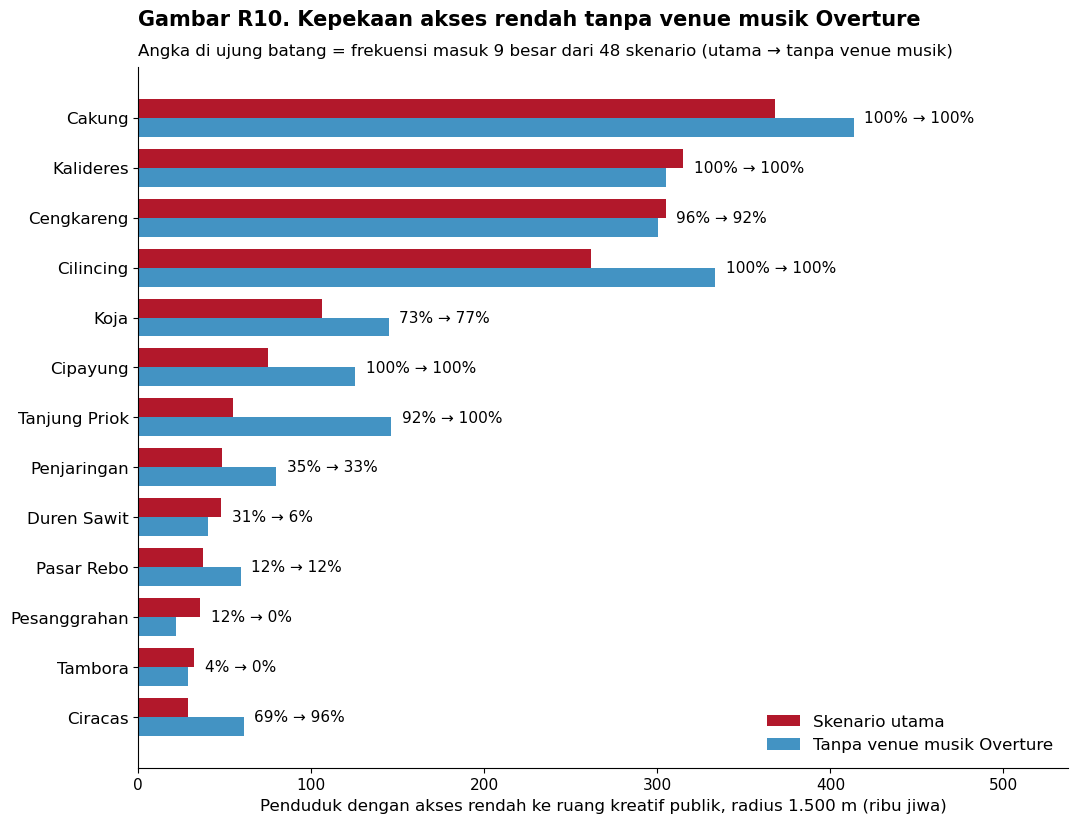


Interpretasi:
Kategori venue musik Overture menyumbang 449 dari 2.199 ruang kreatif publik Overture di Jakarta (20,4%). Setelah digabung dengan OSM, titik pasokan utama berkurang dari 2.349 menjadi 1.905.
Tanpa kategori ini, median akses kota menjadi 11,2 per 100.000 penduduk (sebelumnya 14,6). Dengan ambang yang dihitung ulang, penduduk akses rendah menjadi 2.191.383 jiwa (+24,0%); dengan ambang lama 7,3 yang dipertahankan, 3.448.780 jiwa (+95,2%).
Daftar prioritas berubah. Prioritas utama tanpa venue musik: Cakung, Cengkareng, Cilincing, Cipayung, Ciracas, Kalideres, Tanjung Priok (masuk: Ciracas). Prioritas lanjutan: Koja.
Korelasi peringkat penduduk akses rendah per kecamatan antara kedua versi: Spearman ρ = 0,96. Cakupan sembilan simpul 48,8% menjadi 42,6%, dengan 5 dari 9 lokasi yang sama.
Semua 6 kecamatan prioritas utama tetap berstatus utama, dan Ciracas naik menjadi prioritas utama. Yang peka adalah besarannya: penduduk akses rendah bergeser +24,0% dan cakupan sembilan simpu

In [12]:
# ============ SEL 9c: UJI KEPEKAAN TANPA KATEGORI VENUE MUSIK OVERTURE ============
assert OVT_OK and "_sk_stabil" in globals(), "Jalankan SEL 1-9 dulu; uji ini membutuhkan data Overture."
mulai("kepekaan_musik")
KAT_MUSIK_OVT = r"^(?:music_venue|night_club|nightclub|jazz_and_blues)$"


def tm_venue_musik(d):
    return d["kat_primer"].fillna("").astype(str).str.strip().str.lower().str.contains(KAT_MUSIK_OVT, regex=True)


def tm_xy(p):
    return np.vstack([p[0], p[1]]) if len(p[1]) else p[0]


def tm_status(f):
    return "Prioritas utama" if f >= 0.8 else ("Prioritas lanjutan" if f >= 0.5 else "-")


def tm_fsig(x):
    return ("+" if x >= 0 else "−") + fpct(abs(x))


# ---- pasokan tanpa venue musik Overture (titik OSM tidak diubah) ----
tm_rp = lambda d: _rpo(d) & ~tm_venue_musik(d)
tm_nk = lambda d: d["nonkul"] & ~tm_venue_musik(d)
PASOKAN_TM = {"Overture ruang kreatif publik": (_xy(ovt, tm_rp(ovt)), _xy(ovt_luar, tm_rp(ovt_luar))),
              "Overture non-kuliner": (_xy(ovt, tm_nk(ovt)), _xy(ovt_luar, tm_nk(ovt_luar)))}
for tm_jenis in ("ruang kreatif publik", "non-kuliner"):
    tm_a_in, tm_a_out = PASOKAN[f"OSM {tm_jenis}"]
    tm_b_in, tm_b_out = PASOKAN_TM[f"Overture {tm_jenis}"]
    PASOKAN_TM[f"gabungan {tm_jenis}"] = (_gabung_dedup(tm_a_in, tm_b_in), _gabung_dedup(tm_a_out, tm_b_out))
assert set(SUP_STABIL) <= set(PASOKAN_TM), "Definisi pasokan stabilitas tidak dikenali."

tm_n_rp = int(_rpo(ovt).sum())
tm_n_mv = int((_rpo(ovt) & tm_venue_musik(ovt)).sum())
tm_n0, tm_n1 = len(PASOKAN[SUP_UTAMA][0]), len(PASOKAN_TM[SUP_UTAMA][0])
print(f"Venue musik Overture di Jakarta: {fnum(tm_n_mv)} dari {fnum(tm_n_rp)} ruang kreatif publik Overture "
      f"({fpct(tm_n_mv / max(tm_n_rp, 1))})")
print(f"Titik pasokan '{SUP_UTAMA}' di Jakarta: {fnum(tm_n0)} -> {fnum(tm_n1)} tanpa venue musik Overture\n")

# ---- ulang skenario stabilitas dengan pasokan baru ----
SKEN_TM, AKSES_TM = [], {}
for tm_d0 in D0_LIST:
    tm_lc = cakupan_calon(CALON_UTAMA, tm_d0)
    for tm_sup in SUP_STABIL:
        tm_sxy = tm_xy(PASOKAN_TM[tm_sup])
        for tm_pnama, tm_pcol in VARIAN_POP.items():
            tm_pop = PIX[tm_pcol].to_numpy()
            tm_A_, tm_nin_, tm_dn_ = akses_2sfca(tm_sxy, tm_pop, tm_d0)
            AKSES_TM[(tm_d0, tm_sup, tm_pnama)] = (tm_A_, tm_nin_, tm_dn_)
            tm_akk = agregat_kec(tm_pop, tm_A_, tm_nin_, tm_dn_)
            tm_rendah_, _tm_ref = akses_rendah(tm_A_, tm_nin_, tm_pop)
            for tm_keb in KEBUTUHAN:
                tm_kol = "akses_rendah_memadai" if tm_keb == "data memadai" else "akses_rendah"
                tm_bobot_ = tm_pop * tm_rendah_ * ((~TIPIS) if tm_keb == "data memadai" else 1.0)
                tm_p_, tm_t_ = mclp(tm_lc, tm_bobot_)
                SKEN_TM.append({"d0": tm_d0, "pasokan": tm_sup, "penduduk": tm_pnama, "kebutuhan": tm_keb,
                                "top": tm_akk.nlargest(TOPK, tm_kol)["kecamatan"].tolist(),
                                "kebutuhan_total": float(tm_bobot_.sum()), "terlayani_mclp": float(sum(tm_t_))})
tm_frek = pd.Series(0.0, index=KEC_NAMA)
for tm_s in SKEN_TM:
    tm_frek[tm_s["top"]] += 1
tm_frek /= max(len(SKEN_TM), 1)

# ---- skenario utama tanpa venue musik ----
tm_A, tm_nin, tm_dn = AKSES_TM[(D0_UTAMA, SUP_UTAMA, POP_UTAMA_NAMA)]
tm_rendah, tm_aref = akses_rendah(tm_A, tm_nin, pop0)
tm_keb0 = pop0 * tm_rendah
tm_keb_tetap = pop0 * ((tm_nin == 0) | (tm_A < AMBANG_RENDAH * A_REF0))      # ambang lama dipertahankan
tm_ak = agregat_kec(pop0, tm_A, tm_nin, tm_dn).set_index("kecamatan")
tm_bobot0 = tm_keb0 * ((~TIPIS) if KEB_UTAMA == "data memadai" else 1.0)
tm_lc0 = cakupan_calon(CALON_UTAMA, D0_UTAMA)
tm_pil, tm_tam = mclp(tm_lc0, tm_bobot0)
tm_pil0 = mclp(tm_lc0, _bobot0)[0]
tm_pct_mclp = sum(tm_tam) / max(float(tm_bobot0.sum()), 1.0)
tm_pct_mclp0 = float(LOKASI["pct_kebutuhan_kumulatif"].iloc[-1]) if len(LOKASI) else np.nan
tm_sama_lokasi = len(set(tm_pil) & set(tm_pil0))

# ---- tabel pembanding per kecamatan ----
tm_base = AK.set_index("kecamatan")
TM_BANDING = pd.DataFrame({
    "akses_per100rb_utama": tm_base["akses_per100rb"],
    "akses_per100rb_tanpa_musik": tm_ak["akses_per100rb"],
    "akses_rendah_utama": tm_base["akses_rendah"],
    "akses_rendah_tanpa_musik": tm_ak["akses_rendah"],
    "frek_top9_utama": tm_base["frek_top9"],
    "frek_top9_tanpa_musik": tm_frek,
})
TM_BANDING["status_utama"] = TM_BANDING["frek_top9_utama"].map(tm_status)
TM_BANDING["status_tanpa_musik"] = TM_BANDING["frek_top9_tanpa_musik"].map(tm_status)
TM_BANDING = TM_BANDING.sort_values("akses_rendah_utama", ascending=False)
TM_BANDING.rename_axis("kecamatan").reset_index().round(4).to_csv(TAB / "tabel_kepekaan_tanpa_venue_musik.csv", index=False)
tm_rho = spearmanr(TM_BANDING["akses_rendah_utama"], TM_BANDING["akses_rendah_tanpa_musik"])[0]

print(f"Median akses kota: {fnum(A_REF0 * 1e5, 1)} -> {fnum(tm_aref * 1e5, 1)} per 100.000 penduduk")
print(f"Penduduk akses rendah: {fnum(_keb0.sum())} -> {fnum(tm_keb0.sum())} (ambang dihitung ulang) | "
      f"{fnum(tm_keb_tetap.sum())} (ambang lama)")
print(f"Cakupan sembilan simpul: {fpct(tm_pct_mclp0)} -> {fpct(tm_pct_mclp)} | lokasi yang sama: {tm_sama_lokasi} dari {TOPK}\n")
print(TM_BANDING.head(15).round({"akses_per100rb_utama": 1, "akses_per100rb_tanpa_musik": 1, "akses_rendah_utama": 0,
                                 "akses_rendah_tanpa_musik": 0, "frek_top9_utama": 2, "frek_top9_tanpa_musik": 2}).to_string())
print("\nLokasi simpul tanpa venue musik Overture:")
print(CALON[CALON_UTAMA].iloc[tm_pil][["nama", "jenis", "kecamatan"]].assign(urutan=range(1, len(tm_pil) + 1))
      .assign(tambahan_terlayani=np.round(tm_tam, 0)).to_string(index=False))

# ---- Gambar R10: pembanding penduduk akses rendah ----
tm_pilih = list(dict.fromkeys(list(TM_BANDING.head(12).index)
                              + list(TM_BANDING.index[(TM_BANDING["status_utama"] != "-") | (TM_BANDING["status_tanpa_musik"] != "-")])))
tm_t = TM_BANDING.loc[tm_pilih].sort_values("akses_rendah_utama", ascending=False).iloc[::-1]   # 12 terbesar + semua kecamatan prioritas
fig, ax = plt.subplots(figsize=(12, max(9, 0.7 * len(tm_t))))
tm_y = np.arange(len(tm_t))
tm_h = 0.38
ax.barh(tm_y + tm_h / 2, tm_t["akses_rendah_utama"] / 1e3, height=tm_h, color="#b2182b", label="Skenario utama")
ax.barh(tm_y - tm_h / 2, tm_t["akses_rendah_tanpa_musik"] / 1e3, height=tm_h, color="#4393c3",
        label="Tanpa venue musik Overture")
ax.set_yticks(tm_y)
ax.set_yticklabels(tm_t.index, fontsize=12)
tm_xm = max(float(tm_t[["akses_rendah_utama", "akses_rendah_tanpa_musik"]].to_numpy().max()) / 1e3, 1e-6)
for tm_i, tm_r in enumerate(tm_t.itertuples()):
    ax.text(max(tm_r.akses_rendah_utama, tm_r.akses_rendah_tanpa_musik) / 1e3 + tm_xm * 0.015, tm_i,
            f"{fnum(100 * tm_r.frek_top9_utama)}% → {fnum(100 * tm_r.frek_top9_tanpa_musik)}%", va="center", fontsize=11)
ax.set_xlim(0, tm_xm * 1.3)
ax.set_xlabel(f"Penduduk dengan akses rendah ke ruang kreatif publik, radius {fnum(D0_UTAMA)} m (ribu jiwa)", fontsize=12)
ax.set_title("Gambar R10. Kepekaan akses rendah tanpa venue musik Overture", loc="left", fontsize=15,
             fontweight="bold", pad=30)
ax.text(0, 1.012, f"Angka di ujung batang = frekuensi masuk 9 besar dari {len(SKEN_TM)} skenario (utama → tanpa venue musik)",
        transform=ax.transAxes, fontsize=12, va="bottom")
ax.tick_params(axis="x", labelsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", frameon=False, fontsize=12)
simpan(fig, "R10_kepekaan_tanpa_venue_musik.png")
plt.show()

# ---- interpretasi ----
print("\nInterpretasi:")
tm_d_rel = tm_keb0.sum() / max(_keb0.sum(), 1) - 1
tm_d_tetap = tm_keb_tetap.sum() / max(_keb0.sum(), 1) - 1
tm_u0 = set(TM_BANDING.index[TM_BANDING["status_utama"] == "Prioritas utama"])
tm_u1 = set(TM_BANDING.index[TM_BANDING["status_tanpa_musik"] == "Prioritas utama"])
tm_l0 = set(TM_BANDING.index[TM_BANDING["status_utama"] == "Prioritas lanjutan"])
tm_l1 = set(TM_BANDING.index[TM_BANDING["status_tanpa_musik"] == "Prioritas lanjutan"])
catat("kepekaan_musik", f"Kategori venue musik Overture menyumbang {fnum(tm_n_mv)} dari {fnum(tm_n_rp)} ruang kreatif publik Overture "
      f"di Jakarta ({fpct(tm_n_mv / max(tm_n_rp, 1))}). Setelah digabung dengan OSM, titik pasokan utama berkurang dari "
      f"{fnum(tm_n0)} menjadi {fnum(tm_n1)}.")
catat("kepekaan_musik", f"Tanpa kategori ini, median akses kota menjadi {fnum(tm_aref * 1e5, 1)} per 100.000 penduduk "
      f"(sebelumnya {fnum(A_REF0 * 1e5, 1)}). Dengan ambang yang dihitung ulang, penduduk akses rendah menjadi "
      f"{fnum(tm_keb0.sum())} jiwa ({tm_fsig(tm_d_rel)}); dengan ambang lama {fnum(AMBANG_RENDAH * A_REF0 * 1e5, 1)} "
      f"yang dipertahankan, {fnum(tm_keb_tetap.sum())} jiwa ({tm_fsig(tm_d_tetap)}).")
if tm_u0 == tm_u1 and tm_l0 == tm_l1:
    catat("kepekaan_musik", f"Daftar prioritas utama ({', '.join(sorted(tm_u0))}) dan lanjutan "
          f"({', '.join(sorted(tm_l0)) if tm_l0 else 'tidak ada'}) tidak berubah.")
else:
    catat("kepekaan_musik", "Daftar prioritas berubah. Prioritas utama tanpa venue musik: "
          f"{', '.join(sorted(tm_u1)) if tm_u1 else 'tidak ada'}"
          + (f" (masuk: {', '.join(sorted(tm_u1 - tm_u0))})" if tm_u1 - tm_u0 else "")
          + (f" (keluar: {', '.join(sorted(tm_u0 - tm_u1))})" if tm_u0 - tm_u1 else "")
          + f". Prioritas lanjutan: {', '.join(sorted(tm_l1)) if tm_l1 else 'tidak ada'}.")
catat("kepekaan_musik", f"Korelasi peringkat penduduk akses rendah per kecamatan antara kedua versi: Spearman ρ = {fnum(tm_rho, 2)}. "
      f"Cakupan sembilan simpul {fpct(tm_pct_mclp0)} menjadi {fpct(tm_pct_mclp)}, dengan {tm_sama_lokasi} dari {TOPK} lokasi yang sama.")
tm_keluar = tm_u0 - tm_u1
tm_masuk = tm_u1 - tm_u0
if tm_u0 == tm_u1 and abs(tm_d_rel) < 0.10 and tm_sama_lokasi >= TOPK - 2:
    catat("kepekaan_musik", "Temuan utama tahan terhadap pembuangan kategori venue musik Overture: daftar prioritas utama tetap, "
          "jumlah penduduk akses rendah bergeser kurang dari 10 persen, dan lokasi simpul hampir sama.")
elif not tm_keluar:
    catat("kepekaan_musik", f"Semua {len(tm_u0)} kecamatan prioritas utama tetap berstatus utama"
          + (f", dan {', '.join(sorted(tm_masuk))} naik menjadi prioritas utama" if tm_masuk else "")
          + f". Yang peka adalah besarannya: penduduk akses rendah bergeser {tm_fsig(tm_d_rel)} dan cakupan sembilan simpul "
          f"berubah dari {fpct(tm_pct_mclp0)} menjadi {fpct(tm_pct_mclp)}, dengan {tm_sama_lokasi} dari {TOPK} lokasi yang sama. "
          "Pembuangan seluruh kategori adalah batas ekstrem, jadi angka skenario utama dan angka tanpa venue musik dibaca sebagai rentang.")
else:
    catat("kepekaan_musik", f"{', '.join(sorted(tm_keluar))} keluar dari prioritas utama bila venue musik Overture dibuang, jadi "
          "kategori ini perlu dibersihkan sebelum daftar prioritas dipakai sebagai dasar kebijakan.")

RESULTS["kepekaan_musik"] = {"n_venue_musik_ovt": tm_n_mv, "n_ruang_publik_ovt": tm_n_rp,
                             "median_per100rb": tm_aref * 1e5, "akses_rendah": float(tm_keb0.sum()),
                             "akses_rendah_ambang_lama": float(tm_keb_tetap.sum()), "cakupan_mclp": tm_pct_mclp,
                             "lokasi_sama": tm_sama_lokasi, "prioritas_utama": sorted(tm_u1),
                             "prioritas_lanjutan": sorted(tm_l1), "spearman_akses_rendah": tm_rho}

### SEL 9d: Sampel venue musik Overture untuk cek manual

SEL 9c mengukur pengaruh kategori ini bila dibuang seluruhnya. Porsi entri yang benar-benar keliru kita ukur dengan 100 sampel acak (seed tetap) yang dilengkapi tautan peta.

Setiap sampel diberi satu dari empat label: venue musik, ruang kreatif lain, bukan ruang kreatif, atau tidak jelas.

Selama berkas `_terisi` belum ada, sel ini hanya menyimpan sampel. Setelah berkas itu ada, sel ini menghitung porsi tiap label beserta selang Wilson 95 persen. Berkas yang disimpan ulang dari Excel dengan pemisah titik koma tetap terbaca.

In [14]:
# ============ SEL 9d: SAMPEL VENUE MUSIK OVERTURE UNTUK CEK MANUAL ============
assert OVT_OK, "Sel ini membutuhkan data Overture (SEL 3b)."
mulai("cek_manual_musik")
KAT_MUSIK_OVT = globals().get("KAT_MUSIK_OVT", r"^(?:music_venue|night_club|nightclub|jazz_and_blues)$")
CM_SAMPEL = TAB / "cek_manual_venue_musik_sampel.csv"
CM_TERISI = TAB / "cek_manual_venue_musik_sampel_terisi.csv"
CM_LABEL = ["venue musik", "ruang kreatif lain", "ruang serbaguna", "bukan ruang kreatif", "tidak jelas"]
CM_ALIAS = {"ruang serba guna": "ruang serbaguna", "serbaguna": "ruang serbaguna", "serba guna": "ruang serbaguna",
            "aula serbaguna": "ruang serbaguna", "gedung serbaguna": "ruang serbaguna",
            "bukan": "bukan ruang kreatif", "venue": "venue musik"}
CM_N = 100

cm_mv = ovt[ovt["kat_primer"].fillna("").astype(str).str.strip().str.lower().str.contains(KAT_MUSIK_OVT, regex=True)].copy()
cm_mv["kota"] = cm_mv["kecamatan"].map(KEC_RESMI)
cm_mv["lon"] = cm_mv.geometry.x.round(6)
cm_mv["lat"] = cm_mv.geometry.y.round(6)
cm_prio = AK.loc[AK["status"].isin(["Prioritas utama", "Prioritas lanjutan"]), "kecamatan"].tolist()

print(f"Venue musik Overture di 42 kecamatan: {fnum(len(cm_mv))} titik")
print(cm_mv["kota"].value_counts().rename("jumlah").to_string())
print(f"Di {len(cm_prio)} kecamatan prioritas: {fnum(cm_mv['kecamatan'].isin(cm_prio).sum())} titik\n")


def cm_baris_wilson(nama, k, n):
    p, lo, hi = wilson(int(k), int(n))
    return {"ukuran": nama, "jumlah": int(k), "n": int(n), "porsi": p, "bawah_95": lo, "atas_95": hi}


if CM_TERISI.exists():
    cm_df = pd.read_csv(CM_TERISI, sep=None, engine="python", encoding="utf-8-sig")   # koma atau titik koma (Excel)
    assert "label_manual" in cm_df.columns, f"Kolom label_manual tidak ditemukan; kolom yang ada: {list(cm_df.columns)}"
    cm_df["label_manual"] = (cm_df["label_manual"].fillna("").astype(str).str.strip().str.lower()
                             .str.replace(r"\s+", " ", regex=True).replace(CM_ALIAS))
    cm_salah = cm_df[~cm_df["label_manual"].isin(CM_LABEL)]
    if len(cm_salah):
        print("Baris dengan label kosong atau di luar daftar:")
        print(cm_salah[["nama", "kecamatan", "label_manual"]].to_string())
    assert cm_salah.empty, (f"{len(cm_salah)} baris belum berlabel sah (lihat daftar di atas); "
                            f"pakai salah satu dari {CM_LABEL}")
    if len(cm_df) != CM_N:
        print(f"Catatan: berkas terisi memuat {len(cm_df)} baris, bukan {CM_N}.")
    if "ovt_id" in cm_df.columns:
        cm_asing = (~cm_df["ovt_id"].isin(cm_mv["ovt_id"])).sum()
        cm_ganda = int(cm_df["ovt_id"].duplicated().sum())
        if cm_asing or cm_ganda:
            print(f"Catatan: {cm_asing} ovt_id tidak ada di data Overture run ini, {cm_ganda} ovt_id ganda.")

    cm_n = len(cm_df)
    cm_hit = cm_df["label_manual"].value_counts().reindex(CM_LABEL, fill_value=0)
    cm_bukan, cm_serba, cm_tj = int(cm_hit["bukan ruang kreatif"]), int(cm_hit["ruang serbaguna"]), int(cm_hit["tidak jelas"])
    cm_ok = int(cm_hit["venue musik"] + cm_hit["ruang kreatif lain"])

    # ---- sebaran label ----
    cm_ringkas = pd.DataFrame([cm_baris_wilson(lb, k, cm_n) for lb, k in cm_hit.items()])
    # ---- tiga pembacaan porsi entri keliru ----
    CM_BACA = pd.DataFrame([
        cm_baris_wilson("longgar: hanya 'bukan ruang kreatif'", cm_bukan, cm_n),
        cm_baris_wilson("ketat: 'bukan ruang kreatif' + 'ruang serbaguna'", cm_bukan + cm_serba, cm_n),
        cm_baris_wilson("batas atas: ketat + 'tidak jelas'", cm_bukan + cm_serba + cm_tj, cm_n),
    ])
    CM_BACA["perkiraan_titik_bawah"] = (CM_BACA["bawah_95"] * len(cm_mv)).round(0).astype(int)
    CM_BACA["perkiraan_titik_atas"] = (CM_BACA["atas_95"] * len(cm_mv)).round(0).astype(int)
    cm_ringkas.round(4).to_csv(TAB / "tabel_cek_manual_venue_musik.csv", index=False)
    CM_BACA.round(4).to_csv(TAB / "tabel_cek_manual_venue_musik_pembacaan.csv", index=False)

    cm_fmt = lambda d: d.assign(**{c: d[c].map(fpct) for c in ("porsi", "bawah_95", "atas_95")})
    print("Sebaran label:")
    print(cm_fmt(cm_ringkas).drop(columns=["n"]).to_string(index=False))
    print("\nPorsi entri keliru menurut tiga pembacaan:")
    print(cm_fmt(CM_BACA).drop(columns=["n"]).to_string(index=False))
    if cm_serba:
        print("\nEntri berlabel 'ruang serbaguna':")
        print(cm_df.loc[cm_df["label_manual"] == "ruang serbaguna", ["nama", "kecamatan"]].to_string(index=False))

    # ---- interpretasi ----
    print("\nInterpretasi:")
    cm_l, cm_k, cm_a = CM_BACA.iloc[0], CM_BACA.iloc[1], CM_BACA.iloc[2]
    catat("cek_manual_musik", f"Dari {cm_n} sampel acak venue musik Overture: {cm_ok} berupa venue musik atau ruang kreatif lain, "
          f"{cm_serba} ruang serbaguna (aula, gedung pertemuan, ballroom), {cm_bukan} bukan ruang kreatif, dan {cm_tj} tidak dapat "
          "dipastikan.")
    catat("cek_manual_musik", f"Bila ruang serbaguna dihitung sebagai venue acara (sejalan dengan definisi ruang kreatif publik di naskah), "
          f"porsi entri keliru {fpct(cm_l['porsi'])} (selang Wilson 95% {fpct(cm_l['bawah_95'])}–{fpct(cm_l['atas_95'])}), "
          f"setara {fnum(cm_l['perkiraan_titik_bawah'])}–{fnum(cm_l['perkiraan_titik_atas'])} dari {fnum(len(cm_mv))} titik. "
          f"Bila ruang serbaguna ikut dianggap keliru, porsinya {fpct(cm_k['porsi'])} ({fpct(cm_k['bawah_95'])}–{fpct(cm_k['atas_95'])}). "
          f"Bila seluruh entri 'tidak jelas' juga keliru, batas atasnya {fpct(cm_a['porsi'])}.")
    if cm_l["bawah_95"] > 0.2:
        catat("cek_manual_musik", "Pada pembacaan paling longgar pun batas bawah selangnya di atas 20 persen, jadi kategori ini perlu "
              "disaring sebelum dipakai sebagai pasokan ruang kreatif publik.")
    elif cm_k["bawah_95"] > 0.2:
        catat("cek_manual_musik", "Perlu tidaknya penyaringan bergantung pada status ruang serbaguna: pada pembacaan ketat batas bawah "
              "selangnya di atas 20 persen, pada pembacaan longgar tidak.")
    elif cm_a["atas_95"] < 0.1:
        catat("cek_manual_musik", "Bahkan pada batas atas, entri keliru di bawah 10 persen, jadi pengaruhnya terhadap ukuran akses terbatas.")
    else:
        catat("cek_manual_musik", "Porsi entri keliru belum dapat dipastikan kecil maupun besar dari sampel ini.")
    cm_km = RESULTS.get("kepekaan_musik", {})
    if cm_km and cm_ok > 0:
        catat("cek_manual_musik", "Karena hanya sebagian kategori ini keliru, dampaknya diperkirakan berada di antara skenario utama dan "
              f"skenario tanpa venue musik di SEL 9c: penduduk akses rendah {fnum(_keb0.sum())} sampai "
              f"{fnum(cm_km['akses_rendah'])} jiwa, cakupan sembilan simpul {fpct(float(LOKASI['pct_kebutuhan_kumulatif'].iloc[-1]))} sampai "
              f"{fpct(cm_km['cakupan_mclp'])}.")
    RESULTS["cek_manual_musik"] = {"n_sampel": cm_n, "sebaran": cm_hit.to_dict(), "n_populasi": len(cm_mv),
                                   "pembacaan": CM_BACA.drop(columns=["n"]).to_dict(orient="records")}
else:
    cm_s = cm_mv.sample(n=min(CM_N, len(cm_mv)), random_state=SEED)
    cm_s = cm_s.assign(tautan_peta=[f"https://www.google.com/maps?q={la},{lo}" for la, lo in zip(cm_s["lat"], cm_s["lon"])],
                       label_manual="")
    cm_s[["ovt_id", "nama", "kat_primer", "confidence", "kecamatan", "kota", "lon", "lat", "tautan_peta", "label_manual"]] \
        .to_csv(CM_SAMPEL, index=False, encoding="utf-8-sig")
    print(f"Sampel {len(cm_s)} titik tersimpan: {CM_SAMPEL.relative_to(BASE)}")
    print(f"Isi kolom label_manual dengan salah satu: {', '.join(CM_LABEL)}.")
    print(f"Simpan sebagai {CM_TERISI.name} di folder yang sama, lalu jalankan ulang sel ini untuk menghitung porsinya.")

Venue musik Overture di 42 kecamatan: 449 titik
kota
Jakarta Selatan    135
Jakarta Timur      104
Jakarta Pusat       72
Jakarta Utara       70
Jakarta Barat       68
Di 8 kecamatan prioritas: 80 titik

Sebaran label:
             ukuran  jumlah porsi bawah_95 atas_95
        venue musik      20 20,0%    13,3%   28,9%
 ruang kreatif lain      26 26,0%    18,4%   35,4%
    ruang serbaguna       1  1,0%     0,2%    5,4%
bukan ruang kreatif      53 53,0%    43,3%   62,5%
        tidak jelas       0  0,0%     0,0%    3,7%

Porsi entri keliru menurut tiga pembacaan:
                                          ukuran  jumlah porsi bawah_95 atas_95  perkiraan_titik_bawah  perkiraan_titik_atas
            longgar: hanya 'bukan ruang kreatif'      53 53,0%    43,3%   62,5%                    194                   281
ketat: 'bukan ruang kreatif' + 'ruang serbaguna'      54 54,0%    44,3%   63,4%                    199                   285
               batas atas: ketat + 'tidak jelas'      54

SEL 10: Peta dan grafik revisi

Semua peta hanya menampilkan 42 kecamatan daratan dengan heksagon yang sudah terpotong batas. Legenda diletakkan di luar bidang peta agar tidak menutupi wilayah, dan setiap kategori diberi jumlah selnya. Ukuran huruf minimal 11–12 pt.

  gambar tersimpan: R1_kepadatan_aset.png


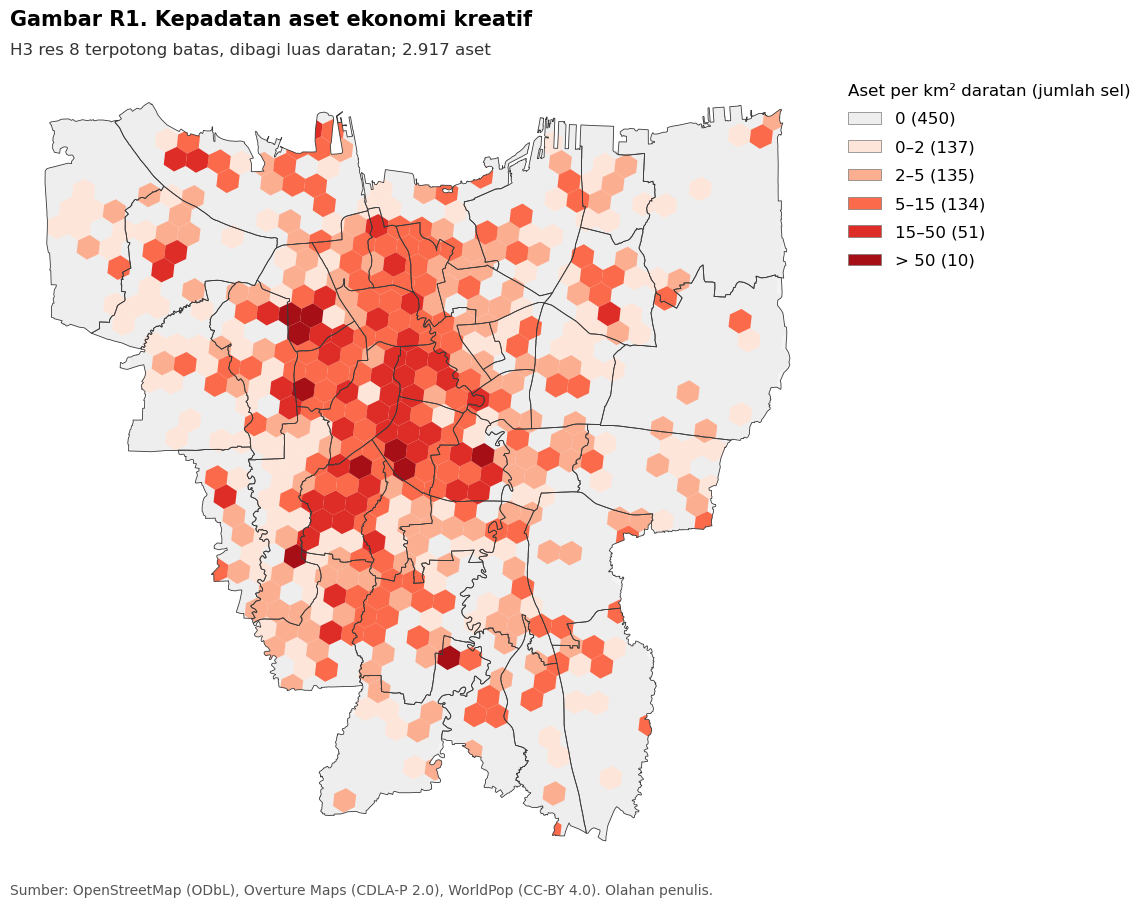

  gambar tersimpan: R2_lisa_fdr.png


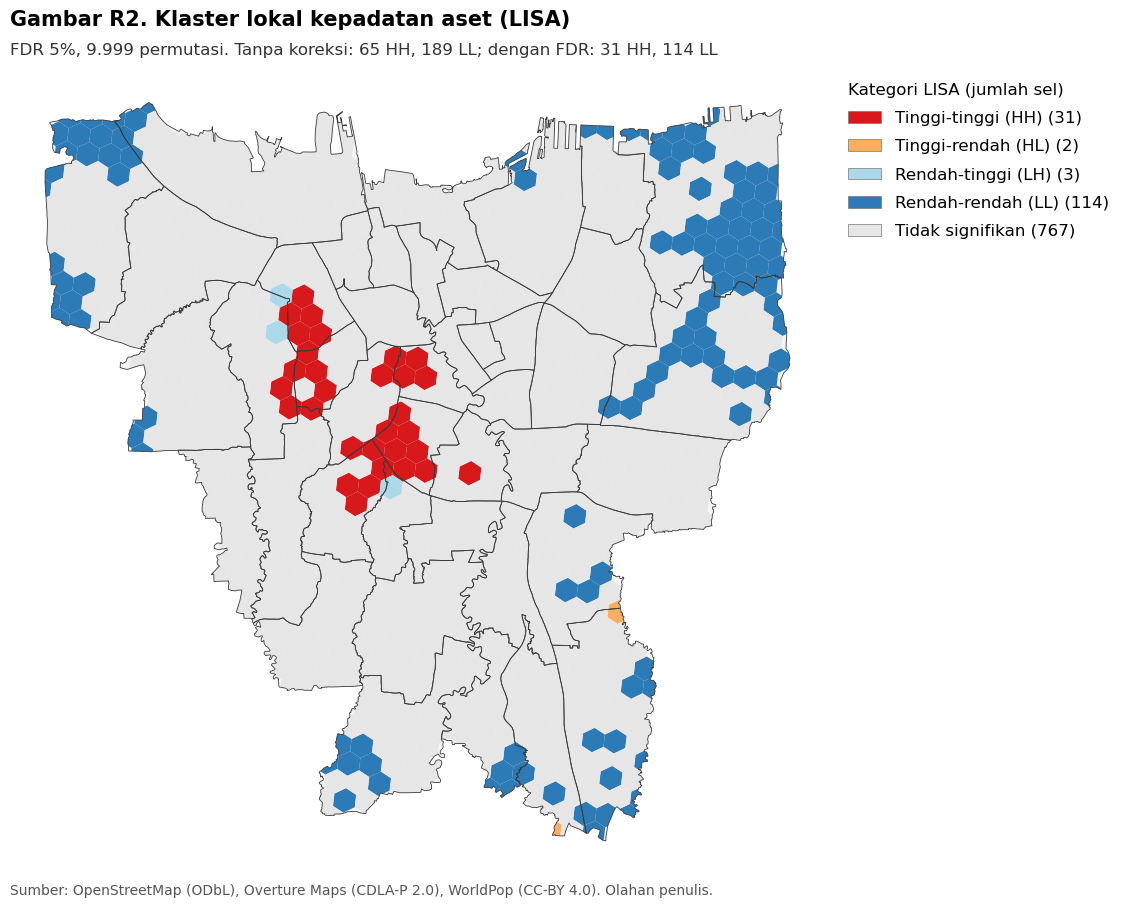

  gambar tersimpan: R3_kelengkapan_osm.png


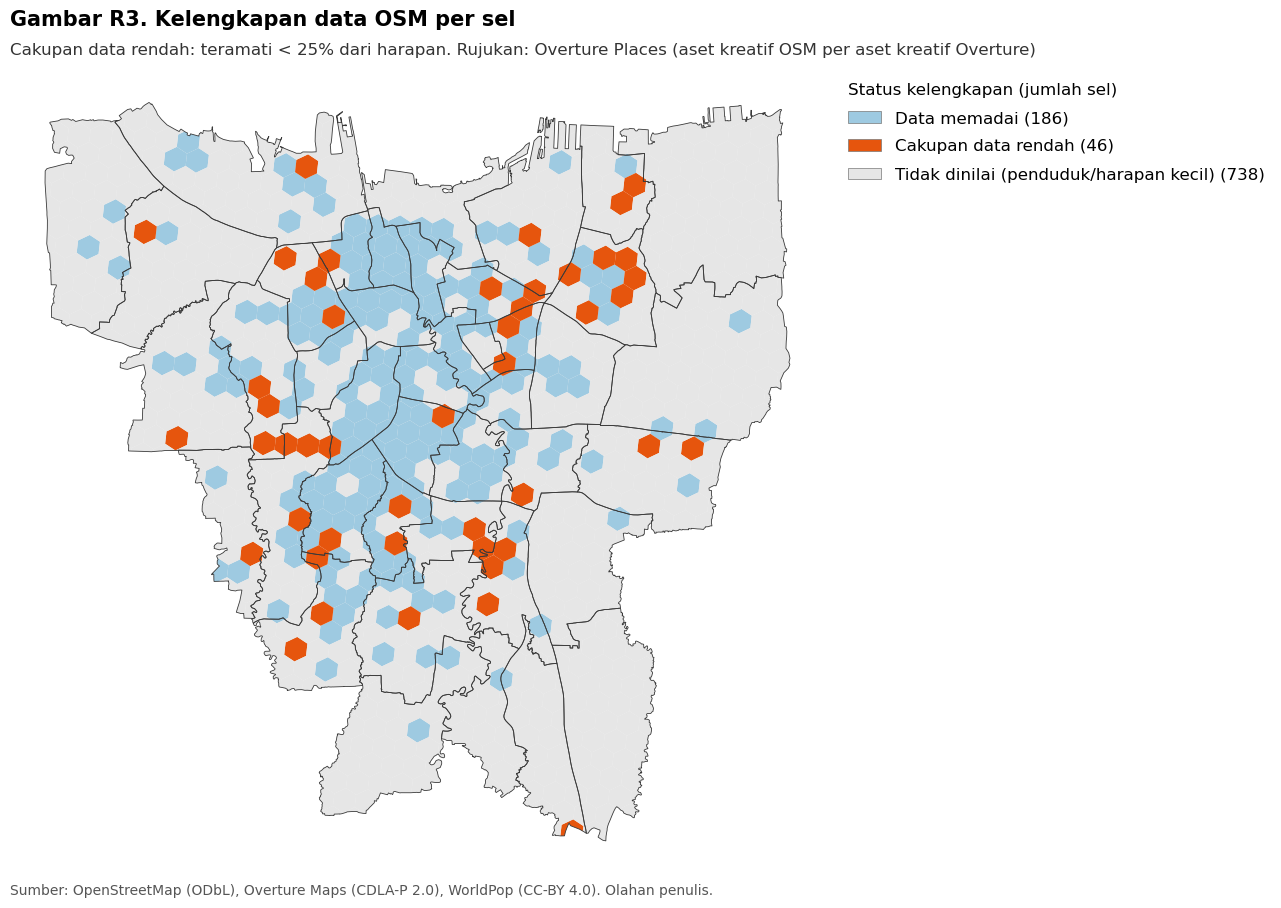

  gambar tersimpan: R4b_lisa_kondisional_wolf.png


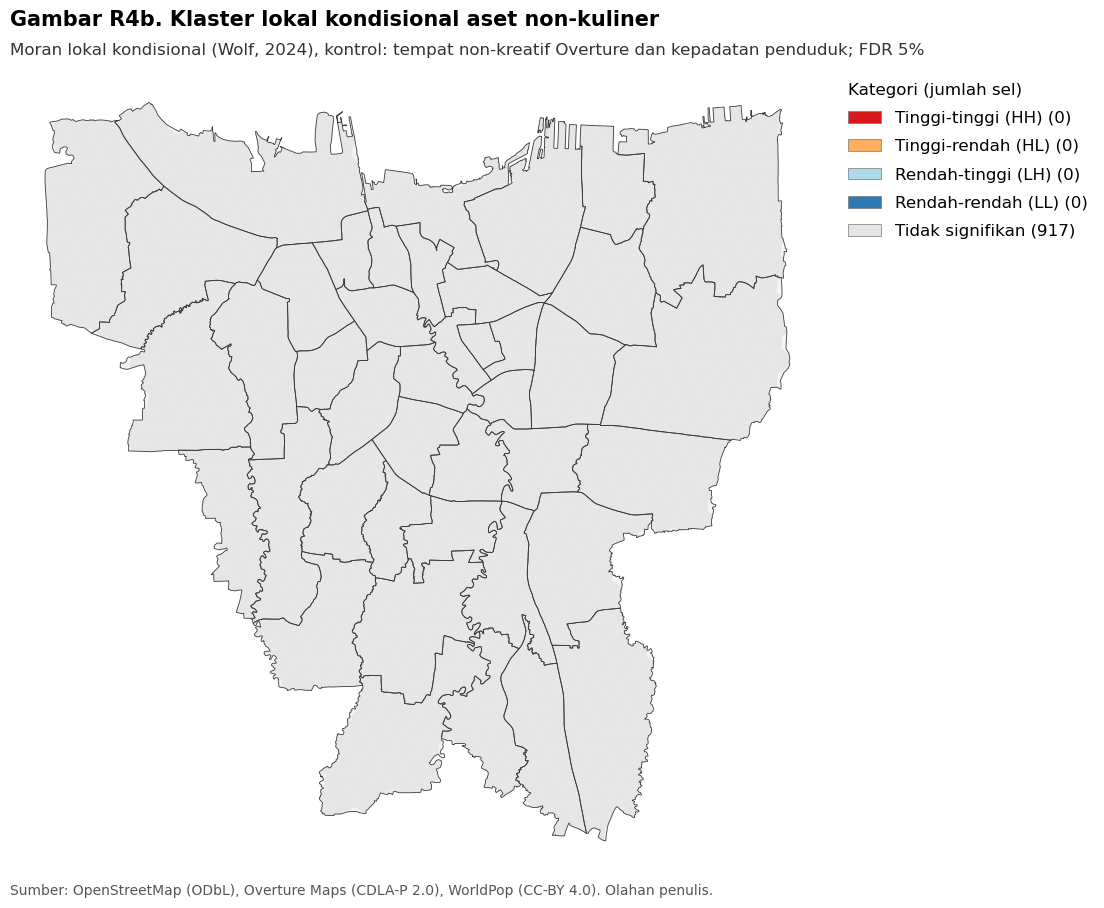

  gambar tersimpan: R4_lisa_residual.png


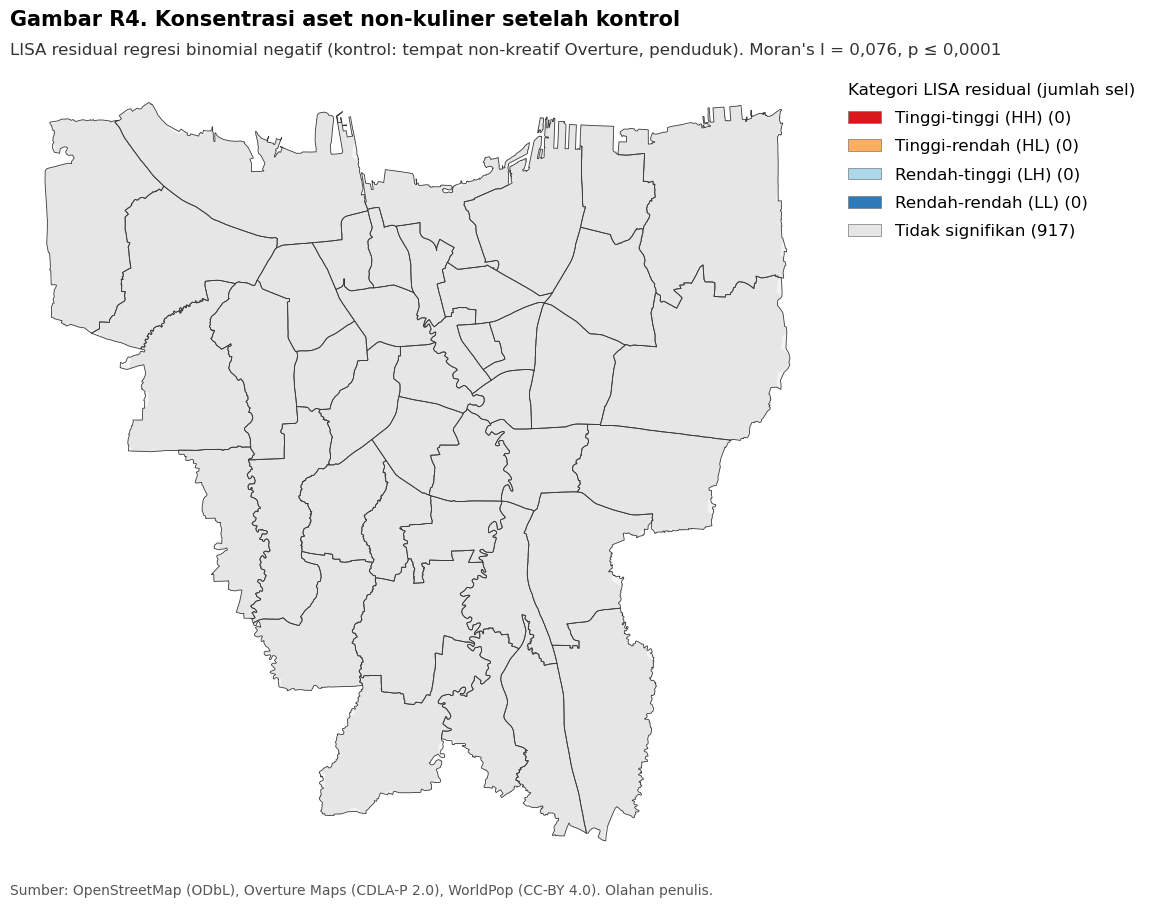

  gambar tersimpan: R5_akses_dan_simpul.png


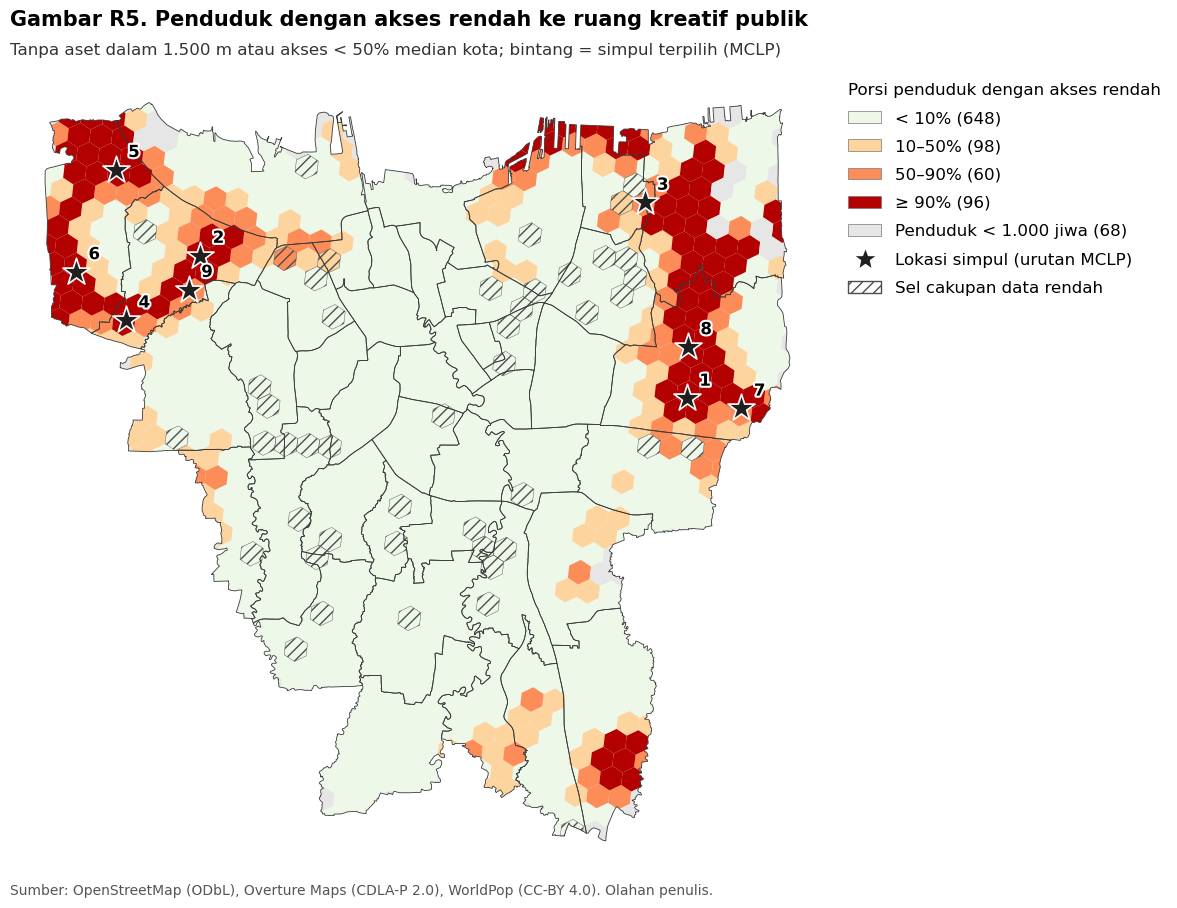

  gambar tersimpan: R6_kebutuhan_kecamatan.png


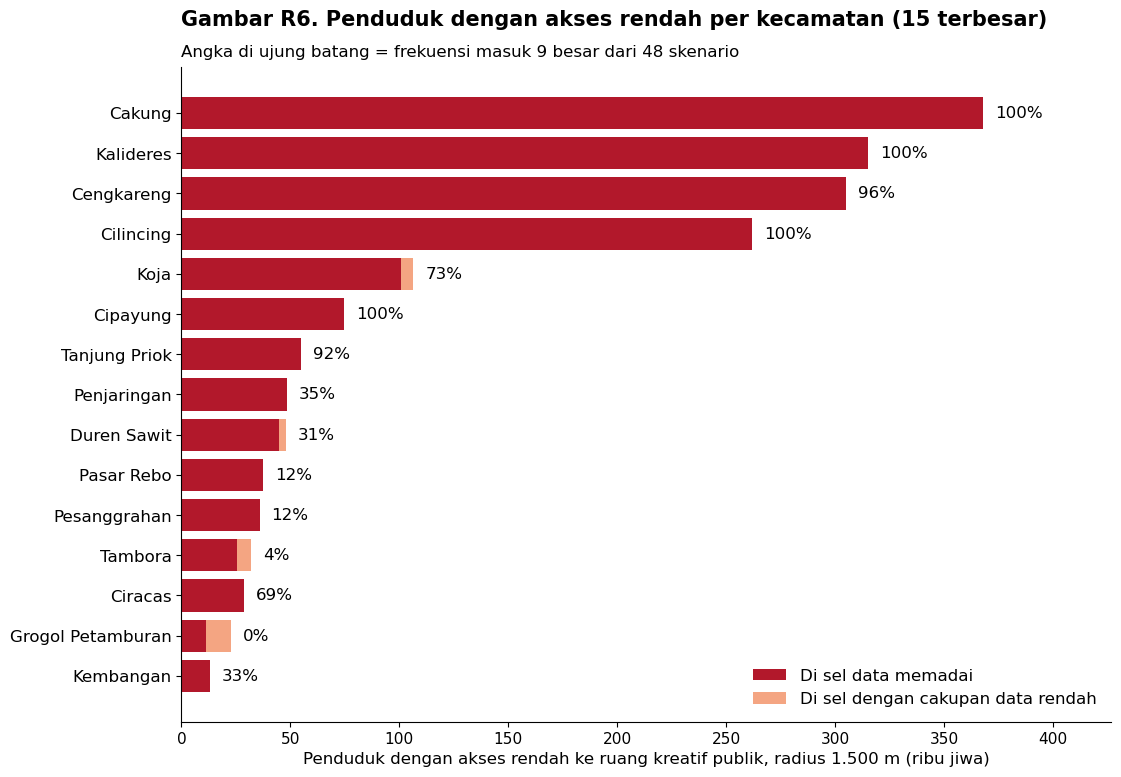

  gambar tersimpan: R7_pangsa_nonkuliner.png


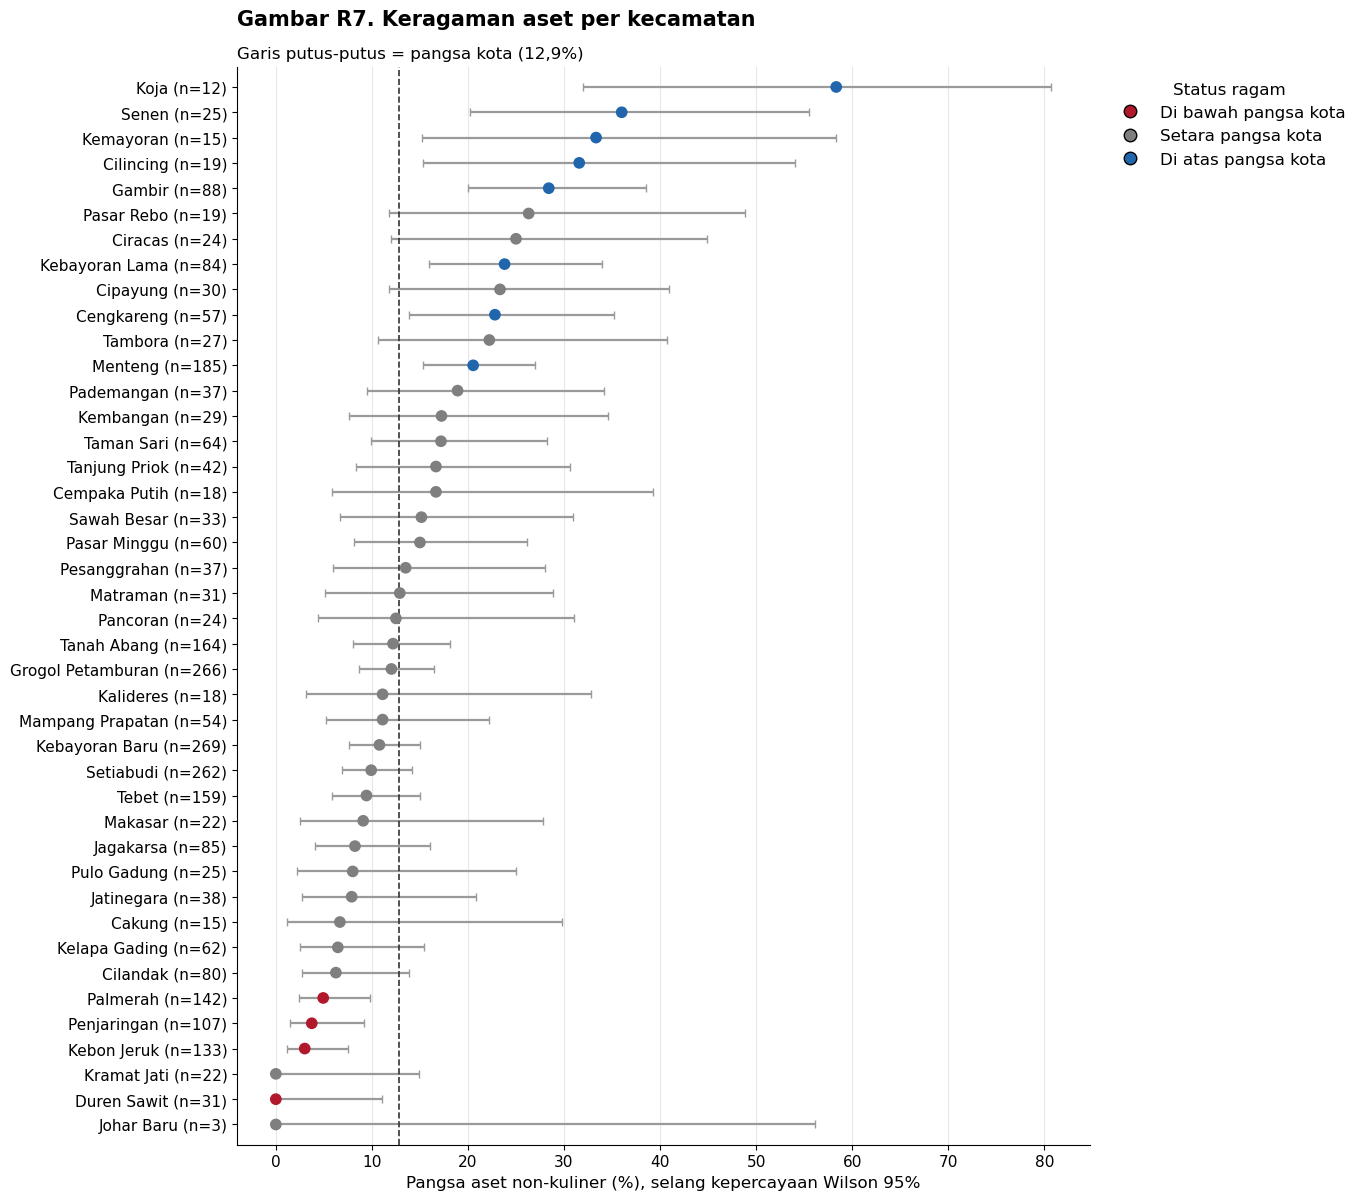

  gambar tersimpan: R8_worldpop_vs_resmi.png


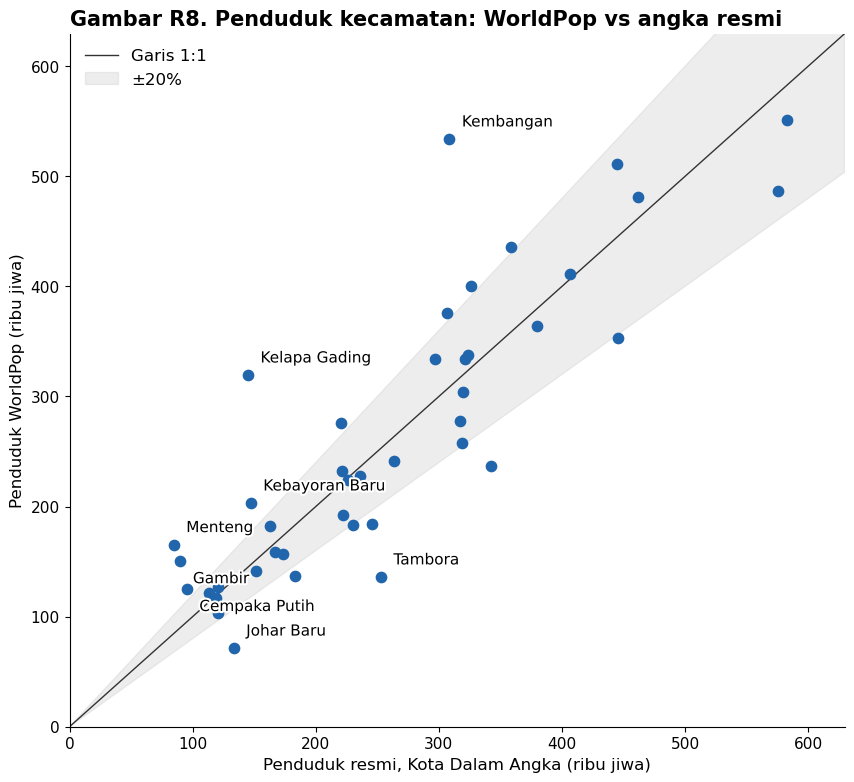

  gambar tersimpan: R9_kelengkapan_osm_vs_overture.png


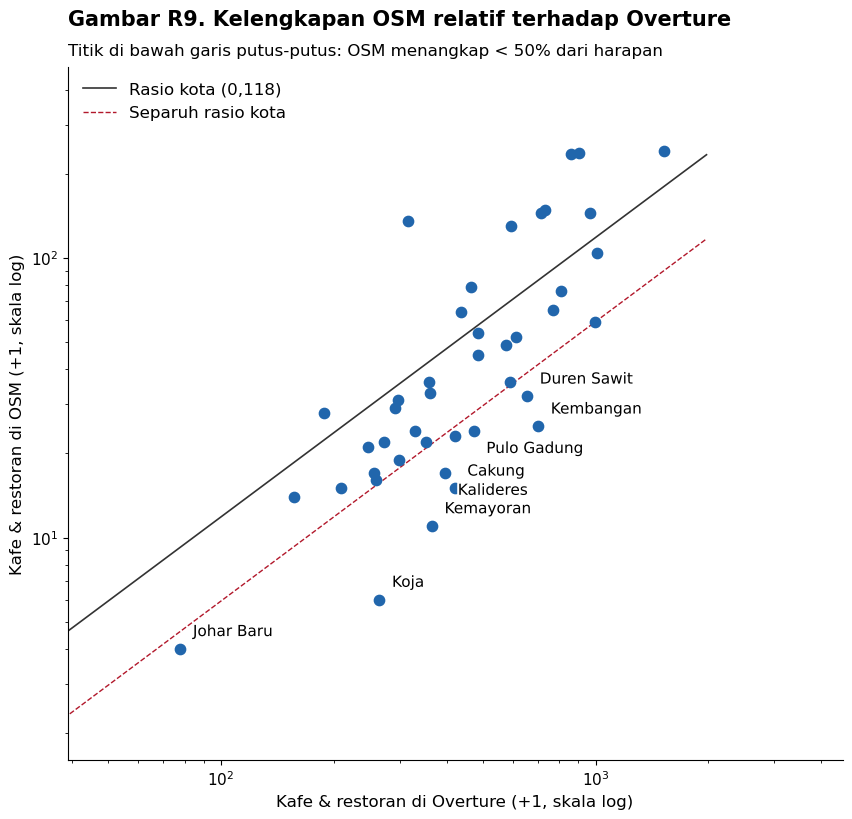

In [15]:
# ============ SEL 10: PETA & GRAFIK REVISI ============
assert "AK" in globals(), "Jalankan SEL 9 dulu."
BATAS = kec_m.total_bounds

def kanvas(judul, sub=None, ukuran=(12, 10.5)):
    fig, ax = plt.subplots(figsize=ukuran)
    ax.set_xlim(BATAS[0] - 1500, BATAS[2] + 1500)
    ax.set_ylim(BATAS[1] - 1500, BATAS[3] + 1500)
    ax.set_aspect("equal"); ax.set_axis_off()
    ax.set_title(judul, loc="left", fontsize=15, fontweight="bold", pad=30 if sub else 10)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=12, va="bottom", ha="left", color="#333333")
    kec_m.plot(ax=ax, color="#f4f4f4", linewidth=0)
    return fig, ax

def selesai(fig, ax, items, judul_leg, nama, ekstra_handles=()):
    kec_m.boundary.plot(ax=ax, color="#3a3a3a", linewidth=0.6)
    hs = [Patch(facecolor=c, edgecolor="#777777", linewidth=0.5, label=l) for l, c in items] + list(ekstra_handles)
    ax.legend(handles=hs, title=judul_leg, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False,
              fontsize=12, title_fontsize=12, labelspacing=0.8, alignment="left")
    ax.text(0, -0.01, SUMBER_PETA, transform=ax.transAxes, fontsize=10, va="top", color="#555555")
    simpan(fig, nama)
    plt.show()

def label_rapi(ax, xs, ys, teks, fontsize=11, **kw):
    # pilih posisi label yang tidak bertabrakan dengan label sebelumnya
    fig = ax.figure
    fig.canvas.draw()
    rend = fig.canvas.get_renderer()
    kandidat = [(9, 7, "left", "bottom"), (9, -7, "left", "top"), (-9, 7, "right", "bottom"),
                (-9, -7, "right", "top"), (0, 13, "center", "bottom"), (0, -13, "center", "top"),
                (16, 0, "left", "center"), (-16, 0, "right", "center")]
    kotak = []
    for x, y, t in zip(xs, ys, teks):
        dipakai = None
        for dx, dy, ha, va in kandidat:
            a = ax.annotate(t, (x, y), xytext=(dx, dy), textcoords="offset points", ha=ha, va=va, fontsize=fontsize, **kw)
            bb = a.get_window_extent(rend).expanded(1.08, 1.15)
            if not any(bb.overlaps(k) for k in kotak):
                dipakai = bb
                break
            a.remove()
        if dipakai is None:
            a = ax.annotate(t, (x, y), xytext=(9, 7), textcoords="offset points", ha="left", va="bottom",
                            fontsize=fontsize, **kw)
            dipakai = a.get_window_extent(rend)
        kotak.append(dipakai)

def peta_kategori(gdf, kolom, spesifikasi, judul, sub, judul_leg, nama, lapisan=None, ekstra_handles=()):
    fig, ax = kanvas(judul, sub)
    gd = gdf.set_geometry("geom_darat")
    items = []
    for nilai, label, warna in spesifikasi:
        s = gd[gd[kolom] == nilai]
        if len(s):
            s.plot(ax=ax, color=warna, linewidth=0)
        items.append((f"{label} ({fnum(len(s))})", warna))
    if lapisan:
        lapisan(ax)
    selesai(fig, ax, items, judul_leg, nama, ekstra_handles)

# ---- Gambar R1: kepadatan aset per km2 daratan ----
_g = GRID[8][GRID[8]["uji"]].copy()
_bins = [-0.001, 0, 2, 5, 15, 50, np.inf]
_lab = ["0", "0–2", "2–5", "5–15", "15–50", "> 50"]
_warna = ["#eeeeee", "#fee5d9", "#fcae91", "#fb6a4a", "#de2d26", "#a50f15"]
_g["kelas"] = pd.cut(_g["dens_poi"], _bins, labels=_lab).astype(str)
peta_kategori(_g, "kelas", list(zip(_lab, _lab, _warna)),
              "Gambar R1. Kepadatan aset ekonomi kreatif", f"H3 res 8 terpotong batas, dibagi luas daratan; {fnum(N_POI)} aset",
              "Aset per km² daratan (jumlah sel)", "R1_kepadatan_aset.png")

# ---- Gambar R2: LISA dengan koreksi FDR ----
_u = UJI[(8, "dens_poi")]
_spec = [("HH", "Tinggi-tinggi (HH)", "#d7191c"), ("HL", "Tinggi-rendah (HL)", "#fdae61"),
         ("LH", "Rendah-tinggi (LH)", "#abd9e9"), ("LL", "Rendah-rendah (LL)", "#2c7bb6"),
         ("ns", "Tidak signifikan", "#e6e6e6")]
peta_kategori(_u, "lisa_fdr", _spec, "Gambar R2. Klaster lokal kepadatan aset (LISA)",
              f"FDR 5%, {fnum(PERM)} permutasi. Tanpa koreksi: {r8.HH_raw} HH, {r8.LL_raw} LL; dengan FDR: {r8.HH_fdr} HH, {r8.LL_fdr} LL",
              "Kategori LISA (jumlah sel)", "R2_lisa_fdr.png")

# ---- Gambar R3: kelengkapan data OSM ----
if KOMPLIT_OK:
    _g = GRID[8].copy()
    _g["kelengkapan"] = np.select(
        [_g["data_tipis"], (_g["pop"] >= POP_MIN_SEL) & (_g["lengkap_harapan"] >= LENGKAP_HARAPAN_MIN)],
        ["tipis", "memadai"], "tidak dinilai")
    peta_kategori(_g, "kelengkapan", [("memadai", "Data memadai", "#9ecae1"), ("tipis", "Cakupan data rendah", "#e6550d"),
                                      ("tidak dinilai", "Tidak dinilai (penduduk/harapan kecil)", "#e6e6e6")],
                  "Gambar R3. Kelengkapan data OSM per sel",
                  f"Cakupan data rendah: teramati < {fnum(LENGKAP_RASIO_MIN * 100)}% dari harapan. Rujukan: {SUMBER_LENGKAP}",
                  "Status kelengkapan (jumlah sel)", "R3_kelengkapan_osm.png")

# ---- Gambar R4: konsentrasi di luar intensitas pemetaan ----
if globals().get("WOLF") is not None:
    peta_kategori(UJI[("wolf", "nonkul")], "wolf_fdr", _spec, "Gambar R4b. Klaster lokal kondisional aset non-kuliner",
                  f"Moran lokal kondisional (Wolf, 2024), kontrol: {CTRL_LABEL} dan kepadatan penduduk; FDR 5%",
                  "Kategori (jumlah sel)", "R4b_lisa_kondisional_wolf.png")
if HAS_SM and ("resid", "y_nk") in UJI:
    _o = NB_HASIL["y_nk"]["moran"]
    peta_kategori(UJI[("resid", "y_nk")], "lisa_fdr", _spec,
                  "Gambar R4. Konsentrasi aset non-kuliner setelah kontrol",
                  f"LISA residual regresi binomial negatif (kontrol: {CTRL_LABEL}, penduduk). Moran's I = {fnum(_o['I'], 3)}, {fp(_o['p'])}",
                  "Kategori LISA residual (jumlah sel)", "R4_lisa_residual.png")

# ---- Gambar R5: penduduk tanpa aset & lokasi simpul ----
_g = GRID[8].copy()
_v = PIX["sel8"].to_numpy(); _ok = _v >= 0
_num = np.bincount(_v[_ok], weights=_keb0[_ok], minlength=len(_g))
_den = np.bincount(_v[_ok], weights=pop0[_ok], minlength=len(_g))
_g["pct_tanpa"] = np.where(_den > 0, _num / np.maximum(_den, 1e-9), np.nan)
_g["kelas"] = np.select([_g["pop"] < POP_MIN_SEL, _g["pct_tanpa"] < 0.10, _g["pct_tanpa"] < 0.50, _g["pct_tanpa"] < 0.90],
                        ["sepi", "a", "b", "c"], "d")
_spec5 = [("a", "< 10%", "#edf8e9"), ("b", "10–50%", "#fdd49e"), ("c", "50–90%", "#fc8d59"), ("d", "≥ 90%", "#b30000"),
          ("sepi", f"Penduduk < {fnum(POP_MIN_SEL)} jiwa", "#e6e6e6")]

def _lapisan5(ax):
    if KOMPLIT_OK:
        _gt = _g[_g["data_tipis"]].set_geometry("geom_darat")
        if len(_gt):
            _gt.plot(ax=ax, facecolor="none", edgecolor="#4d4d4d", hatch="///", linewidth=0.3)
    if len(LOKASI):
        ax.scatter(LOKASI["x"], LOKASI["y"], marker="*", s=420, c="#1f1f1f", edgecolors="white", linewidths=1.2, zorder=6)
        label_rapi(ax, LOKASI["x"], LOKASI["y"], LOKASI["urutan"].astype(str), fontsize=12, fontweight="bold", zorder=7,
                   path_effects=[pe.withStroke(linewidth=3, foreground="white")])

_ekstra = [Line2D([0], [0], marker="*", color="none", markerfacecolor="#1f1f1f", markeredgecolor="white",
                  markersize=18, label="Lokasi simpul (urutan MCLP)")]
if KOMPLIT_OK:
    _ekstra.append(Patch(facecolor="white", edgecolor="#4d4d4d", hatch="///", label="Sel cakupan data rendah"))
peta_kategori(_g, "kelas", _spec5, "Gambar R5. Penduduk dengan akses rendah ke ruang kreatif publik",
              f"Tanpa aset dalam {fnum(D0_UTAMA)} m atau akses < {fnum(AMBANG_RENDAH * 100)}% median kota; bintang = simpul terpilih (MCLP)",
              "Porsi penduduk dengan akses rendah", "R5_akses_dan_simpul.png", lapisan=_lapisan5, ekstra_handles=_ekstra)

# ---- Gambar R6: kebutuhan tak terlayani per kecamatan + stabilitas ----
_t = AK.sort_values("akses_rendah", ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 8.5))
if KOMPLIT_OK:
    ax.barh(_t["kecamatan"], _t["akses_rendah_memadai"] / 1e3, color="#b2182b", label="Di sel data memadai")
    ax.barh(_t["kecamatan"], _t["akses_rendah_tipis"] / 1e3, left=_t["akses_rendah_memadai"] / 1e3, color="#f4a582",
            label="Di sel dengan cakupan data rendah")
else:
    ax.barh(_t["kecamatan"], _t["akses_rendah"] / 1e3, color="#b2182b", label="Penduduk dengan akses rendah")
_xm = max((_t["akses_rendah"] / 1e3).max(), 1e-6)
for i, r in enumerate(_t.itertuples()):
    ax.text(r.akses_rendah / 1e3 + _xm * 0.015, i, f"{fnum(100 * r.frek_top9)}%", va="center", fontsize=12)
ax.set_xlim(0, _xm * 1.16)
ax.set_xlabel(f"Penduduk dengan akses rendah ke ruang kreatif publik, radius {fnum(D0_UTAMA)} m (ribu jiwa)", fontsize=12)
ax.set_title("Gambar R6. Penduduk dengan akses rendah per kecamatan (15 terbesar)", loc="left", fontsize=15, fontweight="bold", pad=30)
ax.text(0, 1.012, f"Angka di ujung batang = frekuensi masuk 9 besar dari {N_SKEN} skenario", transform=ax.transAxes,
        fontsize=12, va="bottom")
ax.tick_params(axis="y", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", frameon=False, fontsize=12)
simpan(fig, "R6_kebutuhan_kecamatan.png"); plt.show()

# ---- Gambar R7: pangsa non-kuliner dengan selang Wilson ----
_e = ENT[ENT["n_aset"] > 0].sort_values("pangsa_nonkul").reset_index(drop=True)
_wr = {"di bawah pangsa kota": "#b2182b", "setara pangsa kota": "#7f7f7f", "di atas pangsa kota": "#2166ac"}
fig, ax = plt.subplots(figsize=(11, 14))
_y = np.arange(len(_e))
ax.errorbar(_e["pangsa_nonkul"] * 100, _y, xerr=[(_e["pangsa_nonkul"] - _e["ci_bawah"]) * 100,
                                                  (_e["ci_atas"] - _e["pangsa_nonkul"]) * 100],
            fmt="none", ecolor="#9a9a9a", elinewidth=1.6, capsize=3)
ax.scatter(_e["pangsa_nonkul"] * 100, _y, c=_e["status_ragam"].map(_wr).fillna("#7f7f7f"), s=55, zorder=3)
ax.axvline(PANGSA_KOTA * 100, color="#333333", linestyle="--", linewidth=1.2)
ax.set_yticks(_y)
ax.set_yticklabels([f"{r.kecamatan} (n={r.n_aset})" for r in _e.itertuples()], fontsize=11)
ax.set_ylim(-0.8, len(_e) - 0.2)
ax.set_xlabel("Pangsa aset non-kuliner (%), selang kepercayaan Wilson 95%", fontsize=12)
ax.set_title("Gambar R7. Keragaman aset per kecamatan", loc="left", fontsize=15, fontweight="bold", pad=30)
ax.text(0, 1.005, f"Garis putus-putus = pangsa kota ({fpct(PANGSA_KOTA)})", transform=ax.transAxes, fontsize=12, va="bottom")
ax.legend(handles=[Line2D([0], [0], marker="o", color="none", markerfacecolor=c, markersize=9, label=l.capitalize())
                   for l, c in _wr.items()], title="Status ragam", loc="upper left", bbox_to_anchor=(1.01, 1.0),
          frameon=False, fontsize=12, title_fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
simpan(fig, "R7_pangsa_nonkuliner.png"); plt.show()

# ---- Gambar R8: WorldPop vs penduduk resmi ----
if BPS_OK:
    _p = POPCMP.dropna(subset=["penduduk_resmi"])
    fig, ax = plt.subplots(figsize=(10, 9))
    ax.scatter(_p["penduduk_resmi"] / 1e3, _p["penduduk_worldpop"] / 1e3, s=55, color="#2166ac", zorder=3)
    _mx = max(_p["penduduk_resmi"].max(), _p["penduduk_worldpop"].max()) / 1e3 * 1.08
    ax.plot([0, _mx], [0, _mx], color="#333333", linewidth=1, label="Garis 1:1")
    ax.fill_between([0, _mx], [0, _mx * 0.8], [0, _mx * 1.2], color="#cccccc", alpha=0.35, label="±20%")
    ax.set_xlim(0, _mx); ax.set_ylim(0, _mx)
    _ex = _p.assign(d=(_p["rasio_wp_resmi"] - 1).abs()).sort_values("d", ascending=False).head(8)
    label_rapi(ax, _ex["penduduk_resmi"] / 1e3, _ex["penduduk_worldpop"] / 1e3, _ex["kecamatan"], fontsize=11,
               path_effects=[pe.withStroke(linewidth=3, foreground="white")])
    ax.set_xlabel("Penduduk resmi, Kota Dalam Angka (ribu jiwa)", fontsize=12); ax.set_ylabel("Penduduk WorldPop (ribu jiwa)", fontsize=12)
    ax.set_title("Gambar R8. Penduduk kecamatan: WorldPop vs angka resmi", loc="left", fontsize=15, fontweight="bold")
    ax.legend(loc="upper left", frameon=False, fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    simpan(fig, "R8_worldpop_vs_resmi.png"); plt.show()

# ---- Gambar R9: kelengkapan OSM terhadap Overture per kecamatan ----
if OVT_OK:
    _k = OVTKEC.copy()
    fig, ax = plt.subplots(figsize=(10, 9))
    ax.scatter(_k["ovt_kuliner"] + 1, _k["osm_kuliner"] + 1, s=55, color="#2166ac", zorder=3)
    _lj = _k["osm_kuliner"].sum() / max(_k["ovt_kuliner"].sum(), 1)
    _xx = np.array([1, (_k["ovt_kuliner"].max() + 1) * 1.3])
    ax.plot(_xx, _xx * _lj, color="#333333", linewidth=1.2, label=f"Rasio kota ({fnum(_lj, 3)})")
    ax.plot(_xx, _xx * _lj * 0.5, color="#b2182b", linewidth=1, linestyle="--", label="Separuh rasio kota")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(max(0.8, (_k["ovt_kuliner"].min() + 1) * 0.5), (_k["ovt_kuliner"].max() + 1) * 3)
    ax.set_ylim(max(0.5, (_k["osm_kuliner"].min() + 1) * 0.4), (_k["osm_kuliner"].max() + 1) * 2)
    _ex = _k.sort_values("kelengkapan_relatif").head(8)
    label_rapi(ax, _ex["ovt_kuliner"] + 1, _ex["osm_kuliner"] + 1, _ex["kecamatan"], fontsize=11,
               path_effects=[pe.withStroke(linewidth=3, foreground="white")])
    ax.set_xlabel("Kafe & restoran di Overture (+1, skala log)", fontsize=12)
    ax.set_ylabel("Kafe & restoran di OSM (+1, skala log)", fontsize=12)
    ax.set_title("Gambar R9. Kelengkapan OSM relatif terhadap Overture", loc="left", fontsize=15, fontweight="bold", pad=30)
    ax.text(0, 1.012, "Titik di bawah garis putus-putus: OSM menangkap < 50% dari harapan", transform=ax.transAxes,
            fontsize=12, va="bottom")
    ax.legend(loc="upper left", frameon=False, fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    simpan(fig, "R9_kelengkapan_osm_vs_overture.png"); plt.show()

## SEL 11: Klaim naskah dibandingkan hasil revisi

Sel ini menyusun daftar klaim naskah Tahap 2 beserta hasil revisinya dan statusnya, lalu memeriksa ulang tabel prioritas lama untuk errata angka. Bagian terakhir mencetak seluruh kalimat interpretasi dari sel-sel sebelumnya dalam satu tempat supaya mudah disalin ke slide koreksi.

In [16]:
# ============ SEL 11: KLAIM NASKAH vs HASIL REVISI + ERRATA ============
assert "AK" in globals(), "Jalankan SEL 1-10 dulu."
mulai("errata")
_klaim = []
def klaim(no, naskah, revisi, status):
    _klaim.append({"no": no, "klaim_naskah": naskah, "hasil_revisi": revisi, "status": status})

klaim(1, "Moran's I res 8 = 0,369, p = 0,001 ('tingkat kepercayaan 99,9%')",
      f"Moran's I = {fnum(r8.I, 3)}, {fp(r8.p)} ({fnum(PERM)} permutasi, 42 kecamatan daratan, densitas per luas daratan)",
      "Arah sama, angka dan pelaporan p dikoreksi" if r8.p < ALPHA else "Tidak signifikan setelah koreksi")
klaim(2, "61 sel HH dan 186 sel LL",
      f"α mentah: {r8.HH_raw} HH, {r8.LL_raw} LL. FDR: {r8.HH_fdr} HH, {r8.LL_fdr} LL. Gi* dingin (FDR): {r8.dingin_fdr}",
      "Dikoreksi; gunakan angka FDR")
klaim(3, "LL naik ke 335 tanpa kuliner, kuliner 'menyamarkan' ketimpangan",
      f"Sel nol naik {fpct(r8.pct_sel_nol)} → {fpct(r8n.pct_sel_nol)}; LL α mentah {r8.LL_raw} → {r8n.LL_raw}, "
      f"FDR {r8.LL_fdr} → {r8n.LL_fdr}",
      "Klaim ditarik; jumlah LL mengikuti porsi sel nol")
klaim(4, "Pada res 7 pola 'sedikit menguat' tanpa kuliner (0,434 vs 0,425)",
      f"{fnum(r7n.I, 3)} vs {fnum(r7.I, 3)}; selisih {fnum(abs(r7n.I - r7.I) / math.sqrt(r7.sd_null**2 + r7n.sd_null**2), 2)} SD acak",
      "Klaim ditarik" if abs(r7n.I - r7.I) / math.sqrt(r7.sd_null**2 + r7n.sd_null**2) < 2 else "Perlu dibaca hati-hati")
if KOMPLIT_OK and globals().get("KONTROL"):
    _nm0, _h0 = list(KONTROL.items())[0]
    klaim(5, "Pengelompokan mengindikasikan aglomerasi Marshallian",
          f"[{_nm0}] Moran's I pangsa aset non-kuliner (EB) = {fnum(_h0['moran_rate'], 3)}, {fp(_h0['p_rate'])}"
          + (f"; residual setelah kontrol titik non-kreatif & penduduk: I = {fnum(_h0['moran_resid'], 3)}, {fp(_h0['p_resid'])}"
             if "moran_resid" in _h0 else ""),
          "Dilunakkan: konsentrasi mengikuti pusat komersial, dengan spesialisasi kreatif lemah"
          if (_h0["p_rate"] < ALPHA and _h0["moran_rate"] > 0) else "Ditarik: tidak ada spesialisasi kreatif di luar pola komersial")
else:
    klaim(5, "Pengelompokan mengindikasikan aglomerasi Marshallian", "Kontrol intensitas pemetaan belum dapat dijalankan",
          "Dilunakkan; sebut sebagai keterbatasan")
klaim(6, "Entropi 8 kecamatan IKIK tertinggi 0,330 vs 9 prioritas 0,111 ('tiga kali lebih rendah')",
      f"Pangsa non-kuliner {fpct(_a['pangsa_nonkul'])} ({fpct(_a['ci_bawah'])}–{fpct(_a['ci_atas'])}) vs "
      f"{fpct(_b['pangsa_nonkul'])} ({fpct(_b['ci_bawah'])}–{fpct(_b['ci_atas'])}); kecamatan prioritas cukup data untuk "
      f"rarefaksi: {_b['n_kec_cukup_data']}/9"
      + (f". Overture: {fpct(KELOMPOK_OVT.iloc[0]['pangsa_nonkul_ovt'])} vs {fpct(KELOMPOK_OVT.iloc[1]['pangsa_nonkul_ovt'])}"
         if globals().get("KELOMPOK_OVT") is not None else ""),
      ("Arah sama, besaran jauh di bawah 'tiga kali'; pakai angka Overture + CI"
       if globals().get("KELOMPOK_OVT") is not None and KELOMPOK_OVT.iloc[0]["pangsa_nonkul_ovt"] > KELOMPOK_OVT.iloc[1]["pangsa_nonkul_ovt"]
       else "Diganti ukuran pangsa non-kuliner + CI"))
klaim(7, "Sembilan kecamatan prioritas (Johar Baru … Kembangan)",
      f"Prioritas utama: {', '.join(_stabil) or '-'}; lanjutan: {', '.join(_syarat) or '-'}; beririsan dengan naskah: "
      f"{len(_lama & _baru)}/9", "Daftar diganti hasil revisi")
_p9 = AK[AK["kecamatan"].isin(NASKAH["prioritas9"])]
klaim(8, "Sembilan kecamatan prioritas dihuni 2.489.452 jiwa",
      f"{fnum(_p9['penduduk'].sum())} jiwa ({POP_UTAMA_NAMA}, penjumlahan piksel per poligon)", "Dikoreksi")
klaim(9, "Gurun kreatif mencakup 21,4% wilayah (186 sel LL)",
      f"Tanpa aset non-kuliner dalam {fnum(D0_UTAMA)} m: {fnum(_tanpa0.sum())} jiwa ({fpct(_tanpa0.sum() / _tot)}; OSM saja "
      f"{fpct(_tanpa_osm / _tot)}). Dengan akses rendah ke ruang kreatif publik: {fnum(_keb0.sum())} jiwa ({fpct(_keb0.sum() / _tot)})",
      "Definisi diganti ukuran berbasis penduduk")
_hp = AK.loc[AK["status"].isin(["Prioritas utama", "Prioritas lanjutan"]), "pct_pend_400m_halte"]
klaim(10, "Kedekatan transit (≤400 m) adalah kabar baik untuk kecamatan prioritas",
      (f"{fpct(_ph)} seluruh penduduk ≤400 m dari halte; transit tidak membedakan kecamatan" if _ph > 0.8 else
       f"{fpct(_ph)} seluruh penduduk ≤400 m dari halte; di kecamatan prioritas revisi porsinya "
       f"{fpct(_hp.min(), 0)}–{fpct(_hp.max(), 0)}" if len(_hp) else f"{fpct(_ph)} seluruh penduduk ≤400 m dari halte"),
      "Transit dipindah menjadi kolom kelayakan terpisah")
_nd = {k: int(ENT.loc[ENT["kecamatan"] == k, "n_nonkul"].iloc[0]) for k in ("Duren Sawit", "Johar Baru")}
klaim(11, "Duren Sawit dan Johar Baru tanpa satu pun aset non-kuliner",
      f"Titik-dalam-poligon (Juli): Duren Sawit {_nd['Duren Sawit']}, Johar Baru {_nd['Johar Baru']}",
      "Tetap" if sum(_nd.values()) == 0 else "Dikoreksi")
if OVT_OK and len(TAB_MORAN) > 5:
    _ro = TAB_MORAN.iloc[5]
    klaim(12, "Pola konsentrasi aset kreatif di pusat kota (berbasis OSM)",
          f"Data independen Overture: Moran's I aset non-kuliner = {fnum(_ro.I, 3)}, {fp(_ro.p)}; OSM menangkap sekitar "
          f"{fpct(RESULTS.get('overture', {}).get('rasio_osm_overture', np.nan), 0)} aset kreatif Overture",
          "Diperkuat oleh sumber independen" if (_ro.p < ALPHA and _ro.I > 0) else "Tidak terkonfirmasi sumber independen")
KLAIM = pd.DataFrame(_klaim)
KLAIM.to_csv(TAB / "tabel_klaim_vs_revisi.csv", index=False)
for r in KLAIM.itertuples():
    print(f"[{r.no}] Naskah : {r.klaim_naskah}\n    Revisi : {r.hasil_revisi}\n    Status : {r.status}\n")

# ---- errata tabel prioritas Tahap 2 ----
_lama_f = BASE / "outputs" / "tables" / "tabel_prioritas_kecamatan.csv"
if _lama_f.exists():
    _l = pd.read_csv(_lama_f)
    _l = _l[_l["kecamatan"].isin(KEC_RESMI)]
    _tot_poi = int(_l["n_poi"].sum())
    _i5 = _l.nlargest(5, "IKIK")
    _c5 = _l.nlargest(5, "n_poi")
    _p9l = _l.nlargest(9, "prioritas")
    _jauh = _p9l[_p9l["jarak_transit_m"] > 400]
    print("Errata tabel Tahap 2 (dihitung dari tabel_prioritas_kecamatan.csv):")
    catat("errata", f"Lima kecamatan IKIK tertinggi ({', '.join(_i5['kecamatan'])}) menampung {fnum(_i5['n_poi'].sum())} aset "
          f"({fpct(_i5['n_poi'].sum() / _tot_poi)}) dan {fnum(_i5['n_nonkuliner'].sum())} aset non-kuliner. Angka 1.153 (39,8%) "
          f"di naskah adalah lima kecamatan dengan aset terbanyak ({', '.join(_c5['kecamatan'])}: {fnum(_c5['n_poi'].sum())}).")
    catat("errata", f"Kecamatan dengan kurang dari lima aset non-kuliner: {int((_l['n_nonkuliner'] < 5).sum())} (naskah: 12).")
    if len(_jauh):
        catat("errata", "Tidak semua sembilan prioritas lama berjarak ≤400 m dari transit: "
              + ", ".join(f"{r.kecamatan} {fnum(r.jarak_transit_m)} m" for r in _jauh.itertuples()) + ".")
else:
    print("tabel_prioritas_kecamatan.csv Tahap 2 tidak ditemukan; pengecekan errata dilewati.")

print("\n" + "=" * 100 + "\nKALIMAT INTERPRETASI (hasil run ini, siap dikutip)\n" + "=" * 100)
_urut = ["wilayah", "snapshot", "overture", "grid", "penduduk", "moran", "kontrol", "entropi", "akses", "errata"]
for bag in _urut:
    _ts = [t for b, t in CATATAN if b == bag]
    if _ts:
        print(f"\n[{bag.upper()}]")
        for t in _ts:
            print(" -", t)

[1] Naskah : Moran's I res 8 = 0,369, p = 0,001 ('tingkat kepercayaan 99,9%')
    Revisi : Moran's I = 0,368, p ≤ 0,0001 (9.999 permutasi, 42 kecamatan daratan, densitas per luas daratan)
    Status : Arah sama, angka dan pelaporan p dikoreksi

[2] Naskah : 61 sel HH dan 186 sel LL
    Revisi : α mentah: 65 HH, 189 LL. FDR: 31 HH, 114 LL. Gi* dingin (FDR): 121
    Status : Dikoreksi; gunakan angka FDR

[3] Naskah : LL naik ke 335 tanpa kuliner, kuliner 'menyamarkan' ketimpangan
    Revisi : Sel nol naik 49,1% → 79,7%; LL α mentah 189 → 0, FDR 114 → 0
    Status : Klaim ditarik; jumlah LL mengikuti porsi sel nol

[4] Naskah : Pada res 7 pola 'sedikit menguat' tanpa kuliner (0,434 vs 0,425)
    Revisi : 0,447 vs 0,435; selisih 0,16 SD acak
    Status : Klaim ditarik

[5] Naskah : Pengelompokan mengindikasikan aglomerasi Marshallian
    Revisi : [Overture] Moran's I pangsa aset non-kuliner (EB) = 0,064, p = 0,0015; residual setelah kontrol titik non-kreatif & penduduk: I = 0,076, p ≤ 0,00

## SEL 12: Ekspor tabel, data, dan paket repositori

Semua tabel masuk ke `outputs/revisi/tables/`, gambar ke `outputs/revisi/figures/`. Folder `repo_export/` berisi paket siap unggah ke GitHub: snapshot OSM Juli dan snapshot rujukan beserta provenance, tabel, gambar, dan salinan notebook. Raster WorldPop tidak disalin karena ukurannya besar; tautan unduhnya dicatat di README data. Sel ini juga memindai notebook untuk jalur lokal (`/Users/...`) dan sisa catatan percakapan yang sebaiknya dibersihkan sebelum diunggah.

In [17]:
# ============ SEL 12: EKSPOR ============
assert "AK" in globals(), "Jalankan SEL 1-11 dulu."
AK.round(4).to_csv(TAB / "tabel_prioritas_kecamatan_revisi.csv", index=False)
LOKASI.drop(columns=["x", "y"]).round(5).to_csv(TAB / "tabel_lokasi_simpul_mclp.csv", index=False)
KELOMPOK.to_csv(TAB / "tabel_perbandingan_kelompok.csv", index=False)
SENS_DB.to_csv(TAB / "tabel_sensitivitas_dbscan.csv", index=False)

_g = GRID[8].drop(columns=["geom_darat"]).copy()
_u = UJI[(8, "dens_poi")].set_index("h3")
_g["lisa_fdr"] = _g["h3"].map(_u["lisa_fdr"])
_g["gi_fdr"] = _g["h3"].map(_u["gi_fdr"])
_v = PIX["sel8"].to_numpy(); _ok = _v >= 0
_g["penduduk_tanpa_nonkul"] = np.bincount(_v[_ok], weights=_tanpa0[_ok], minlength=len(_g))
_g["penduduk_akses_rendah"] = np.bincount(_v[_ok], weights=_keb0[_ok], minlength=len(_g))
_g.to_file(PROC / "h3_revisi_res8.gpkg", driver="GPKG")
gpd.GeoDataFrame(LOKASI.drop(columns=["x", "y"]), geometry=gpd.points_from_xy(LOKASI["x"], LOKASI["y"]),
                 crs=CRS_METRIC).to_crs(CRS_GEO).to_file(PROC / "lokasi_simpul_mclp.gpkg", driver="GPKG")

def _json_default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)
RESULTS["catatan"] = [{"bagian": b, "teks": t} for b, t in CATATAN]
(PROC / "hasil_tahap3.json").write_text(json.dumps(RESULTS, indent=2, ensure_ascii=False, default=_json_default),
                                         encoding="utf-8")

# ---- paket repositori ----
REPO = BASE / "repo_export"
for sub in ("data", "tables", "figures", "notebooks"):
    (REPO / sub).mkdir(parents=True, exist_ok=True)
_salin = ["poi_creative.gpkg", "kecamatan_bersih.gpkg", "transit.gpkg", "osm_rujukan_snapshot_v2.gpkg",
          "osm_rujukan_provenance_v2.json", "overture_places_jakarta.parquet", "overture_provenance.json", "provenance_tahap1.json", "h3_revisi_res8.gpkg", "lokasi_simpul_mclp.gpkg",
          "hasil_tahap3.json"]
for f in _salin:
    if (PROC / f).exists():
        shutil.copy2(PROC / f, REPO / "data" / f)
for f in TAB.glob("*.csv"):
    shutil.copy2(f, REPO / "tables" / f.name)
for f in FIG.glob("*.png"):
    shutil.copy2(f, REPO / "figures" / f.name)
_nbs = sorted(BASE.glob("*.ipynb"))
for f in _nbs:
    shutil.copy2(f, REPO / "notebooks" / f.name)
(REPO / "data" / "README_DATA.md").write_text(
    "# Data\n\n"
    f"- `poi_creative.gpkg`: snapshot aset kreatif OpenStreetMap (Tahap 1, Juli 2026).\n"
    f"- `osm_rujukan_snapshot_v2.gpkg`: snapshot seluruh POI OSM, diakses {str(meta_ref.get('accessed_utc', '-'))[:19]} UTC "
    f"(lihat `osm_rujukan_provenance_v2.json`).\n"
    "- `kecamatan_bersih.gpkg`: batas kecamatan hasil deduplikasi Tahap 2.\n"
    "- `overture_places_jakarta.parquet`: Overture Maps Places (CDLA Permissive 2.0 / Apache 2.0), lihat `overture_provenance.json`.\n"
    "- `h3_revisi_res8.gpkg`, `lokasi_simpul_mclp.gpkg`, `hasil_tahap3.json`: keluaran Tahap 3.\n\n"
    "Data OpenStreetMap © OpenStreetMap contributors, tersedia di bawah Open Database License (ODbL). "
    "Basis data turunan di folder ini juga berlisensi ODbL.\n\n"
    "Raster penduduk WorldPop (CC-BY 4.0) tidak disertakan karena ukurannya; unduh `idn_pop_2026_CN_100m_R2025A_v1.tif` "
    "dari https://hub.worldpop.org/ (Indonesia, 100 m, constrained, rilis R2025A) lalu jalankan notebook Tahap 1.\n", encoding="utf-8")

# ---- pindai notebook sebelum diunggah ----
print("Pemindaian notebook:")
for f in _nbs:
    try:
        nb = json.loads(f.read_text(encoding="utf-8"))
    except Exception:
        continue
    jalur, obrolan = [], []
    _pola_jalur = "/" + "Users" + r"/[^/\s\"'`]+/"
    for i, c in enumerate(nb.get("cells", [])):
        src = "".join(c.get("source", []))
        outs = json.dumps(c.get("outputs", []), ensure_ascii=False) if c.get("cell_type") == "code" else ""
        if re.search(_pola_jalur, src + outs) or re.search(r"[A-Za-z]:\\\\" + "Users", outs):
            jalur.append(i)
        if c.get("cell_type") == "markdown" and re.search(r"\b(Anda|saya)\b", src):
            obrolan.append(i)
    print(f"  {f.name}: sel berisi jalur lokal {jalur or '-'} |  {obrolan or '-'}")

print(f"\nTabel  : {TAB.relative_to(BASE)}")
print(f"Gambar : {FIG.relative_to(BASE)}")
print(f"Paket  : {REPO.relative_to(BASE)}")
print("TAHAP 3 SELESAI")

Pemindaian notebook:
  01_akuisisi_pembersihan_ekraf_jakarta.ipynb: sel berisi jalur lokal [1, 2, 5] |  [16]
  01_akuisisi_pembersihan_ekraf_jakarta_v2.ipynb: sel berisi jalur lokal [2, 3] |  [0]
  01_akuisisi_pembersihan_ekraf_jakarta_v3.ipynb: sel berisi jalur lokal [2, 6, 16] |  -
  01_akuisisi_pembersihan_ekraf_jakarta_v4.ipynb: sel berisi jalur lokal [2, 4, 14] |  [0]
  02_analisis_spasial_ekraf_jakarta.ipynb: sel berisi jalur lokal [2] |  -
  03_revisi_analisis_ekraf_jakarta(v3).ipynb: sel berisi jalur lokal - |  -
  03_revisi_analisis_ekraf_jakarta(v4).ipynb: sel berisi jalur lokal - |  -
  03_revisi_analisis_ekraf_jakarta(v5).ipynb: sel berisi jalur lokal - |  -
  03_revisi_analisis_ekraf_jakarta_v6.ipynb: sel berisi jalur lokal - |  -

Tabel  : outputs/revisi/tables
Gambar : outputs/revisi/figures
Paket  : repo_export
TAHAP 3 SELESAI
